# Maithili Authorship Attribution & Influence Analysis

**Pipeline for low-resource authorship analytics in Maithili (Devanagari script).**

This notebook implements a refined pipeline that goes beyond standard authorship attribution by modelling
**stylistic similarity**, **semantic-ideological alignment**, and **directional generational influence**
across eight Maithili authors spanning ~1908–1966.

### Key methodological commitments
- **77 hand-engineered features** organised into **10 linguistically motivated features**
- **Bootstrap confidence intervals** (n=1000) for every pairwise similarity edge
- **P-value pruning** before drawing influence edges in the directional network
- **Leave-One-Author-Out (LOAO)** cross-validation as the honest generalisation estimate
- **Feature-family ablation study** to isolate the discriminative contribution of each feature group
- **Methodological transparency**: n-gram performance is reported as an *upper bound*, not the realistic estimate

### Pipeline outline
| Section | Purpose |
|---|---|
| 1.0 | Setup, imports, configuration |
| 2.0 | Data acquisition and corpus loading |
| 3.0 | Exploratory analysis of corpus shape |
| 4.0 | Devanagari-aware text preprocessing |
| 5.0 | Linguistic resources (lexicons, dictionaries) |
| 6.0 | Feature engineering — 10 feature families |
| 7.0 | Corpus balancing and feature matrix construction |
| 8.0 | Style and semantic similarity analysis |
| 9.0 | Semantic drift across authorial career |
| 10.0 | Authorship attribution modelling (with LOAO + ablation) |
| 11.0 | Directional influence network |
| 12.0 | Diagnostic visualisations |
| 13.0 | Per-author interpretive summaries |
| 14.0 | Conclusions and future work |


---
## §1 Setup & Imports

This section installs dependencies, imports libraries, and pins random seeds for reproducibility.
We deliberately group imports by purpose (numerical, ML, NLP, viz) so dependency drift is easy to spot.


### §1.1 Install dependencies

This setup cell keeps runtime assumptions explicit so the analysis can be rerun from a clean environment. Separating it also makes reproducibility issues easier to diagnose.


In [ ]:
!pip install yapf
!yapf --in-place --recursive Maithili_Authorship_Notebook_FINAL.ipynb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 11.2 MB/s eta 0:00:00
yapf: input filenames did not match any python files


In [ ]:
# Install only what is not already in the Colab base image.
# Transformer fine-tuning now requires transformers/accelerate/peft/sentencepiece.
# Keeping dependencies here makes the runtime reproducible from a clean notebook.
!pip install stanza tqdm networkx xgboost lightgbm transformers accelerate peft sentencepiece -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 38.0 MB/s eta 0:00:00


### §1.2 Library imports

This setup cell keeps runtime assumptions explicit so the analysis can be rerun from a clean environment. Separating it also makes reproducibility issues easier to diagnose.


In [ ]:
# Imports are centralised so later cells do not hide modelling dependencies.
# This also removes the old frozen-embedding-only transformer import pattern.
import gc, hashlib, inspect, math, os, pickle, random, re, time, unicodedata, warnings
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
from numpy.random import default_rng
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import (
    GroupKFold,
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    MaxAbsScaler,
    StandardScaler,
    normalize as l2_normalize,
)
from sklearn.svm import SVC, LinearSVC
import lightgbm as lgb
import xgboost as xgb
import scipy.sparse as sp
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.sparse import csr_matrix, hstack as sp_hstack
from scipy.spatial.distance import squareform
from scipy.stats import rankdata
import stanza
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from peft import LoraConfig, TaskType, get_peft_model
from tqdm import tqdm
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
print("All imports successful.")

All imports successful.


### §1.3 Configuration & reproducibility

This setup cell keeps runtime assumptions explicit so the analysis can be rerun from a clean environment. Separating it also makes reproducibility issues easier to diagnose.


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

USE_STANZA = True
BEST_SEM_WINDOW = 5
N_DRIFT_PHASES = 2
MIN_CHUNK_WORDS = 800
TARGET_CHUNK_WORDS = 1500
STRIDE_FRACTION = 1.0
N_BOOTSTRAP = 1000
PVALUE_CUTOFF = 0.05
TRANSFORMER_MAX_LENGTH = 512
FULL_FINETUNE_EPOCHS = 5
LORA_FINETUNE_EPOCHS = 8
TRANSFORMER_BATCH_SIZE = 4
FORCE_TRANSFORMER_RERUN = True


def cache_or_compute(cache_path, compute_fn, description, force=False):
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists() and not force:
        print(f"Loading cached {description}: {cache_path.name}")
        with cache_path.open("rb") as f:
            return pickle.load(f)

    print(f"Computing {description}...")
    value = compute_fn()

    with cache_path.open("wb") as f:
        pickle.dump(value, f, protocol=4)

    print(f"Saved {description}: {cache_path.name}")
    return value


if USE_STANZA:
    stanza.download("hi", verbose=False)
    nlp_hi = stanza.Pipeline(
        "hi", processors="tokenize,pos", tokenize_pretokenized=False, verbose=False
    )
else:
    nlp_hi = None

print(
    f"Configuration locked | SEED={SEED} | USE_STANZA={USE_STANZA} | window={BEST_SEM_WINDOW} | drift_phases={N_DRIFT_PHASES}"
)

Configuration locked | SEED=42 | USE_STANZA=True | window=5 | drift_phases=2


### §1.4 Birth year annotations

This setup cell keeps runtime assumptions explicit so the analysis can be rerun from a clean environment. Separating it also makes reproducibility issues easier to diagnose.


In [ ]:
# Verified birth years (cross-checked against multiple online sources).
# Two authors are flagged 'approximate' because exhaustive search yielded
# only a decade-level estimate.
AUTHOR_BIRTH_YEARS = {
    "Harimohan Jha": 1908,
    "Surendra Jha 'Suman'": 1910,
    "Brajkishor Varma 'Manipadam'": 1918,
    "Chandradhar Jha": 1920,  # approximate
    "Chandranath Mishra 'Amar'": 1925,
    "Ramanand Jha 'Raman'": 1930,  # approximate
    "Ramlochan Thakur": 1949,
    "Taranand Viyogi": 1966,
}

BIRTH_YEAR_CONFIDENCE = {
    "Harimohan Jha": "verified",
    "Surendra Jha 'Suman'": "verified",
    "Brajkishor Varma 'Manipadam'": "verified",
    "Chandradhar Jha": "approximate",
    "Chandranath Mishra 'Amar'": "verified",
    "Ramanand Jha 'Raman'": "approximate",
    "Ramlochan Thakur": "verified",
    "Taranand Viyogi": "verified",
}

# First verified publication year (used as a secondary plausibility check
# against the birth-year ordering — first publication should follow birth
# year by ≥ ~20 years for adult prose authors).
FIRST_PUBLICATION = {
    "Harimohan Jha": 1930,
    "Surendra Jha 'Suman'": 1948,
    "Brajkishor Varma 'Manipadam'": None,
    "Chandradhar Jha": None,
    "Chandranath Mishra 'Amar'": None,
    "Ramanand Jha 'Raman'": None,
    "Ramlochan Thakur": 1977,
    "Taranand Viyogi": 1996,
}

print("Birth-year sanity table:")

for a in sorted(AUTHOR_BIRTH_YEARS, key=AUTHOR_BIRTH_YEARS.get):
    flag = "✓" if BIRTH_YEAR_CONFIDENCE[a] == "verified" else "~"
    fp = FIRST_PUBLICATION.get(a)
    fp_str = f"first pub {fp}" if fp else "first pub unknown"
    print(f"  {flag} {AUTHOR_BIRTH_YEARS[a]} | {a:<42}  {fp_str}")

Birth-year sanity table:
  ✓ 1908 | Harimohan Jha                               first pub 1930
  ✓ 1910 | Surendra Jha 'Suman'                        first pub 1948
  ✓ 1918 | Brajkishor Varma 'Manipadam'                first pub unknown
  ~ 1920 | Chandradhar Jha                             first pub unknown
  ✓ 1925 | Chandranath Mishra 'Amar'                   first pub unknown
  ~ 1930 | Ramanand Jha 'Raman'                        first pub unknown
  ✓ 1949 | Ramlochan Thakur                            first pub 1977
  ✓ 1966 | Taranand Viyogi                             first pub 1996


---
## §2 Data Acquisition

The corpus is a folder hierarchy under Google Drive where each subdirectory
is named after a Maithili author and contains one or more `.txt` files of
their prose.

```
Maithili_Author_Corpus/
├── Brajkishor Varma 'Manipadam'/
├── Chandradhar Jha/
├── Chandranath Mishra 'Amar'/
├── Harimohan Jha/
├── Ramanand Jha 'Raman'/
├── Ramlochan Thakur/
├── Surendra Jha 'Suman'/
└── Taranand Viyogi/
```


### §2.1 Mount Google Drive

This corpus step establishes the raw evidence used by every later section. Keeping it isolated prevents modelling changes from silently changing the data.


In [ ]:
# Mounting Drive once. If running locally, replace BASE_PATH with a local path
# and skip the drive.mount call.
try:
    from google.colab import drive

    drive.mount("/content/drive")
    BASE_PATH = "/content/drive/MyDrive/Colab_Notebooks/Maithili_Authorship/Maithili_Author_Corpus"
    CACHE_DIR = "/content/drive/MyDrive/Colab_Notebooks/Maithili_Authorship/Maithili_Author_Models"
except ImportError:
    # Local fallback — adjust as needed
    BASE_PATH = "/content/drive/MyDrive/Colab_Notebooks/Maithili_Authorship/Maithili_Author_Corpus"
    CACHE_DIR = "/content/drive/MyDrive/Colab_Notebooks/Maithili_Authorship/Maithili_Author_Models"

os.makedirs(CACHE_DIR, exist_ok=True)

print(f"Corpus path : {BASE_PATH}")
print(f"Cache path  : {CACHE_DIR}")

Mounted at /content/drive
Corpus path : /content/drive/MyDrive/Colab_Notebooks/Maithili_Authorship/Maithili_Author_Corpus
Cache path  : /content/drive/MyDrive/Colab_Notebooks/Maithili_Authorship/Maithili_Author_Models


### §2.2 Corpus loading utilities

This corpus step establishes the raw evidence used by every later section. Keeping it isolated prevents modelling changes from silently changing the data.

    Split a long text into roughly equal-sized word chunks.

    Why chunking matters
    --------------------
    Authorship-attribution features (lexical richness, function-word density)
    are estimated more stably from chunks of comparable length. Chunking also
    multiplies the per-author sample count, which matters for a low-resource
    language like Maithili.

    The trailing chunk is merged with its predecessor if it is shorter than
    `min_size // 2`, to avoid noisy fragments inflating per-author variance.

    Parameters
    ----------
    stride_frac : float in (0, 1]
        Fraction of `size` that the window advances between chunks.
        1.0 -> non-overlapping (default); 0.5 -> 50% overlap, which roughly
        doubles sample count at the cost of partial sample dependence.


In [ ]:
def chunk_text(
    text, size=TARGET_CHUNK_WORDS, min_size=MIN_CHUNK_WORDS, stride_frac=STRIDE_FRACTION
):
    words = text.split()
    step = max(1, int(size * stride_frac))
    chunks = [
        " ".join(words[i : i + size])
        for i in range(0, len(words), step)
        if len(words[i : i + size]) >= min_size // 2
    ]
    # Drop chunks that are too small even after the merge step.
    return [c for c in chunks if len(c.split()) >= min_size // 2]


def load_author_chunks(base_path, size=TARGET_CHUNK_WORDS, min_size=MIN_CHUNK_WORDS):
    author_chunks = {}
    for folder in sorted(os.listdir(base_path)):
        path = os.path.join(base_path, folder)
        if not os.path.isdir(path):
            continue
        # Concatenate all author-specific files separated by newlines so
        # boundary tokens never accidentally fuse across files.
        combined = ""
        for file in glob.glob(os.path.join(path, "*.txt")):
            with open(file, encoding="utf-8") as f:
                combined += f.read() + "\n"
        chunks = chunk_text(combined, size, min_size)
        if chunks:
            author_chunks[folder] = chunks
    return author_chunks


print("Corpus utilities defined.")

Corpus utilities defined.


### §2.3 Load corpus and report basic shape

This corpus step establishes the raw evidence used by every later section. Keeping it isolated prevents modelling changes from silently changing the data.


In [ ]:
# Loading is deliberately one materialisation step because all later sections
# need the same chunk text and author labels. The printout is the first corpus
# sanity check before balancing and modelling.
import glob

authors_raw = load_author_chunks(BASE_PATH)

print(f"Loaded {len(authors_raw)} authors")
print("-" * 80)

for a, ch in authors_raw.items():
    n_words = sum(len(c.split()) for c in ch)
    print(f"  {a:<45} {len(ch):>3} chunks   {n_words:>7,} words")

print("-" * 80)
print(f"Total chunks : {sum(len(c) for c in authors_raw.values())}")
print(
    f"Total words  : {sum(sum(len(c.split()) for c in ch) for ch in authors_raw.values()):,}"
)

Loaded 8 authors
--------------------------------------------------------------------------------
  Brajkishor Varma 'Manipadam'                   13 chunks    19,073 words
  Chandradhar Jha                                88 chunks   131,839 words
  Chandranath Mishra 'Amar'                      14 chunks    20,621 words
  Harimohan Jha                                  16 chunks    23,208 words
  Ramanand Jha 'Raman'                           32 chunks    47,251 words
  Ramlochan Thakur                               14 chunks    20,206 words
  Surendra Jha 'Suman'                           12 chunks    16,910 words
  Taranand Viyogi                                15 chunks    22,156 words
--------------------------------------------------------------------------------
Total chunks : 204
Total words  : 301,264


---
## §3 Exploratory Data Analysis

Before feature engineering we want a quick snapshot of corpus imbalance,
since one prolific author (Chandradhar Jha) historically dominates raw counts
and will skew unbalanced classification metrics if left unchecked.


### §3.1 Author-level chunk distribution

This diagnostic makes sample imbalance visible before modelling begins. It justifies the balancing choices that follow.


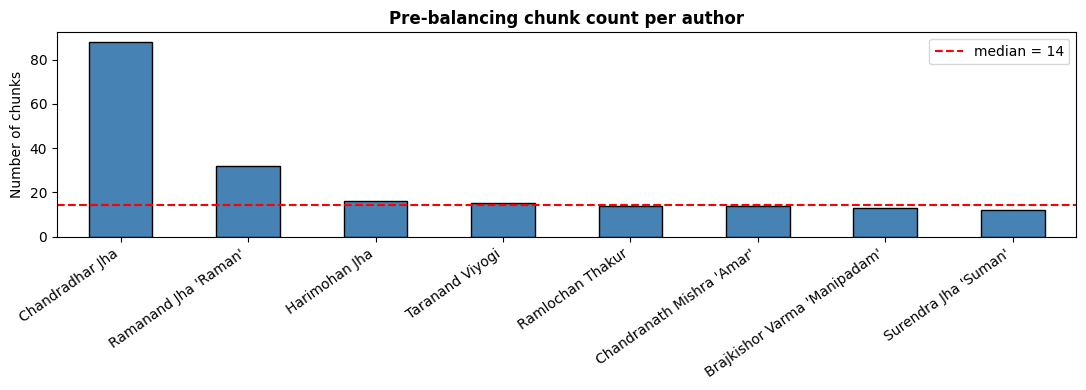


Coefficient of variation across authors: 1.02
(>0.5 indicates substantial imbalance worth correcting before classification)


In [ ]:
# A quick visual of imbalance to motivate the median-cap balancing in §7.
chunk_counts = {a: len(c) for a, c in authors_raw.items()}
counts_series = pd.Series(chunk_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
counts_series.plot.bar(ax=ax, color="steelblue", edgecolor="black")

median_val = np.median(list(chunk_counts.values()))
ax.axhline(median_val, color="red", linestyle="--", label=f"median = {int(median_val)}")

ax.set_title("Pre-balancing chunk count per author", fontweight="bold")
ax.set_ylabel("Number of chunks")
ax.legend()

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Print a CV figure to quantify imbalance numerically.
cv_imbalance = counts_series.std() / counts_series.mean()
print(f"\nCoefficient of variation across authors: {cv_imbalance:.2f}")
print("(>0.5 indicates substantial imbalance worth correcting before classification)")

---
## §4 Text Preprocessing

Maithili is written in Devanagari with a number of script-level nuances that
naive whitespace tokenisers get wrong. The functions below handle:

- Unicode NFC normalisation so visually identical strings are byte-identical
- Removal of zero-width joiners that creep in from PDF extraction
- Devanagari-only word matching that rejects Roman numerals and stray Latin
- Sentence splitting on the danda (`।`) plus Western punctuation


### §4.1 Normalisation, tokenisation, sentence splitting

Normalisation decisions are separated because Devanagari processing choices affect every feature. This makes text-cleaning assumptions inspectable.


In [ ]:
# Devanagari Unicode block: U+0900-U+097F
# Defining the regex once at module scope avoids re-compilation per-call.
DEV = r"[\u0900-\u097F]"
WORD_DEV = rf"(?:{DEV})+"


def normalize_text(text):
    """Canonicalise a Maithili text string before any analysis.

    Normalisation pipeline:
    1. NFC composition — combines base characters with their nukta/diacritic
       form so that visually identical glyphs hash to the same string.
    2. Dash unification — five visually similar dashes (em, en, minus, etc.)
       are collapsed to ASCII hyphen, which prevents phantom hapax tokens.
    3. ZWJ/ZWNJ removal — these zero-width controls are inconsistent in
       PDF-extracted Maithili text and would otherwise break tokenisation.
    """
    text = unicodedata.normalize("NFC", text)
    for dash in ["\u2014", "\u2013", "\u2212", "\u02d7"]:
        text = text.replace(dash, "-")
    return text.replace("\u200c", "").replace("\u200d", "")


def tokenize_words(text):
    """Extract Devanagari-only word tokens.

    The leading `normalize_text` ensures we never re-normalise inside callers.
    Restricting the character class to U+0900–U+097F intentionally drops
    Roman digits, English filler words, and footnote markers.
    """
    return re.findall(WORD_DEV, normalize_text(text))


def tokenize_sentences(text):
    """Split on Maithili sentence terminators and Latin punctuation.

    The danda (।) is the canonical Maithili sentence end. Period/exclamation/
    question are kept as fallbacks for code-mixed material. Two-character
    minimum filter drops empty fragments produced by repeated punctuation.
    """
    return [s.strip() for s in re.split(r"[।.!?]+", text) if len(s.strip()) > 2]


print("Preprocessing utilities ready.")

Preprocessing utilities ready.


---
## §5 Linguistic Resources

The following dictionaries encode hand-curated Maithili linguistic knowledge.
They drive the feature extractors in §6.0. Each lexicon block lives in its
own cell so it can be inspected, expanded, or A/B-tested independently.

> **Methodological caveat.** These lexicons are hand-crafted and therefore
> carry researcher-bias risk. The evaluator report flagged this as the main
> vulnerability of the project. A rigorous extension would validate the
> ideological lexicons against external annotated reform-era texts; that
> validation is left as future work.


### §5.1 Maithili case suffixes

These linguistic inventories define the project-specific Maithili signals. Keeping them modular makes later feature interpretation and revision easier.


In [ ]:
# Four core grammatical cases. Each suffix is a regex with a word-boundary
# anchor so we count standalone case markers rather than substrings inside
# unrelated words.
CASE_SUFFIXES = {
    "dative": [r"लेल\b", r"ले\b"],
    "genitive": [r"क\b", r"के\b", r"केर\b"],
    "locative": [r"मे\b", r"में\b", r"पर\b"],
    "instrumental_ablative": [r"सँ\b", r"सं\b", r"द्वारा\b"],
}

print(f"Case suffix categories: {len(CASE_SUFFIXES)}")

Case suffix categories: 4


### §5.2 Honorific tier markers

Maithili distinguishes three socio-pragmatic registers in verb agreement.
The choice between high/mid/low honorifics encodes deference, intimacy,
and social hierarchy — features that vary systematically by author.

In [ ]:
HONORIFIC = {
    # High register: deferential, used for elders and respected addressees
    "high": [
        r"थिन\b",
        r"थिन्ह\b",
        r"छथिन\b",
        r"छथिन्ह\b",
        r"छलाह\b",
        r"लाह\b",
        r"लैन्ह\b",
        r"लैँह\b",
        r"अप्ने\b",
        r"गेलाह\b",
        r"कैलन्हि\b",
        r"करताह\b",
        r"खिन्ह\b",
    ],
    # Mid register: neutral / equal social distance
    "mid": [
        r"छै\b",
        r"छि\b",
        r"छी\b",
        r"छियै\b",
        r"छिऐ\b",
        r"अहाँ\b",
        r"करब\b",
        r"जाइब\b",
        r"िअह\b",
    ],
    # Low register: intimate / familiar / sometimes derogatory
    "low": [
        r"कैक\b",
        r"ऐक\b",
        r"छइ\b",
        r"तोँ\b",
        r"तूँ\b",
        r"करबे\b",
        r"जैबे\b",
        r"ऐ\b",
        r"अक\b",
    ],
}

print(f'Honorific tiers: {len(HONORIFIC)} ({", ".join(HONORIFIC.keys())})')

Honorific tiers: 3 (high, mid, low)


### §5.3 Allocutive markers (addressee-encoding morphology)

These linguistic inventories define the project-specific Maithili signals. Keeping them modular makes later feature interpretation and revision easier.


In [ ]:
# Allocutive forms encode the addressee's status separately from the subject's.
# This is a near-unique feature of Maithili in the Indo-Aryan family and a
# strong stylistic fingerprint.
ALLOCUTIVE = {
    "alloc_high": [r"ऐन्ह\b", r"ऐथिन\b", r"ऐलन्हि\b"],
    "alloc_mid": [r"ऐह\b", r"ऐहुँ\b", r"हुँ\b"],
    "alloc_low": [r"ऐँ\b", r"अइ\b", r"कऽ\b"],
}
print(f"Allocutive tiers: {len(ALLOCUTIVE)}")

Allocutive tiers: 3


### §5.4 Pronoun categories

These linguistic inventories define the project-specific Maithili signals. Keeping them modular makes later feature interpretation and revision easier.


In [ ]:
# Person/number pronouns. We separate proximal vs. distal third-person
# because their relative density correlates with narrative perspective.
PRONOUNS = {
    "first": [r"\bहम\b", r"\bहमरा\b", r"\bहमर\b"],
    "second_formal": [r"\bअहाँ\b", r"\bअहाँक\b"],
    "third_proximal": [r"\bई\b", r"\bएकर\b", r"\bएतए\b"],
    "third_distal": [r"\bओ\b", r"\bओकर\b", r"\bओतए\b", r"\bओहि\b"],
}
print(f"Pronoun groups: {len(PRONOUNS)}")

Pronoun groups: 4


### §5.5 Function word groups

These linguistic inventories define the project-specific Maithili signals. Keeping them modular makes later feature interpretation and revision easier.


In [ ]:
# Function words are the workhorse of stylometry: their use is largely
# automatic, hard for an author to vary deliberately, and therefore acts as
# a personal fingerprint.
FW_GROUPS = {
    "fw_pronouns": ["हम", "अहाँ", "तोरा", "ओकर", "ओहि", "एकर"],
    "fw_conjunctions": ["आ", "मुदा", "अथवा", "परन्तु", "एवं"],
    "fw_particles": ["हि", "तऽ", "तँ", "ने", "तेँ", "त", "खाली", "बस"],
    "fw_deictics": ["एतए", "ओतए", "एहि", "ताहि", "जतएँ"],
    "fw_negation": ["नै", "नहि", "नञि"],
    "fw_interrogative": ["कि", "कतेक", "किएक", "कते", "कहिया"],
    "fw_temporal": ["जखन", "जहिया", "आब", "तखन", "एखन", "ओखन"],
    "fw_conditional": ["जँ", "जे"],
    "fw_quantifier": ["कनि"],
}
print(f"Function-word groups: {len(FW_GROUPS)}")

Function-word groups: 9


### §5.6 Semantic-ideological lexicons

Four ideological axes, each operationalised as a set of left-conservative
seed terms, right-progressive seed terms, and target nouns to anchor the
collocation window. These lexicons are the project's most distinctive
contribution — they let us measure *worldview*, not just *style*.

Axes:
1. **Gender ideology** — patriarchal/traditional ↔ reformist/egalitarian
2. **Caste hierarchy** — orthodox/hierarchical ↔ anti-caste/egalitarian
3. **Tradition vs. modernity** — custom-bound ↔ modern/reformist
4. **Religious vs. secular** — devotional/ritual-centred ↔ secular-rational

In [ ]:
SEMANTIC_DIMENSIONS = {
    "gender_ideology": {
        "axis": "patriarchal/traditional (-1) <-> reformist/egalitarian (+1)",
        "left_conservative": [
            "पतिक",
            "पति-परमेश्वर",
            "घूँघट",
            "पर्दा",
            "लाज",
            "मर्यादा",
            "कुलवधू",
            "सतीत्व",
            "पतिव्रता",
            "कन्यादान",
            "दहेज",
            "आज्ञापालन",
            "घरकाज",
            "चूल्हा",
            "परदा-प्रथा",
        ],
        "right_progressive": [
            "शिक्षा",
            "पढ़ाइ",
            "अधिकार",
            "स्वतंत्रता",
            "समानता",
            "रोजगार",
            "आत्मनिर्भर",
            "प्रतिरोध",
            "न्याय",
            "स्वाभिमान",
            "सशक्तिकरण",
            "विधवा-विवाह",
            "बाल-विवाह-विरोध",
            "दहेज-विरोध",
            "स्त्री-स्वर",
            "स्त्री-शिक्षा",
            "नारी-जागरण",
        ],
        "targets": [
            "नारी",
            "स्त्री",
            "महिला",
            "जनी",
            "कन्या",
            "बेटी",
            "बहिन",
            "पत्नी",
            "विधवा",
            "माय",
            "माता",
            "बहू",
            "जाय",
        ],
    },
    "caste_hierarchy": {
        "axis": "hierarchical/orthodox (-1) <-> anti-caste/egalitarian (+1)",
        "left_conservative": [
            "जाति",
            "ऊँच-नीच",
            "शुद्ध",
            "अशुद्ध",
            "छूआछूत",
            "पांत",
            "पंगत",
            "कुलीन",
            "ब्राह्मण",
            "कायस्थ",
            "शूद्र",
            "अछूत",
            "जनेऊ",
            "गोत्र",
            "वर्ण-व्यवस्था",
        ],
        "right_progressive": [
            "समता",
            "समान-अधिकार",
            "मानवता",
            "गरिमा",
            "सम्मान",
            "न्याय",
            "भेदभाव-विरोध",
            "छूआछूत-विरोध",
            "सामाजिक-न्याय",
            "बहुजन",
            "दलित-अधिकार",
            "बंधुत्व",
            "समावेश",
            "जात-उन्मूलन",
            "लोकतंत्र",
            "अंत्यज",
            "दलित-उद्घार",
        ],
        "targets": [
            "जाति",
            "समाज",
            "लोग",
            "मानुष",
            "गरीब",
            "दलित",
            "पिछड़ा",
            "ब्राह्मण",
            "कायस्थ",
            "चमार",
            "दुसाध",
            "मुसहर",
        ],
    },
    "tradition_modernity": {
        "axis": "custom-bound/traditional (-1) <-> modern/reformist (+1)",
        "left_conservative": [
            "परंपरा",
            "रीति",
            "रिवाज",
            "संस्कार",
            "कुल-मान",
            "लोकलाज",
            "बुजुर्ग-आज्ञा",
            "रूढ़ि",
            "पाखंड",
            "पुरान-चलन",
            "गामक-बात",
            "लाज-शर्म",
            "घरानाक-मान",
            "बाबा-दादाक-नीति",
            "पुरानपंथ",
        ],
        "right_progressive": [
            "आधुनिक",
            "नवचेतना",
            "परिवर्तन",
            "सुधार",
            "तर्क",
            "विज्ञान",
            "शहरीकरण",
            "विद्यालय",
            "कॉलेज",
            "मुद्रण",
            "राजनीतिक-जागरण",
            "नवयुवक",
            "नवसमाज",
            "प्रगतिशील",
            "नव-विचार",
        ],
        "targets": [
            "समय",
            "समाज",
            "परिवार",
            "गाम",
            "नगर",
            "पीढ़ी",
            "नवयुवक",
            "पुरान",
            "नव",
            "रीति",
            "चलन",
        ],
    },
    "religious_secular": {
        "axis": "devotional/ritual-central (-1) <-> secular-rational/public (+1)",
        "left_conservative": [
            "धर्म",
            "धार्मिक",
            "पूजा",
            "पाठ",
            "जप",
            "तप",
            "व्रत",
            "उपवास",
            "तीर्थ",
            "मंदिर",
            "भगवान",
            "ईश्वर",
            "भक्ति",
            "प्रसाद",
            "कर्मकांड",
        ],
        "right_progressive": [
            "धर्मनिरपेक्ष",
            "तर्क",
            "वैज्ञानिक-दृष्टि",
            "मानवतावाद",
            "नागरिकता",
            "संविधान",
            "अधिकार",
            "लोकतंत्र",
            "शिक्षा",
            "सार्वजनिक-हित",
            "समाज-सुधार",
            "विवेक",
            "समान-नागरिक",
            "राजनीतिक-चेतना",
            "बहुलता",
            "मानव-धर्म",
            "लोक-धर्म",
        ],
        "targets": [
            "धर्म",
            "समाज",
            "राज्य",
            "विद्यालय",
            "न्याय",
            "मानुष",
            "जनता",
            "गाम",
            "नगर",
            "संस्था",
        ],
    },
}

# Topic-bag groups — used as low-resolution indicators of subject matter.
TOPIC_GROUPS = {
    "topic_family_domestic": [
        "परिवार",
        "घर",
        "विवाह",
        "कन्या",
        "बहू",
        "पति",
        "पत्नी",
        "दहेज",
    ],
    "topic_education_modern": [
        "शिक्षा",
        "विद्यालय",
        "कॉलेज",
        "पढ़ाइ",
        "नवयुवक",
        "आधुनिक",
    ],
    "topic_religion_ritual": ["पूजा", "व्रत", "मंदिर", "धर्म", "भक्ति", "कर्मकांड"],
    "topic_social_justice": ["न्याय", "समता", "दलित", "अधिकार", "समानता", "भेदभाव"],
    "topic_politics_public": [
        "लोकतंत्र",
        "संविधान",
        "राज्य",
        "जनता",
        "राजनीतिक",
        "नागरिकता",
    ],
}

# Lexicon expansions (kept separate so the diff against the original lexicon
# is visible; merging happens in a single explicit loop below).
LEXICON_APPEND = {
    "gender_ideology": {
        "left_conservative": ["घरक-लाज", "कुलक-मान", "जनी-धरम"],
        "right_progressive": ["नारी-अधिकार", "जनी-शिक्षा", "बेटी-पढ़ाउ"],
    },
    "caste_hierarchy": {
        "left_conservative": ["जात-पांत", "छूत-अछूत", "कुल-गोत्र"],
        "right_progressive": ["सभ-मानुष-बराबर", "जाति-भेद-विरोध", "मानुषता"],
    },
    "tradition_modernity": {
        "left_conservative": ["पुरनका-रीति", "गामक-रिवाज"],
        "right_progressive": ["नव-समाज", "नव-विचारधारा", "सुधार-बात"],
    },
    "religious_secular": {
        "left_conservative": ["पूजापाठ", "नेम-धरम", "करमकांड"],
        "right_progressive": ["लोकहित", "जन-हित", "बुद्धि-विवेक"],
    },
}

# Merge the appended seed terms back into the main lexicon, dedup-aware.
for dim, sides in LEXICON_APPEND.items():
    for side, terms in sides.items():
        SEMANTIC_DIMENSIONS[dim][side].extend(
            [t for t in terms if t not in SEMANTIC_DIMENSIONS[dim][side]]
        )

print(f"Semantic axes  : {len(SEMANTIC_DIMENSIONS)}")
print(f"Topic groups   : {len(TOPIC_GROUPS)}")
for dim in SEMANTIC_DIMENSIONS:
    n_left = len(SEMANTIC_DIMENSIONS[dim]["left_conservative"])
    n_right = len(SEMANTIC_DIMENSIONS[dim]["right_progressive"])
    n_target = len(SEMANTIC_DIMENSIONS[dim]["targets"])
    print(f"  {dim:<22} | L={n_left:>2}  R={n_right:>2}  T={n_target:>2}")

Semantic axes  : 4
Topic groups   : 5
  gender_ideology        | L=18  R=20  T=13
  caste_hierarchy        | L=18  R=20  T=12
  tradition_modernity    | L=17  R=18  T=11
  religious_secular      | L=18  R=20  T=10


### §5.7 Pattern compilation

These linguistic inventories define the project-specific Maithili signals. Keeping them modular makes later feature interpretation and revision easier.


In [ ]:
def _compile_dict(d):
    """Compile every regex pattern in a label-to-patterns dictionary.

    Pre-compiling once at module load saves ~30% wall time on the full
    feature-extraction pass, since each chunk would otherwise re-compile
    the same patterns dozens of times.
    """
    return {k: [re.compile(p) for p in v] for k, v in d.items()}


def _token_pat(term):
    """Compile a Devanagari-aware exact-token regex.

    Why we cannot use \b: the \b boundary is undefined for non-ASCII text in
    Python's `re` module. Negative look-around for Devanagari characters on
    both sides reproduces the intended boundary behaviour.
    """
    return re.compile(rf"(?<![\u0900-\u097F]){re.escape(term)}(?![\u0900-\u097F])")


def compile_semantic_lexicons(semantic_dict, topic_dict=None):
    """Return two compiled lookup dictionaries: semantic axes and topic groups."""
    comp = {}
    for dim, d in semantic_dict.items():
        comp[dim] = {
            "left": [_token_pat(x) for x in d["left_conservative"]],
            "right": [_token_pat(x) for x in d["right_progressive"]],
            "targets": [_token_pat(x) for x in d["targets"]],
        }
    comp_topics = {
        topic: [_token_pat(x) for x in words]
        for topic, words in (topic_dict or {}).items()
    }
    return comp, comp_topics


# Compile every lexicon family once and store globally.
C = {
    "case": _compile_dict(CASE_SUFFIXES),
    "hon": _compile_dict(HONORIFIC),
    "alloc": _compile_dict(ALLOCUTIVE),
    "pronoun": _compile_dict(PRONOUNS),
    "fw_groups": {
        grp: [re.compile(rf"\b{re.escape(w)}\b") for w in words]
        for grp, words in FW_GROUPS.items()
    },
}
SEM_COMP, TOPIC_COMP = compile_semantic_lexicons(SEMANTIC_DIMENSIONS, TOPIC_GROUPS)

print("All regex patterns compiled.")
print(f"  Semantic axes : {len(SEM_COMP)}")
print(f"  Topic groups  : {len(TOPIC_COMP)}")

All regex patterns compiled.
  Semantic axes : 4
  Topic groups  : 5


### §5.8 Lexicon internal-consistency diagnostic *(optional)*

The hand-curated ideological lexicons are the project's most innovative
contribution and its most epistemologically vulnerable choice — researcher
priors about what counts as "orthodox" vs. "anti-caste" are baked into the
seed lists.

A strong validation would use external resources (fastText embeddings on a
larger Devanagari corpus, or expert annotation with Cohen's κ). Both require
materials outside this notebook's scope, so we provide a weaker but free
**within-corpus consistency check**:

> *For each axis: do the left-conservative seed terms co-occur with each
> other (within the same chunk) more often than they co-occur with
> right-progressive seed terms?*

If the answer is "yes" by a comfortable margin, the lexicon at least
captures coherent semantic clusters in the actual text. If "no", the
lexicon is internally noisy and the polarity scores should be treated
with extra caution.

This is a *necessary but not sufficient* test: passing it does not prove
the lexicon measures the intended ideological dimension; failing it
strongly suggests it does not.

In [ ]:
def lexicon_cooccurrence_diagnostic(authors, sem_dimensions):
    """Per-axis side-coherence score using chunk-level co-occurrence.

    Method
    ------
    For each ideological axis, build the binary chunk-by-term presence
    matrix (was term X seen in chunk i?). Then compute three numbers:
        within_left  : mean co-occurrence rate among left-conservative seeds
        within_right : mean co-occurrence rate among right-progressive seeds
        cross        : mean co-occurrence rate between a left and a right seed
    A coherent lexicon should yield within_* > cross by a comfortable margin.

    Returns
    -------
    DataFrame with one row per axis and the three diagnostic numbers.
    """
    # Flatten corpus -> one big list of tokenised chunks (without normalising
    # again, since we want to detect terms exactly as they appear after
    # normalisation in §4.1).
    all_chunks = [tokenize_words(c) for chunks in authors.values() for c in chunks]

    rows = []
    for dim, d in sem_dimensions.items():
        left_terms = d["left_conservative"]
        right_terms = d["right_progressive"]

        # Build presence matrices: chunks x terms (boolean).
        def presence(terms):
            """Return chunk-x-term boolean array."""
            mat = np.zeros((len(all_chunks), len(terms)), dtype=bool)
            for i, toks in enumerate(all_chunks):
                tok_set = set(toks)
                for j, term in enumerate(terms):
                    # Exact-token match. Multi-token compounds (containing '-')
                    # don't appear as single tokens, so we fall back to substring
                    # within the joined chunk text for those edge cases.
                    if "-" in term:
                        joined = " ".join(toks)
                        mat[i, j] = term in joined
                    else:
                        mat[i, j] = term in tok_set
            return mat

        L = presence(left_terms)
        R = presence(right_terms)

        # Co-occurrence rate = fraction of chunks where both terms appear.
        # We average over all term pairs (i, j) with i != j on the same side,
        # and over all (left, right) pairs for the cross score.
        def avg_pairwise_cooc(mat_a, mat_b, exclude_diag=False):
            """Mean fraction of chunks where both columns are present."""
            # mat_a: chunks x na, mat_b: chunks x nb.
            # Pair-presence matrix: na x nb where entry (i,j) = #chunks both occur.
            cooc = (mat_a.T.astype(np.int32) @ mat_b.astype(np.int32)) / max(
                1, mat_a.shape[0]
            )
            if exclude_diag and mat_a is mat_b:
                np.fill_diagonal(cooc, np.nan)
            valid = cooc[~np.isnan(cooc)]
            return float(valid.mean()) if valid.size else 0.0

        within_left = avg_pairwise_cooc(L, L, exclude_diag=True)
        within_right = avg_pairwise_cooc(R, R, exclude_diag=True)
        cross = avg_pairwise_cooc(L, R, exclude_diag=False)

        # Coherence ratio: how much stronger same-side co-occurrence is
        # than cross-side. Values > 1 indicate the seed lists form
        # internally coherent clusters; values <= 1 are a warning sign.
        coherence = (within_left + within_right) / (2 * cross + 1e-9)

        rows.append(
            {
                "axis": dim,
                "within_left_cooc": within_left,
                "within_right_cooc": within_right,
                "cross_cooc": cross,
                "coherence_ratio": coherence,
            }
        )

    return pd.DataFrame(rows)


# Run the diagnostic and report.
lex_diag = lexicon_cooccurrence_diagnostic(authors_raw, SEMANTIC_DIMENSIONS)

print("=" * 80)
print("LEXICON INTERNAL-CONSISTENCY DIAGNOSTIC")
print("=" * 80)
print("Coherence ratio = mean(within-side co-occurrence) / cross-side co-occurrence")
print("  > 1.5  : reasonably coherent — seeds cluster by side")
print("  ~ 1.0  : neutral — seeds do not separate cleanly")
print("  < 1.0  : warning — cross-side co-occurrence dominates")
print()
print(lex_diag.round(4).to_string(index=False))
print()

mean_coh = lex_diag["coherence_ratio"].mean()

if mean_coh > 1.5:
    print(f"-> Mean coherence {mean_coh:.2f} suggests reasonable internal consistency.")
elif mean_coh > 1.0:
    print(
        f"-> Mean coherence {mean_coh:.2f} is borderline — interpret polarities cautiously."
    )
else:
    print(
        f"-> Mean coherence {mean_coh:.2f} is concerning — lexicon may need revision."
    )

print()
print("CAVEAT: This is internal consistency only. It does NOT confirm the")
print("lexicons measure the *intended* ideological dimension. External")
print("validation (fastText nearest neighbours / expert annotation) remains")
print("the standard for that claim.")

LEXICON INTERNAL-CONSISTENCY DIAGNOSTIC
Coherence ratio = mean(within-side co-occurrence) / cross-side co-occurrence
  > 1.5  : reasonably coherent — seeds cluster by side
  ~ 1.0  : neutral — seeds do not separate cleanly
  < 1.0  : warning — cross-side co-occurrence dominates

               axis  within_left_cooc  within_right_cooc  cross_cooc  coherence_ratio
    gender_ideology            0.0004             0.0012      0.0007           1.2708
    caste_hierarchy            0.0008             0.0004      0.0006           1.0927
tradition_modernity            0.0003             0.0017      0.0007           1.4062
  religious_secular            0.0048             0.0006      0.0016           1.6740

-> Mean coherence 1.36 is borderline — interpret polarities cautiously.

CAVEAT: This is internal consistency only. It does NOT confirm the
lexicons measure the *intended* ideological dimension. External
validation (fastText nearest neighbours / expert annotation) remains
the standard for

---
## §6 Feature Engineering — 10 Feature Families

The full 77-dimensional author vector is built from ten linguistically
motivated families. Each family is implemented as a self-contained extractor
returning a `dict` of `feature_name -> value`, and §6.11 fuses them all.

| # | Family | Count | Domain |
|---|---|---|---|
| 1 | Lexical richness | 4 | General |
| 2 | POS distribution + derived ratios | 23 | General |
| 3 | Orthographic variation | 2 | Devanagari-specific |
| 4 | Case suffix ratios | 4 | Maithili |
| 5 | Function-word groups | 9 | Maithili |
| 6 | Pronoun ratios | 4 | Maithili |
| 7 | Honorific tier ratios | 3 | Maithili |
| 8 | Allocutive tier ratios | 3 | Maithili |
| 9 | Semantic-ideological polarity + topics | 22 | Novel (Maithili) |
| 10 | Hybrid cross-feature bindings | 3 | Novel |
| | **Total** | **~77** | |


### §6.1 Family 1 — Lexical Richness (4 features)

These four classics measure vocabulary diversity and concentration. We chose
this subset because they are largely uncorrelated and stable on chunks ≥ 800
words:

- **MSTTR-100** — moving-average type-token ratio over 100-word windows,
  immune to the well-known TTR length bias.
- **Hapax ratio** — proportion of words occurring exactly once; a strong
  proxy for lexical creativity.
- **Yule's K** — vocabulary concentration, rewards repetition.
- **Bigram diversity** — ratio of unique word bigrams to total bigrams.

In [ ]:
def lexical_richness_selected(words):
    """Compute four length-stable lexical-richness measures.

    Why these four
    --------------
    Standard TTR (type-token ratio) is biased by sample length, which makes
    it unusable when chunk lengths differ even slightly. MSTTR fixes that by
    averaging TTR over fixed-size windows. Hapax ratio and Yule's K together
    triangulate concentration vs. dispersion. Bigram diversity captures
    short-range collocation variety that single-word metrics miss.
    """
    N = len(words) + 1e-9  # +1e-9 guards division by zero
    freq = Counter(words)  # word frequency table
    V = len(freq)  # vocabulary size

    # MSTTR-100: average TTR over disjoint 100-word windows.
    seg = 100
    if len(words) < seg:
        msttr = V / N
    else:
        # Build all complete (length==seg) windows. We exclude the final
        # partial window because its TTR is artificially inflated.
        segments = [words[i : i + seg] for i in range(0, len(words) - seg + 1, seg)]
        segments = [s for s in segments if len(s) == seg]
        msttr = float(np.mean([len(set(s)) / len(s) for s in segments if s]))

    # Hapax ratio: words seen exactly once / total words.
    hapax = sum(1 for v in freq.values() if v == 1)

    # Yule's K characteristic constant (Yule 1944). Lower K => richer vocabulary.
    spectrum = Counter(freq.values())
    M2 = sum(i * i * spectrum[i] for i in spectrum)
    yules_k = 10000 * (M2 - N) / (N * N + 1e-9)

    # Bigram diversity: distinct adjacent-pair count / total bigrams.
    if len(words) > 1:
        bigrams = [(words[i], words[i + 1]) for i in range(len(words) - 1)]
        bigram_div = len(set(bigrams)) / (len(bigrams) + 1e-9)
    else:
        bigram_div = 0

    return {
        "msttr_100": msttr,
        "hapax_ratio": hapax / N,
        "yules_k": yules_k / 1000,  # rescaled for numerical comfort
        "bigram_diversity": bigram_div,
    }


print("Family 1 (lexical richness) defined — 4 features.")

Family 1 (lexical richness) defined — 4 features.


### §6.2 Family 2 — POS Distribution & Derived Ratios (23 features)

Stanza's Hindi pipeline is used since no native UD model exists for Maithili.
The two languages share core POS inventory and morphology, so cross-language
tagging is tolerable for coarse part-of-speech statistics.

We additionally derive nine ratios (e.g. `noun_verb_ratio`, `aux_density`)
that capture syntactic style irrespective of vocabulary. POS bigram entropy
serves as a coarse measure of syntactic predictability.

In [ ]:
# Module-level cache so repeated calls on the same chunk skip Stanza
# entirely. Keys are MD5 hashes of the input text.
_pos_cache = {}


def _cache_key(text):
    """Return a content-addressable key for the POS cache."""
    return hashlib.md5(text.encode("utf-8")).hexdigest()


def get_pos_tags(text):
    """Return list of (word, upos) pairs, with persistent caching.

    Long chunks are split into <50k-character segments because Stanza throws
    when fed an entire book in one shot. We segment on word boundaries to
    avoid corrupting tokenisation around the cut.
    """
    global _pos_cache
    key = _cache_key(text)
    if key in _pos_cache:
        return _pos_cache[key]

    if not (USE_STANZA and nlp_hi is not None):
        _pos_cache[key] = []
        return []

    try:
        MAX_CHARS = 50000
        if len(text) > MAX_CHARS:
            words = text.split()
            seg_size = max(1, len(words) // (len(text) // MAX_CHARS + 1))
            segments = [
                " ".join(words[i : i + seg_size])
                for i in range(0, len(words), seg_size)
            ]
        else:
            segments = [text]

        all_pairs = []
        for seg in segments:
            doc = nlp_hi(seg)
            for sent in doc.sentences:
                for word in sent.words:
                    all_pairs.append((word.text, word.upos))
        _pos_cache[key] = all_pairs
        return all_pairs
    except Exception as e:
        print(f"  Stanza failed on chunk: {e}")
        _pos_cache[key] = []
        return []


def pos_distribution(text, words):
    """Compute 14 raw POS proportions plus 9 derived ratios = 23 features."""
    # Universal POS tags we actually report (ignoring SYM, X, PUNCT etc.
    # because they are noisy and uninformative for stylometry).
    tags_to_report = [
        "NOUN",
        "VERB",
        "ADJ",
        "ADV",
        "PRON",
        "AUX",
        "ADP",
        "DET",
        "CCONJ",
        "SCONJ",
        "PART",
        "NUM",
        "PROPN",
        "INTJ",
    ]

    derived_keys = [
        "noun_verb_ratio",
        "content_func_ratio",
        "aux_density",
        "adv_density",
        "det_density",
        "propn_ratio",
        "sconj_density",
        "verb_periphrastic",
        "pos_bigram_entropy",
    ]

    # Initialise an all-zero feature dict so a Stanza failure produces the
    # right schema rather than a missing column downstream.
    empty = {f"pos_{t}": 0.0 for t in tags_to_report}
    empty.update({k: 0.0 for k in derived_keys})

    pos_pairs = get_pos_tags(text)
    if not pos_pairs:
        return empty

    pos_list = [tag for _, tag in pos_pairs]
    if not pos_list:
        return empty

    n = len(pos_list) + 1e-9
    counts = Counter(pos_list)
    feats = {f"pos_{t}": counts.get(t, 0) / n for t in tags_to_report}

    # Derived ratio 1: nouns vs all verbal forms (VERB+AUX).
    total_verbs = counts.get("VERB", 0) + counts.get("AUX", 0)
    feats["noun_verb_ratio"] = counts.get("NOUN", 0) / (total_verbs + 1e-9)

    # Derived ratio 2: content-word vs function-word density. Captures the
    # general "informativeness" of the text.
    content = sum(counts.get(t, 0) for t in ("NOUN", "VERB", "ADJ", "ADV", "PROPN"))
    function = sum(
        counts.get(t, 0) for t in ("ADP", "CCONJ", "SCONJ", "PART", "DET", "AUX")
    )
    feats["content_func_ratio"] = content / (function + 1e-9)

    # Single-tag densities expressed standalone for downstream interpretability.
    feats["aux_density"] = counts.get("AUX", 0) / n
    feats["adv_density"] = counts.get("ADV", 0) / n
    feats["det_density"] = counts.get("DET", 0) / n
    feats["propn_ratio"] = counts.get("PROPN", 0) / n
    feats["sconj_density"] = counts.get("SCONJ", 0) / n

    # Periphrastic verb construction rate — proxy for tense/aspect complexity.
    feats["verb_periphrastic"] = counts.get("AUX", 0) / (total_verbs + 1e-9)

    # POS bigram entropy: lower = more predictable syntax. Divided by log(5)
    # for normalised reporting in roughly the [0, 1] range.
    if len(pos_list) > 1:
        bigrams = [(pos_list[i], pos_list[i + 1]) for i in range(len(pos_list) - 1)]
        bg_freq = Counter(bigrams)
        bg_total = sum(bg_freq.values()) + 1e-9
        feats["pos_bigram_entropy"] = (
            -sum(
                (v / bg_total) * math.log(v / bg_total + 1e-9) for v in bg_freq.values()
            )
            / 5.0
        )
    else:
        feats["pos_bigram_entropy"] = 0.0

    return feats


print("Family 2 (POS) defined — 23 features.")

Family 2 (POS) defined — 23 features.


### §6.3 Family 3 — Orthographic Variation (2 features)

Maithili authors vary in how they encode nasalisation: chandrabindu (ँ, U+0901)
vs. anusvara (ं, U+0902). The choice is partly idiosyncratic, partly
period-dependent, and a discriminative author signal.

In [ ]:
def maithili_orthographic_variation(text):
    """Two ratios summarising chandrabindu/anusvara preference."""
    cb = len(re.findall("\u0901", text))  # chandrabindu count
    an = len(re.findall("\u0902", text))  # anusvara count
    return {
        # Proportion of all nasal marks that are chandrabindu.
        "orth_chandrabindu": cb / (cb + an + 1e-9),
        # Raw preference ratio — useful when one mark is near-absent.
        "orth_nasal_pref": cb / (an + 1e-9),
    }


print("Family 3 (orthography) defined — 2 features.")

Family 3 (orthography) defined — 2 features.


### §6.4 Family 4 — Case Suffix Ratios (4 features)

This feature family contributes one interpretable signal to the authorship vector. Separating families supports ablation and transparent literary interpretation.


In [ ]:
def maithili_case_suffix_ratio(text, total_w):
    """Per-1000-word density of each case suffix family.

    Reported as raw proportion (count / total_w) rather than per-1000 to
    keep the magnitude comparable to the other density features.
    """
    return {
        f"case_{k}": sum(len(p.findall(text)) for p in pats) / total_w
        for k, pats in C["case"].items()
    }


print("Family 4 (case suffixes) defined — 4 features.")

Family 4 (case suffixes) defined — 4 features.


### §6.5 Family 5 — Function Word Groups (9 features)

This feature family contributes one interpretable signal to the authorship vector. Separating families supports ablation and transparent literary interpretation.


In [ ]:
def maithili_function_word_groups(text, total_w):
    """Density per function-word group (pronouns, conjunctions, particles, ...)."""
    return {
        grp: sum(len(p.findall(text)) for p in pats) / total_w
        for grp, pats in C["fw_groups"].items()
    }


print("Family 5 (function words) defined — 9 features.")

Family 5 (function words) defined — 9 features.


### §6.6 Family 6 — Pronoun Distribution (4 features)

This feature family contributes one interpretable signal to the authorship vector. Separating families supports ablation and transparent literary interpretation.


In [ ]:
def maithili_pronoun_ratios(text, total_w):
    """Per-token density of first/second/third pronouns (proximal vs distal)."""
    return {
        f"pron_{k}": sum(len(p.findall(text)) for p in pats) / total_w
        for k, pats in C["pronoun"].items()
    }


print("Family 6 (pronouns) defined — 4 features.")

Family 6 (pronouns) defined — 4 features.


### §6.7 Family 7 — Honorific Tier Ratios (3 features)

This feature family contributes one interpretable signal to the authorship vector. Separating families supports ablation and transparent literary interpretation.


def maithili_honorific_ratio(text, total_w):
    """Density of high/mid/low honorific markers in verb agreement."""
    return {f'hon_{k}': sum(len(p.findall(text)) for p in pats) / total_w
            for k, pats in C['hon'].items()}

print('Family 7 (honorifics) defined — 3 features.')

### §6.8 Family 8 — Allocutive Tier Ratios (3 features)

This feature family contributes one interpretable signal to the authorship vector. Separating families supports ablation and transparent literary interpretation.


In [ ]:
def maithili_allocutive_ratio(text, total_w):
    """Density of allocutive (addressee-encoding) verb suffixes."""
    return {
        f"{k}": sum(len(p.findall(text)) for p in pats) / total_w
        for k, pats in C["alloc"].items()
    }


print("Family 8 (allocutives) defined — 3 features.")

Family 8 (allocutives) defined — 3 features.


### §6.9 Family 9 — Semantic-Ideological Polarity (22 features)

For each of four ideological axes we compute four numbers: polarity,
support, left density, right density. We additionally compute five topic
densities and one topic-distribution entropy. The polarity is computed via
*windowed proximity counting* — a left-conservative or right-progressive
seed term must occur within ±5 tokens of an ideological target noun to
count. This is the project's signature feature engineering choice.

In [ ]:
def _find_token_positions(tokens, patterns):
    """Return list of token indices where any of the given patterns matches."""
    idxs = []
    for i, w in enumerate(tokens):
        # We use fullmatch because each pattern was compiled to match whole
        # tokens via Devanagari look-arounds.
        for p in patterns:
            if p.fullmatch(w):
                idxs.append(i)
                break
    return idxs


def _window_hits(anchor_positions, probe_positions, w=5):
    """Count anchors that have at least one probe within ±w tokens."""
    if not anchor_positions or not probe_positions:
        return 0
    probe_arr = np.array(probe_positions)
    return sum(1 for a in anchor_positions if np.any(np.abs(probe_arr - a) <= w))


def _count_matches_in_text(text, patterns):
    """Sum of match counts across a list of compiled patterns."""
    return sum(len(p.findall(text)) for p in patterns)


def semantic_polarity_features(
    text, words, sem_comp, topic_comp=None, window=BEST_SEM_WINDOW
):
    """Produce 22 semantic features (4 axes × 4 metrics + 5 topics + 1 entropy).

    Methodological note
    -------------------
    When no ideological target nouns appear in the chunk, we fall back to a
    text-wide left-vs-right balance. This avoids zero-division and produces
    meaningful values even on neutral passages. The `support` value reflects
    how strong the ideological signal is in the chunk overall.
    """
    feats = {}
    tw = len(words) + 1e-9
    tokens = words

    for dim, pat in sem_comp.items():
        # Locate every target / left / right token in the chunk.
        tgt_idx = _find_token_positions(tokens, pat["targets"])
        left_idx = _find_token_positions(tokens, pat["left"])
        right_idx = _find_token_positions(tokens, pat["right"])

        # Within-window collocate counts give us anchored polarity.
        left_hits = _window_hits(tgt_idx, left_idx, w=window)
        right_hits = _window_hits(tgt_idx, right_idx, w=window)

        if len(tgt_idx) == 0:
            # No target nouns: fall back to text-wide balance.
            denom = len(left_idx) + len(right_idx) + 1e-9
            pol = (len(right_idx) - len(left_idx)) / denom
            support = denom / (len(tokens) + 1e-9)
        else:
            denom = left_hits + right_hits + 1e-9
            pol = (right_hits - left_hits) / denom
            support = denom / (len(tgt_idx) + 1e-9)

        feats[f"{dim}_polarity"] = pol
        feats[f"{dim}_support"] = support
        feats[f"{dim}_left_density"] = len(left_idx) / tw
        feats[f"{dim}_right_density"] = len(right_idx) / tw

    # Topic densities + Shannon entropy across topic groups.
    if topic_comp:
        topic_vals = {
            topic: _count_matches_in_text(text, pats) / tw
            for topic, pats in topic_comp.items()
        }
        for topic, v in topic_vals.items():
            feats[topic] = v

        tv = np.array(list(topic_vals.values()), dtype=float)
        if tv.sum() > 0:
            p = tv / (tv.sum() + 1e-9)
            # Normalised entropy in [0, 1]: 1 = uniform topic distribution,
            # 0 = single-topic concentration.
            feats["topic_entropy"] = float(
                -(p * np.log(p + 1e-9)).sum() / np.log(len(p) + 1e-9)
            )
        else:
            feats["topic_entropy"] = 0.0

    return feats


print("Family 9 (semantic + topic) defined — 22 features.")

Family 9 (semantic + topic) defined — 22 features.


### §6.10 Family 10 — Hybrid Cross-Feature Bindings (3 features)

These three sentence-level features capture *interaction* between style and
semantics rather than either in isolation. They exist because the report
flagged that style/semantic disagreement is itself an interesting signal —
explicitly modelling that interaction makes it learnable.

In [ ]:
def hybrid_binding_features(text, words, sem_comp):
    """Sentence-level co-occurrence features between style and semantics."""
    sents = tokenize_sentences(text)

    rel_left_pats = sem_comp["religious_secular"]["left"]
    caste_left_pats = sem_comp["caste_hierarchy"]["left"]
    hon_high_pats = C["hon"]["high"]

    # Binding 1: high-honorific tier co-occurring with religious vocabulary
    # in the same sentence. Captures devotional register.
    bind_rel = sum(
        1
        for s in sents
        if any(p.search(s) for p in rel_left_pats)
        and any(p.search(s) for p in hon_high_pats)
    )
    # Binding 2: high-honorific tier with caste vocabulary — captures
    # orthodox social register.
    bind_caste = sum(
        1
        for s in sents
        if any(p.search(s) for p in caste_left_pats)
        and any(p.search(s) for p in hon_high_pats)
    )

    # Binding 3: gender targets occurring near progressive seeds, normalised
    # by target count (analogous to the polarity computation, but isolated).
    g_t = _find_token_positions(words, sem_comp["gender_ideology"]["targets"])
    g_r = _find_token_positions(words, sem_comp["gender_ideology"]["right"])

    return {
        "honorific_religious_binding": bind_rel / (len(sents) + 1e-9),
        "honorific_caste_binding": bind_caste / (len(sents) + 1e-9),
        "gender_pronoun_progressive_binding": _window_hits(g_t, g_r, w=BEST_SEM_WINDOW)
        / (len(g_t) + 1e-9),
    }


print("Family 10 (hybrid bindings) defined — 3 features.")

Family 10 (hybrid bindings) defined — 3 features.


### §6.11 Unified extraction pipeline

This feature family contributes one interpretable signal to the authorship vector. Separating families supports ablation and transparent literary interpretation.


In [ ]:
def extract_authorship_vector(text):
    """Run all 10 feature families on a single chunk and return a flat dict.

    Order is deliberate: cheap operations (regex counts) before the
    expensive Stanza POS pass, so any early failure aborts before paying
    the POS cost.
    """
    t = normalize_text(text)
    words = tokenize_words(t)
    tw = len(words) + 1e-9

    feats = {}
    feats.update(lexical_richness_selected(words))  # Family 1
    feats.update(pos_distribution(t, words))  # Family 2
    feats.update(maithili_orthographic_variation(t))  # Family 3
    feats.update(maithili_case_suffix_ratio(t, tw))  # Family 4
    feats.update(maithili_function_word_groups(t, tw))  # Family 5
    feats.update(maithili_pronoun_ratios(t, tw))  # Family 6
    feats.update(maithili_honorific_ratio(t, tw))  # Family 7
    feats.update(maithili_allocutive_ratio(t, tw))  # Family 8
    sem_feats = semantic_polarity_features(
        t, words, SEM_COMP, TOPIC_COMP, window=BEST_SEM_WINDOW
    )  # Family 9
    feats.update(sem_feats)
    feats.update(hybrid_binding_features(t, words, SEM_COMP))  # Family 10
    return feats


# Define a registry mapping family names to their feature column patterns.
# This is the single source of truth for the ablation study in §10.5.
FEATURE_FAMILIES = {
    "F01_lexical_richness": ["msttr", "hapax", "yules", "bigram"],
    "F02_pos_distribution": [
        "pos_",
        "noun_verb",
        "content_func",
        "aux_",
        "adv_",
        "det_",
        "propn_",
        "sconj_",
        "verb_peri",
        "pos_bigram",
    ],
    "F03_orthography": ["orth_"],
    "F04_case_suffixes": ["case_"],
    "F05_function_words": ["fw_"],
    "F06_pronouns": ["pron_"],
    "F07_honorific": ["hon_"],
    "F08_allocutive": ["alloc_"],
    "F09_semantic_topic": [
        "_polarity",
        "_support",
        "_left_density",
        "_right_density",
        "topic_",
    ],
    "F10_hybrid_bindings": ["honorific_religious", "honorific_caste", "gender_pronoun"],
}

print("Unified extraction pipeline ready. Family registry:")
for k in FEATURE_FAMILIES:
    print(f"  {k}")

Unified extraction pipeline ready. Family registry:
  F01_lexical_richness
  F02_pos_distribution
  F03_orthography
  F04_case_suffixes
  F05_function_words
  F06_pronouns
  F07_honorific
  F08_allocutive
  F09_semantic_topic
  F10_hybrid_bindings


---
## §7 Corpus Balancing & Feature Matrix Construction

Two pre-modelling steps that are easy to get wrong: (1) capping author
chunks at the median to prevent the largest author from dominating
similarity averages, and (2) caching the expensive Stanza pass so
re-runs are fast.


### §7.1 Median-based corpus balancing

This step controls corpus balance and expensive extraction. It protects the modelling section from avoidable imbalance and repeated preprocessing cost.


In [ ]:
# We cap each author's chunk count at the median across authors.
# Rationale: dropping below the median would discard usable data; raising
# above it (e.g., over-sampling) would create dependent samples and inflate
# CV scores. Median is a defensible middle ground that keeps total data high
# while preventing one author from dominating.
chunk_counts = [len(ch) for ch in authors_raw.values()]
cap = int(np.median(chunk_counts))

authors = {}
for author, chunks in authors_raw.items():
    if len(chunks) > cap:
        # random.sample uses the seeded random state set in §1.3.
        authors[author] = random.sample(chunks, cap)
    else:
        # Authors below the cap keep all their chunks.
        authors[author] = chunks

print(f"Median cap: {cap} chunks/author\n")
print(f'{"Author":<45} {"Before":>7}  {"After":>7}')
print("-" * 65)
for a in authors_raw:
    print(f"{a:<45} {len(authors_raw[a]):>7}  {len(authors[a]):>7}")

Median cap: 14 chunks/author

Author                                         Before    After
-----------------------------------------------------------------
Brajkishor Varma 'Manipadam'                       13       13
Chandradhar Jha                                    88       14
Chandranath Mishra 'Amar'                          14       14
Harimohan Jha                                      16       14
Ramanand Jha 'Raman'                               32       14
Ramlochan Thakur                                   14       14
Surendra Jha 'Suman'                               12       12
Taranand Viyogi                                    15       14


### §7.2 Feature extraction with on-disk caching

This step controls corpus balance and expensive extraction. It protects the modelling section from avoidable imbalance and repeated preprocessing cost.


In [ ]:
# Flatten the balanced corpus and cache the expensive feature extraction.
# POS and feature caches now use the same cache_or_compute convention.
flat_chunks = []
chunk_authors = []
for author, chunks in authors.items():
    for chunk in chunks:
        flat_chunks.append(chunk)
        chunk_authors.append(author)
FEATURE_CACHE_FILE = os.path.join(CACHE_DIR, "authorship_feature_bundle_v_final.pkl")
POS_CACHE_FILE = os.path.join(CACHE_DIR, "pos_cache_v_final.pkl")
_pos_cache = cache_or_compute(POS_CACHE_FILE, lambda: {}, "POS cache")


def _extract_feature_bundle():
    rows = [extract_authorship_vector(c) for c in tqdm(flat_chunks, desc="Extract")]
    df = pd.DataFrame(rows).fillna(0)
    cache_or_compute(POS_CACHE_FILE, lambda: _pos_cache, "POS cache", force=True)
    return {
        "feature_df": df,
        "chunk_authors": chunk_authors,
        "flat_chunks": flat_chunks,
        "feature_version": "final_unified_classical_v1",
    }


feature_bundle = cache_or_compute(
    FEATURE_CACHE_FILE, _extract_feature_bundle, "stylometric feature matrix"
)
feature_df = feature_bundle["feature_df"]
chunk_authors = feature_bundle["chunk_authors"]
flat_chunks = feature_bundle["flat_chunks"]
print(
    f"Feature matrix loaded: {feature_df.shape[0]} chunks x {feature_df.shape[1]} features"
)
print("-" * 80)
total_classified = 0
for fam, prefixes in FEATURE_FAMILIES.items():
    cols = [
        c
        for c in feature_df.columns
        if any(c.startswith(p) or p in c for p in prefixes)
    ]
    total_classified += len(cols)
    print(f"  {fam:<25} {len(cols):>3} columns")
print(
    f'  {"sum":<25} {total_classified:>3} (columns can match multiple interpretive prefixes)'
)

Loading cached POS cache: pos_cache_v_final.pkl
Loading cached stylometric feature matrix: authorship_feature_bundle_v_final.pkl
Feature matrix loaded: 109 chunks x 77 features
--------------------------------------------------------------------------------
  F01_lexical_richness        5 columns
  F02_pos_distribution       23 columns
  F03_orthography             2 columns
  F04_case_suffixes           4 columns
  F05_function_words          9 columns
  F06_pronouns                4 columns
  F07_honorific               3 columns
  F08_allocutive              3 columns
  F09_semantic_topic         22 columns
  F10_hybrid_bindings         3 columns
  sum                        78 (columns can match multiple interpretive prefixes)


---
## §8 Similarity Analysis

Two parallel similarity matrices: one over the **full** feature space
(style + semantics together) and one over the **semantic-only** features.
Comparing them surfaces author pairs whose worldview aligns despite
different surface styles — and vice versa.


### §8.1 Standardisation, normalisation, chunk-level similarity

Similarity analysis gives an unsupervised view before supervised attribution. It helps separate stylistic proximity from classifier performance.


In [ ]:
# StandardScaler centers and scales each feature so that no single
# high-variance feature (e.g., raw bigram_diversity) dominates the cosine.
scaler = StandardScaler()
feature_norm = scaler.fit_transform(feature_df.values)

# L2 row normalisation makes cosine similarity invariant to chunk magnitude
# (basically a length normalisation step).
feature_l2 = l2_normalize(feature_norm, norm="l2")

# Pairwise cosine similarity between every chunk pair.
sim_matrix = cosine_similarity(feature_l2)
print(f"Chunk-level similarity matrix: {sim_matrix.shape}")

Chunk-level similarity matrix: (109, 109)


### §8.2 Author-level aggregation with bootstrap CIs

Similarity analysis gives an unsupervised view before supervised attribution. It helps separate stylistic proximity from classifier performance.


In [ ]:
# Build author -> list of chunk indices for fast pairwise aggregation.
authors_list = list(authors.keys())
idx_map = {a: [i for i, x in enumerate(chunk_authors) if x == a] for a in authors_list}

# Author-level raw similarity = mean over the rectangular block of chunk pairs.
author_sim_raw = pd.DataFrame(
    np.zeros((len(authors_list), len(authors_list))),
    index=authors_list,
    columns=authors_list,
)
for a in authors_list:
    for b in authors_list:
        author_sim_raw.loc[a, b] = sim_matrix[np.ix_(idx_map[a], idx_map[b])].mean()

# Percentile rescaling makes the heatmap legible — raw cosines are bunched
# in the [-0.2, 0.3] range and don't visualise well on a 0-1 colour scale.
mask = ~np.eye(len(authors_list), dtype=bool)
off_diag = author_sim_raw.values[mask]
ranks = rankdata(off_diag) / len(off_diag)
rescaled = np.zeros_like(author_sim_raw.values)
rescaled[mask] = ranks
np.fill_diagonal(rescaled, 1.0)
author_sim = pd.DataFrame(rescaled, index=authors_list, columns=authors_list)

# Bootstrap 95% CIs for every pairwise edge. n=1000 is conservative; on a
# few hundred chunks this finishes in seconds.
print("Bootstrapping pairwise CIs...")
ci_data = {}
rng_ci = np.random.default_rng(SEED)
for i, a in enumerate(authors_list):
    for j, b in enumerate(authors_list):
        if i >= j:
            continue
        # Flatten the rectangular sim block into a 1-d sample for resampling.
        pairwise = sim_matrix[np.ix_(idx_map[a], idx_map[b])].flatten()
        boot_means = [
            rng_ci.choice(pairwise, size=len(pairwise), replace=True).mean()
            for _ in range(N_BOOTSTRAP)
        ]
        ci_data[(a, b)] = {
            "mean": pairwise.mean(),
            "std": pairwise.std(),
            "ci_95": (
                round(np.percentile(boot_means, 2.5), 4),
                round(np.percentile(boot_means, 97.5), 4),
            ),
            "n_pairs": len(pairwise),
        }

# Author-level mean feature profile (for the breakdown analysis later).
author_profiles = feature_df.copy()
author_profiles["author"] = chunk_authors
author_profiles = author_profiles.groupby("author").mean()

print("\nTop similarity pairs (raw cosine, with 95% CI):")
sorted_pairs = sorted(ci_data.items(), key=lambda x: x[1]["mean"], reverse=True)[:10]
for (a, b), d in sorted_pairs:
    print(
        f"  {a[:30]:<30} ~ {b[:30]:<30}  "
        f'{d["mean"]:+.4f}  CI=[{d["ci_95"][0]:+.4f}, {d["ci_95"][1]:+.4f}]'
    )

Bootstrapping pairwise CIs...

Top similarity pairs (raw cosine, with 95% CI):
  Chandranath Mishra 'Amar'      ~ Surendra Jha 'Suman'            +0.1269  CI=[+0.0993, +0.1558]
  Ramanand Jha 'Raman'           ~ Surendra Jha 'Suman'            +0.0705  CI=[+0.0464, +0.0976]
  Chandradhar Jha                ~ Harimohan Jha                   +0.0341  CI=[+0.0096, +0.0595]
  Ramanand Jha 'Raman'           ~ Ramlochan Thakur                +0.0331  CI=[+0.0101, +0.0554]
  Harimohan Jha                  ~ Taranand Viyogi                 +0.0243  CI=[-0.0116, +0.0608]
  Ramlochan Thakur               ~ Taranand Viyogi                 +0.0094  CI=[-0.0137, +0.0323]
  Chandradhar Jha                ~ Chandranath Mishra 'Amar'       -0.0027  CI=[-0.0277, +0.0234]
  Brajkishor Varma 'Manipadam'   ~ Ramlochan Thakur                -0.0040  CI=[-0.0289, +0.0222]
  Brajkishor Varma 'Manipadam'   ~ Chandranath Mishra 'Amar'       -0.0104  CI=[-0.0349, +0.0151]
  Brajkishor Varma 'Manipadam'   ~ Sure

### §8.3 Semantic-only similarity matrix

Similarity analysis gives an unsupervised view before supervised attribution. It helps separate stylistic proximity from classifier performance.


In [ ]:
def semantic_feature_columns(df_cols):
    """Return columns belonging to the semantic / topic / hybrid families."""
    keep = []
    for c in df_cols:
        if (
            c.endswith("_polarity")
            or c.endswith("_support")
            or c.endswith("_left_density")
            or c.endswith("_right_density")
            or c.startswith("topic_")
            or c
            in (
                "honorific_religious_binding",
                "honorific_caste_binding",
                "gender_pronoun_progressive_binding",
            )
        ):
            keep.append(c)
    return keep


# Build a parallel similarity matrix using only semantic features.
sem_cols = semantic_feature_columns(feature_df.columns)
sem_X = feature_df[sem_cols].values
sem_norm = StandardScaler().fit_transform(sem_X)
sem_l2 = l2_normalize(sem_norm, norm="l2")
sem_sim_chunk = cosine_similarity(sem_l2)

author_sem_sim = pd.DataFrame(
    np.zeros((len(authors_list), len(authors_list))),
    index=authors_list,
    columns=authors_list,
)
for a in authors_list:
    for b in authors_list:
        author_sem_sim.loc[a, b] = sem_sim_chunk[np.ix_(idx_map[a], idx_map[b])].mean()

print(f"Semantic similarity computed using {len(sem_cols)} features.")

Semantic similarity computed using 25 features.


### §8.4 Style vs Semantics disagreement

Similarity analysis gives an unsupervised view before supervised attribution. It helps separate stylistic proximity from classifier performance.


In [ ]:
# A pair where style says "different" but semantics says "similar" is
# substantively interesting — it suggests two authors who write in very
# different prose registers but share an underlying worldview.
rows = []
for i, a in enumerate(authors_list):
    for j, b in enumerate(authors_list):
        if i >= j:
            continue
        s_style = float(author_sim_raw.loc[a, b])
        s_sem = float(author_sem_sim.loc[a, b])
        rows.append(
            {
                "author_a": a,
                "author_b": b,
                "style_sim": s_style,
                "semantic_sim": s_sem,
                "disagreement": abs(s_style - s_sem),
                "style_minus_sem": s_style - s_sem,
            }
        )
disagreement_df = (
    pd.DataFrame(rows)
    .sort_values("disagreement", ascending=False)
    .reset_index(drop=True)
)
print("Top 10 style/semantic disagreements:")
print(disagreement_df.head(10).round(4).to_string(index=False))

Top 10 style/semantic disagreements:
                    author_a             author_b  style_sim  semantic_sim  disagreement  style_minus_sem
               Harimohan Jha     Ramlochan Thakur    -0.0870        0.1258        0.2128          -0.2128
        Surendra Jha 'Suman'      Taranand Viyogi    -0.1280        0.0128        0.1408          -0.1408
Brajkishor Varma 'Manipadam'        Harimohan Jha    -0.0373        0.1025        0.1398          -0.1398
   Chandranath Mishra 'Amar' Surendra Jha 'Suman'     0.1269        0.0047        0.1222           0.1222
             Chandradhar Jha     Ramlochan Thakur    -0.0524        0.0614        0.1137          -0.1137
               Harimohan Jha Surendra Jha 'Suman'    -0.1659       -0.0720        0.0939          -0.0939
Brajkishor Varma 'Manipadam'     Ramlochan Thakur    -0.0040        0.0895        0.0936          -0.0936
   Chandranath Mishra 'Amar'      Taranand Viyogi    -0.0883        0.0045        0.0928          -0.0928
         

---
## §9 Semantic Drift Within Author

For each author with ≥3 chunks we order chunks by their first principal
component on the style matrix and split into early/late phases. We then
compute the L2 norm of the difference between the mean semantic vectors
in each phase. This is a proxy for within-author semantic variability.

> **Honest caveat.** Without verified per-chunk publication dates, PC1 is
> a stylistic proxy for chronology, not chronology itself. Drift values
> should be interpreted as "within-author stylistic-semantic variance",
> not "evidence of temporal evolution".


In [ ]:
def build_phase_index(idxs, style_matrix):
    """Order an author's chunks along PC1 of the style matrix and split into halves."""
    if len(idxs) < 6:
        # Too few chunks to project — just use insertion order.
        ord_local = np.arange(len(idxs))
    else:
        X = style_matrix[idxs] - style_matrix[idxs].mean(axis=0, keepdims=True)
        u, s, vt = np.linalg.svd(X, full_matrices=False)
        ord_local = np.argsort(u[:, 0])

    n = len(idxs)
    phase = np.zeros(n, dtype=int)
    # Two-phase split: first half = early (0), second half = late (2).
    # Code 1 (mid-phase) is intentionally unused — see §1.3 caveat.
    phase[ord_local[: n // 2]] = 0
    phase[ord_local[n // 2 :]] = 2
    return phase


def compute_semantic_drift(feature_df, chunk_authors, style_matrix, sem_cols):
    """Return per-author drift magnitude and mean polarity shift."""
    sem_df = feature_df[sem_cols].copy()
    sem_df["author"] = chunk_authors
    author2idx = {}
    for i, a in enumerate(chunk_authors):
        author2idx.setdefault(a, []).append(i)

    pol_cols = [c for c in sem_cols if c.endswith("_polarity")]
    rows = []
    for a, idxs in author2idx.items():
        if len(idxs) < 3:
            continue
        phase = build_phase_index(idxs, style_matrix)
        local = sem_df.iloc[idxs].copy()
        local["phase"] = phase

        # Mean semantic profile in each phase.
        p0 = local[local["phase"] == 0][sem_cols].mean()
        p2 = local[local["phase"] == 2][sem_cols].mean()

        # Drift magnitude = L2 distance between the two phase profiles.
        drift_mag = float(np.linalg.norm((p2 - p0).values))
        # Polarity shift = signed average of polarity-feature change.
        pol_shift = float((p2[pol_cols] - p0[pol_cols]).mean()) if pol_cols else 0.0

        rows.append(
            {
                "author": a,
                "n_chunks": len(idxs),
                "drift_magnitude": drift_mag,
                "polarity_shift_early_to_late": pol_shift,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("drift_magnitude", ascending=False)
        .reset_index(drop=True)
    )


drift_df = compute_semantic_drift(feature_df, chunk_authors, feature_l2, sem_cols)
print(
    "Semantic drift ranking (PC1-proxy ordering — interpret as within-author variance):"
)
print(drift_df.to_string(index=False))

Semantic drift ranking (PC1-proxy ordering — interpret as within-author variance):
                      author  n_chunks  drift_magnitude  polarity_shift_early_to_late
        Ramanand Jha 'Raman'        14         1.281386                      0.504762
             Chandradhar Jha        14         0.742074                     -0.017857
Brajkishor Varma 'Manipadam'        13         0.635499                     -0.117857
        Surendra Jha 'Suman'        12         0.577994                     -0.083333
               Harimohan Jha        14         0.548680                      0.011905
             Taranand Viyogi        14         0.529107                     -0.097222
   Chandranath Mishra 'Amar'        14         0.524105                      0.053571
            Ramlochan Thakur        14         0.231767                     -0.035714


### §9.2 Semantic Drift Visualisation

Plots each author's drift magnitude and polarity shift direction, making the career-phase drift computed above immediately visible. Authors are coloured by birth year so generational patterns stand out.

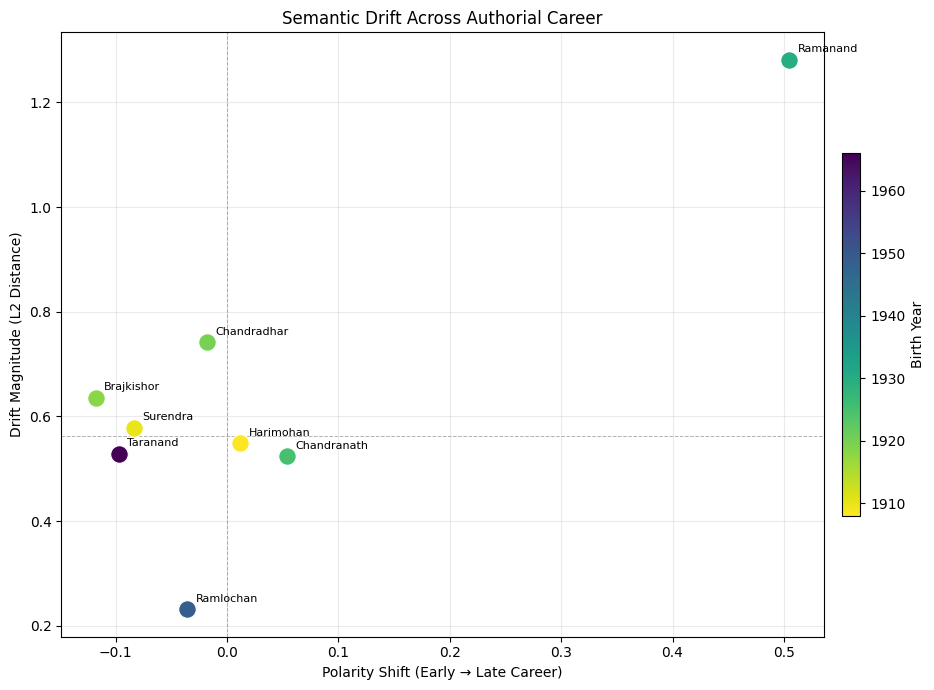

In [ ]:
# §9.2 Semantic Drift Visualisation
fig, ax = plt.subplots(figsize=(10, 7))

birth_min = min(AUTHOR_BIRTH_YEARS.values())
birth_max = max(AUTHOR_BIRTH_YEARS.values())
birth_range = birth_max - birth_min if birth_max != birth_min else 1

for _, row in drift_df.iterrows():
    by = AUTHOR_BIRTH_YEARS[row['author']]
    c = plt.cm.viridis_r((by - birth_min) / birth_range)
    ax.scatter(row['polarity_shift_early_to_late'], row['drift_magnitude'],
               s=160, color=c, zorder=5, edgecolors='white', linewidths=0.8)
    short = row['author'].split()[0]
    ax.annotate(short,
                (row['polarity_shift_early_to_late'], row['drift_magnitude']),
                fontsize=8, ha='left', va='bottom', xytext=(6, 4),
                textcoords='offset points')

ax.axhline(drift_df['drift_magnitude'].median(), color='gray', ls='--', lw=0.7, alpha=0.6)
ax.axvline(0, color='gray', ls='--', lw=0.7, alpha=0.6)
ax.set_xlabel('Polarity Shift (Early \u2192 Late Career)')
ax.set_ylabel('Drift Magnitude (L2 Distance)')
ax.set_title('Semantic Drift Across Authorial Career')

sm = plt.cm.ScalarMappable(cmap='viridis_r',
                           norm=plt.Normalize(birth_min, birth_max))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Birth Year')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

---
## §10 Authorship Attribution Modelling

This section has exactly two paradigms: classical ML over one unified Stylometric
+ CharWord feature matrix, and end-to-end transformer fine-tuning. Frozen
transformer embeddings are removed because they answer a feature-extraction
question, not the requested classification-learning question.


### §10.1 Labels and Unified Classical Feature Matrix

The classical branch sees one representation only. Dense stylometric features
and sparse character/word TF-IDF are scaled separately, then concatenated with
`scipy.sparse.hstack` for all classical models.


In [ ]:
# Encode labels once and build the single classical input matrix.
# Component shapes are printed for auditability, but only the unified matrix is
# evaluated in the classical leaderboard.
le = LabelEncoder()
y = le.fit_transform(chunk_authors)
author_names = le.classes_
n_classes = len(author_names)
id2label = {i: a for i, a in enumerate(author_names)}
label2id = {a: i for i, a in id2label.items()}
print(f"Classes: {n_classes}")
for i, a in enumerate(author_names):
    print(f"  [{i}] {a:<45} {(y==i).sum():>3} chunks")
X_stylo_scaled = StandardScaler().fit_transform(feature_df.values)
X_stylo_sparse = csr_matrix(X_stylo_scaled)
char_vec = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 4),
    max_features=200,
    min_df=2,
    sublinear_tf=True,
)
word_vec = TfidfVectorizer(
    analyzer="word", ngram_range=(1, 2), max_features=300, min_df=2, sublinear_tf=True
)
X_char = MaxAbsScaler().fit_transform(char_vec.fit_transform(flat_chunks))
X_word = MaxAbsScaler().fit_transform(word_vec.fit_transform(flat_chunks))
X_classical = sp_hstack([X_stylo_sparse, X_char, X_word], format="csr")
unified_feature_names = (
    list(feature_df.columns)
    + [f"char::{f}" for f in char_vec.get_feature_names_out()]
    + [f"word::{f}" for f in word_vec.get_feature_names_out()]
)
print("-" * 80)
print(f"Stylometric block : {X_stylo_sparse.shape}")
print(f"Character TF-IDF  : {X_char.shape}")
print(f"Word TF-IDF       : {X_word.shape}")
print(f"Unified classical : {X_classical.shape}")

Classes: 8
  [0] Brajkishor Varma 'Manipadam'                   13 chunks
  [1] Chandradhar Jha                                14 chunks
  [2] Chandranath Mishra 'Amar'                      14 chunks
  [3] Harimohan Jha                                  14 chunks
  [4] Ramanand Jha 'Raman'                           14 chunks
  [5] Ramlochan Thakur                               14 chunks
  [6] Surendra Jha 'Suman'                           12 chunks
  [7] Taranand Viyogi                                14 chunks
--------------------------------------------------------------------------------
Stylometric block : (109, 77)
Character TF-IDF  : (109, 200)
Word TF-IDF       : (109, 300)
Unified classical : (109, 577)


### §10.2 Cross-Validation Scoring Utilities

Fold-level scoring is necessary for a corpus this small. The helper stores
out-of-fold predictions and class scores so later per-author analysis uses only
held-out evidence.


In [ ]:
# Shared evaluator for classical models: fresh estimator per fold, mean +/- std
# metrics, and stored out-of-fold predictions for interpretation cells.
def _safe_roc_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score, multi_class="ovr", average="macro")
    except Exception:
        return np.nan


def _scores_to_probabilities(scores):
    scores = np.asarray(scores, dtype=float)
    if scores.ndim == 1:
        scores = np.column_stack([-scores, scores])
    if np.all(scores >= 0) and np.allclose(scores.sum(axis=1), 1.0, atol=1e-3):
        return scores
    scores = scores - np.nanmax(scores, axis=1, keepdims=True)
    exp = np.exp(scores)
    return exp / np.clip(exp.sum(axis=1, keepdims=True), 1e-12, None)


def _predict_scores(model, X_test):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test)
    if hasattr(model, "decision_function"):
        return model.decision_function(X_test)
    return None


def evaluate_cv_model(
    model_factory, X, y, cv, model_name, paradigm, feature_name, variant=""
):
    start = time.time()
    y_pred = np.empty_like(y)
    y_score = np.full((len(y), n_classes), np.nan)
    folds = []
    for fold_id, (tr, te) in enumerate(cv.split(X, y), 1):
        model = model_factory()
        Xtr = X[tr] if hasattr(X, "tocsr") else X[tr, :]
        Xte = X[te] if hasattr(X, "tocsr") else X[te, :]
        model.fit(Xtr, y[tr])
        pred = model.predict(Xte)
        scores = _predict_scores(model, Xte)
        y_pred[te] = pred
        if scores is not None:
            y_score[te, :] = _scores_to_probabilities(scores)
        folds.append(
            {
                "fold": fold_id,
                "accuracy": accuracy_score(y[te], pred),
                "f1_macro": f1_score(y[te], pred, average="macro"),
                "roc_auc": (
                    _safe_roc_auc(y[te], y_score[te, :])
                    if scores is not None
                    else np.nan
                ),
            }
        )
    fold_df = pd.DataFrame(folds)
    return {
        "model": model_name,
        "paradigm": paradigm,
        "features": feature_name,
        "variant": variant
        or ("classical" if paradigm == "Classical ML" else model_name),
        "accuracy": accuracy_score(y, y_pred),
        "f1_macro": f1_score(y, y_pred, average="macro"),
        "roc_auc": _safe_roc_auc(y, y_score) if not np.isnan(y_score).all() else np.nan,
        "accuracy_mean": fold_df.accuracy.mean(),
        "accuracy_std": fold_df.accuracy.std(ddof=0),
        "f1_macro_mean": fold_df.f1_macro.mean(),
        "f1_macro_std": fold_df.f1_macro.std(ddof=0),
        "roc_auc_mean": fold_df.roc_auc.mean(),
        "roc_auc_std": fold_df.roc_auc.std(ddof=0),
        "time_sec": time.time() - start,
        "y_pred": y_pred,
        "y_score": y_score,
        "fold_metrics": fold_df,
    }


def format_mean_std(mean, std):
    return "N/A" if pd.isna(mean) else f"{mean:.3f} +/- {std:.3f}"


N_FOLDS = min(3, min(Counter(y).values()))
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
print(f"Using stratified {N_FOLDS}-fold CV.")

Using stratified 3-fold CV.


### §10.3 Classical ML Leaderboard

Every classical estimator consumes `X_classical`, the fused Stylometric +
CharWord matrix. The notebook no longer reports separate stylometric or n-gram
leaderboards.


In [ ]:
# Factories guarantee clean estimators for each fold. All rows belong to one
# classical paradigm and one unified feature set.
def get_classical_model_zoo():
    return {
        "LogisticRegression": lambda: LogisticRegression(
            C=1.0,
            solver="saga",
            penalty="l2",
            max_iter=3000,
            multi_class="multinomial",
            random_state=SEED,
            n_jobs=-1,
        ),
        "LinearSVC": lambda: LinearSVC(C=1.0, max_iter=4000, random_state=SEED),
        "SVM_RBF": lambda: SVC(
            kernel="rbf", C=10.0, gamma="scale", probability=True, random_state=SEED
        ),
        "RandomForest": lambda: RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=SEED,
            n_jobs=-1,
        ),
        "XGBoost": lambda: xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="mlogloss",
            random_state=SEED,
            verbosity=0,
            n_jobs=-1,
        ),
        "LightGBM": lambda: lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.08,
            num_leaves=15,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=SEED,
            verbose=-1,
            n_jobs=-1,
        ),
    }


classical_results = []
print("=" * 96)
print("CLASSICAL ML - unified Stylometric + CharWord features")
print("=" * 96)
for name, factory in get_classical_model_zoo().items():
    r = evaluate_cv_model(
        factory,
        X_classical,
        y,
        cv,
        name,
        "Classical ML",
        "Unified_Stylometric_CharWord",
    )
    classical_results.append(r)
    print(
        f'  {name:<20} acc={format_mean_std(r["accuracy_mean"],r["accuracy_std"]):<17} f1m={format_mean_std(r["f1_macro_mean"],r["f1_macro_std"]):<17} auc={format_mean_std(r["roc_auc_mean"],r["roc_auc_std"])}'
    )
all_results = list(classical_results)
classical_leaderboard = (
    pd.DataFrame(
        [
            {
                k: v
                for k, v in r.items()
                if k not in ("y_pred", "y_score", "fold_metrics")
            }
            for r in classical_results
        ]
    )
    .sort_values("f1_macro_mean", ascending=False)
    .reset_index(drop=True)
)
classical_leaderboard.index += 1
classical_leaderboard.index.name = "Rank"
print()
print("Classical leaderboard")
print(
    classical_leaderboard[
        [
            "model",
            "features",
            "accuracy_mean",
            "accuracy_std",
            "f1_macro_mean",
            "f1_macro_std",
            "roc_auc_mean",
            "roc_auc_std",
            "time_sec",
        ]
    ]
    .round(4)
    .to_string()
)

CLASSICAL ML - unified Stylometric + CharWord features
  LogisticRegression   acc=0.825 +/- 0.067   f1m=0.817 +/- 0.073   auc=0.981 +/- 0.011
  LinearSVC            acc=0.816 +/- 0.036   f1m=0.815 +/- 0.041   auc=0.972 +/- 0.004
  SVM_RBF              acc=0.816 +/- 0.081   f1m=0.808 +/- 0.083   auc=0.972 +/- 0.012
  RandomForest         acc=0.844 +/- 0.012   f1m=0.832 +/- 0.012   auc=0.975 +/- 0.005
  XGBoost              acc=0.780 +/- 0.061   f1m=0.768 +/- 0.062   auc=0.963 +/- 0.018
  LightGBM             acc=0.816 +/- 0.027   f1m=0.807 +/- 0.030   auc=0.974 +/- 0.011

Classical leaderboard
                   model                      features  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  roc_auc_mean  roc_auc_std  time_sec
Rank                                                                                                                                                 
1           RandomForest  Unified_Stylometric_CharWord         0.8441        0.0122         0.8324  

### §10.4 Classical Robustness and Interpretability Diagnostics

LOAO, grouped CV, ablation, and stacking are retained as diagnostics around the
same unified classical input. They explain robustness without creating extra
feature paradigms.


In [ ]:
# LOAO shows nearest stylistic neighbours for an unseen author; grouped CV checks
# leakage risk; ablation explains the hand-engineered part of the unified matrix.
def evaluate_loao(model_factory, X, y, groups, model_name):
    logo = LeaveOneGroupOut()
    accs = []
    pairs = []
    for tr, te in logo.split(X, y, groups=groups):
        model = model_factory()
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        pairs.append((y[te][0], Counter(pred).most_common(1)[0][0]))
        accs.append((pred == y[te]).mean())
    return {
        "mean": float(np.mean(accs)),
        "std": float(np.std(accs)),
        "pairs": pairs,
        "model": model_name,
    }


def make_pseudo_groups(chunk_authors, block_size=2):
    groups = []
    counts = Counter()
    for a in chunk_authors:
        groups.append(f"{a}__block{counts[a]//block_size}")
        counts[a] += 1
    return np.array(groups)


def family_columns(df, prefixes):
    return [c for c in df.columns if any(c.startswith(p) or p in c for p in prefixes)]


def ablation_rf():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=250, min_samples_leaf=2, random_state=SEED, n_jobs=-1
                ),
            ),
        ]
    )


def ablation_study(feature_df, y, families, cv):
    rows = []
    full = cross_val_score(
        ablation_rf(), feature_df.values, y, cv=cv, scoring="accuracy"
    ).mean()
    rows.append(
        {
            "condition": "ALL_FEATURES",
            "family": "all",
            "n_features": feature_df.shape[1],
            "accuracy": full,
            "delta_from_full": 0.0,
        }
    )
    for fam, prefixes in families.items():
        cols = family_columns(feature_df, prefixes)
        if not cols:
            continue
        only = cross_val_score(
            ablation_rf(), feature_df[cols].values, y, cv=cv, scoring="accuracy"
        ).mean()
        keep = [c for c in feature_df.columns if c not in cols]
        loo = cross_val_score(
            ablation_rf(), feature_df[keep].values, y, cv=cv, scoring="accuracy"
        ).mean()
        rows += [
            {
                "condition": "ONLY",
                "family": fam,
                "n_features": len(cols),
                "accuracy": only,
                "delta_from_full": only - full,
            },
            {
                "condition": "LOFO",
                "family": fam,
                "n_features": len(keep),
                "accuracy": loo,
                "delta_from_full": loo - full,
            },
        ]
    return pd.DataFrame(rows)


best_classical_name = classical_leaderboard.iloc[0]["model"]
best_classical_factory = get_classical_model_zoo()[best_classical_name]
loao = evaluate_loao(
    best_classical_factory, X_classical, y, chunk_authors, best_classical_name
)
print("=" * 90)
print(f"LOAO - {best_classical_name} on unified classical features")
print("=" * 90)
print(f'Mean held-out accuracy: {loao["mean"]:.3f} +/- {loao["std"]:.3f}')
for held, pred in loao["pairs"]:
    print(f"  {author_names[held]:<45} -> {author_names[pred]}")

pseudo_groups = make_pseudo_groups(chunk_authors)
gkf = GroupKFold(n_splits=min(5, len(set(pseudo_groups))))
grouped_scores = cross_val_score(
    best_classical_factory(),
    X_classical,
    y,
    cv=gkf,
    groups=pseudo_groups,
    scoring="accuracy",
)
std_row = classical_leaderboard[
    classical_leaderboard.model == best_classical_name
].iloc[0]
print()
print("Grouped CV robustness:")
print(
    f"  Standard {N_FOLDS}-fold : {std_row.accuracy_mean:.3f} +/- {std_row.accuracy_std:.3f}"
)
print(
    f"  Grouped {gkf.n_splits}-fold   : {grouped_scores.mean():.3f} +/- {grouped_scores.std():.3f}"
)

ablation_df = ablation_study(feature_df, y, FEATURE_FAMILIES, cv)
ablation_pivot = ablation_df.pivot_table(
    index="family", columns="condition", values="accuracy", aggfunc="first"
)
full_acc = ablation_df.loc[ablation_df.condition == "ALL_FEATURES", "accuracy"].iloc[0]
ablation_pivot["marginal_gain"] = full_acc - ablation_pivot.get("LOFO", np.nan)
print()
print("Feature-family ablation (interpretive stylometric diagnostic):")
print(ablation_pivot.round(4).to_string())


def stacking_factory():
    estimators = [
        ("lr", LogisticRegression(C=1.0, max_iter=2500, random_state=SEED, n_jobs=-1)),
        ("linear_svm", LinearSVC(C=1.0, max_iter=4000, random_state=SEED)),
        (
            "lgbm",
            lgb.LGBMClassifier(
                n_estimators=150,
                learning_rate=0.08,
                num_leaves=15,
                random_state=SEED,
                verbose=-1,
                n_jobs=-1,
            ),
        ),
    ]
    return StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(
            C=2.0, max_iter=2500, random_state=SEED, n_jobs=-1
        ),
        cv=3,
        n_jobs=-1,
        stack_method="auto",
    )


stack_result = evaluate_cv_model(
    stacking_factory,
    X_classical,
    y,
    cv,
    "Stacking_Ensemble",
    "Classical ML",
    "Unified_Stylometric_CharWord",
)
classical_results.append(stack_result)
all_results = list(classical_results)
print()
print("Stacking ensemble:")
print(
    f'  accuracy={format_mean_std(stack_result["accuracy_mean"],stack_result["accuracy_std"])}  f1m={format_mean_std(stack_result["f1_macro_mean"],stack_result["f1_macro_std"])}  auc={format_mean_std(stack_result["roc_auc_mean"],stack_result["roc_auc_std"])}'
)

LOAO - RandomForest on unified classical features
Mean held-out accuracy: 0.000 +/- 0.000
  Brajkishor Varma 'Manipadam'                  -> Taranand Viyogi
  Chandradhar Jha                               -> Harimohan Jha
  Chandranath Mishra 'Amar'                     -> Chandradhar Jha
  Harimohan Jha                                 -> Chandradhar Jha
  Ramanand Jha 'Raman'                          -> Taranand Viyogi
  Ramlochan Thakur                              -> Taranand Viyogi
  Surendra Jha 'Suman'                          -> Chandranath Mishra 'Amar'
  Taranand Viyogi                               -> Ramlochan Thakur

Grouped CV robustness:
  Standard 3-fold : 0.844 +/- 0.012
  Grouped 5-fold   : 0.853 +/- 0.078

Feature-family ablation (interpretive stylometric diagnostic):
condition             ALL_FEATURES    LOFO    ONLY  marginal_gain
family                                                           
F01_lexical_richness           NaN  0.7155  0.4039         0.0460
F02_po

### §10.5 End-to-End Transformer Fine-Tuning Helpers

Transformers now learn the authorship task directly: text enters the encoder,
then the pooled/CLS representation goes through dropout and a linear classifier.
LoRA is the regularised low-parameter variant for the small corpus.


In [ ]:
# import glob

# # Remove any broken MaiBERT partial caches
# for p in glob.glob(os.path.join(CACHE_DIR, 'transformer_partial_MaiBERT_*.pkl')):
#     os.remove(p)
#     print(f'Removed: {os.path.basename(p)}')

# print('Ready — now re-run the transformer training cell.')

In [ ]:
import torch, os
from pathlib import Path
from safetensors.torch import load_file, save_file

MAIBERT_LOCAL = os.path.join(CACHE_DIR, "maiBERT_pytorch")
sf_path = os.path.join(MAIBERT_LOCAL, "model.safetensors")

state_dict = load_file(sf_path)
fixed = {}
for k, v in state_dict.items():
    new_k = k.replace("LayerNorm.beta", "LayerNorm.bias").replace(
        "LayerNorm.gamma", "LayerNorm.weight"
    )
    fixed[new_k] = v

save_file(fixed, sf_path)
print("✓ LayerNorm keys fixed.")
print("LayerNorm keys now:", [k for k in fixed if "LayerNorm" in k][:4])

✓ LayerNorm keys fixed.
LayerNorm keys now: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight']


In [ ]:
import os, shutil, torch, h5py, numpy as np
from pathlib import Path
from huggingface_hub import hf_hub_download
from transformers import BertModel, BertConfig, AutoTokenizer

MAIBERT_LOCAL = os.path.join(CACHE_DIR, "maiBERT_pytorch")

# Force clean slate
shutil.rmtree(MAIBERT_LOCAL, ignore_errors=True)
os.makedirs(MAIBERT_LOCAL, exist_ok=True)

# Download all files
print("Downloading...")
for fname in [
    "config.json",
    "vocab.txt",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "tf_model.h5",
]:
    hf_hub_download("rockerritesh/maiBERT_TF", fname, local_dir=MAIBERT_LOCAL)
    print(f"  ✓ {fname}")

# Load config directly from the downloaded file
import json

with open(os.path.join(MAIBERT_LOCAL, "config.json")) as f:
    cfg_dict = json.load(f)
config = BertConfig(
    **{k: v for k, v in cfg_dict.items() if k in BertConfig().to_dict()}
)
print(f"\nConfig: {config.hidden_size} hidden, {config.num_hidden_layers} layers")

# Manual TF → PyTorch weight mapping
h5_path = os.path.join(MAIBERT_LOCAL, "tf_model.h5")
PREFIX = "bert/tf_bert_for_masked_lm_1/bert"


def t(arr):
    return torch.tensor(np.array(arr), dtype=torch.float32)


def load(f, key):
    return t(f[f"{PREFIX}/{key}"])


print("Building state dict...")
state_dict = {}
with h5py.File(h5_path, "r") as f:
    state_dict["embeddings.word_embeddings.weight"] = load(
        f, "embeddings/word_embeddings/weight:0"
    )
    state_dict["embeddings.position_embeddings.weight"] = load(
        f, "embeddings/position_embeddings/embeddings:0"
    )
    state_dict["embeddings.token_type_embeddings.weight"] = load(
        f, "embeddings/token_type_embeddings/embeddings:0"
    )
    state_dict["embeddings.LayerNorm.weight"] = load(f, "embeddings/LayerNorm/gamma:0")
    state_dict["embeddings.LayerNorm.bias"] = load(f, "embeddings/LayerNorm/beta:0")

    for i in range(12):
        lp = f"encoder/layer_._{i}"
        pp = f"encoder.layer.{i}"
        for qkv in ("query", "key", "value"):
            state_dict[f"{pp}.attention.self.{qkv}.weight"] = load(
                f, f"{lp}/attention/self/{qkv}/kernel:0"
            ).T
            state_dict[f"{pp}.attention.self.{qkv}.bias"] = load(
                f, f"{lp}/attention/self/{qkv}/bias:0"
            )
        state_dict[f"{pp}.attention.output.dense.weight"] = load(
            f, f"{lp}/attention/output/dense/kernel:0"
        ).T
        state_dict[f"{pp}.attention.output.dense.bias"] = load(
            f, f"{lp}/attention/output/dense/bias:0"
        )
        state_dict[f"{pp}.attention.output.LayerNorm.weight"] = load(
            f, f"{lp}/attention/output/LayerNorm/gamma:0"
        )
        state_dict[f"{pp}.attention.output.LayerNorm.bias"] = load(
            f, f"{lp}/attention/output/LayerNorm/beta:0"
        )
        state_dict[f"{pp}.intermediate.dense.weight"] = load(
            f, f"{lp}/intermediate/dense/kernel:0"
        ).T
        state_dict[f"{pp}.intermediate.dense.bias"] = load(
            f, f"{lp}/intermediate/dense/bias:0"
        )
        state_dict[f"{pp}.output.dense.weight"] = load(
            f, f"{lp}/output/dense/kernel:0"
        ).T
        state_dict[f"{pp}.output.dense.bias"] = load(f, f"{lp}/output/dense/bias:0")
        state_dict[f"{pp}.output.LayerNorm.weight"] = load(
            f, f"{lp}/output/LayerNorm/gamma:0"
        )
        state_dict[f"{pp}.output.LayerNorm.bias"] = load(
            f, f"{lp}/output/LayerNorm/beta:0"
        )

    if f"{PREFIX}/pooler/dense/kernel:0" in f:
        state_dict["pooler.dense.weight"] = load(f, "pooler/dense/kernel:0").T
        state_dict["pooler.dense.bias"] = load(f, "pooler/dense/bias:0")
        print("  ✓ Pooler found")
    else:
        print(
            "  ⚠ No pooler — will be randomly initialised (normal for MLM checkpoint)"
        )

print(f"State dict: {len(state_dict)} tensors")

# Load into PyTorch model
pt_model = BertModel(config)
missing, unexpected = pt_model.load_state_dict(state_dict, strict=False)
print(f"Missing   : {missing}")
print(f"Unexpected: {unexpected}")

# Save
pt_model.save_pretrained(MAIBERT_LOCAL, safe_serialization=True)

# Save tokenizer directly from downloaded files (no from_pretrained needed)
tokenizer = AutoTokenizer.from_pretrained(MAIBERT_LOCAL, local_files_only=True)
tokenizer.save_pretrained(MAIBERT_LOCAL)

print(f"\n✓ Files: {os.listdir(MAIBERT_LOCAL)}")
print(
    f'✓ model.safetensors present: {(Path(MAIBERT_LOCAL) / "model.safetensors").exists()}'
)

Downloading...


config.json:   0%|          | 0.00/633 [00:00<?, ?B/s]

  ✓ config.json


vocab.txt: 0.00B [00:00, ?B/s]

  ✓ vocab.txt


...

  ✓ special_tokens_map.json


tf_model.h5:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

  ✓ tf_model.h5

Config: 768 hidden, 12 layers
Building state dict...
  ⚠ No pooler — will be randomly initialised (normal for MLM checkpoint)
State dict: 197 tensors
Missing   : ['pooler.dense.weight', 'pooler.dense.bias']
Unexpected: []


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Files: ['.cache', 'config.json', 'vocab.txt', 'tokenizer_config.json', 'special_tokens_map.json', 'tf_model.h5', 'model.safetensors', 'tokenizer.json']
✓ model.safetensors present: True


In [ ]:
!pip install torchao --upgrade -q
print("Done — RESTART RUNTIME NOW, then run from Cell 2 below.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 19.2 MB/s eta 0:00:00
Done — RESTART RUNTIME NOW, then run from Cell 2 below.


In [ ]:
# No frozen embedding extraction is defined here. The only transformer path is
# full or LoRA fine-tuning with held-out fold predictions.
TRANSFORMER_MODELS = [
    {"short_name": "MaiBERT", "model_name": MAIBERT_LOCAL},
    {"short_name": "XLM-R", "model_name": "xlm-roberta-base"},
]
TRANSFORMER_VARIANTS = ["full_finetune", "lora"]

print("Transformer fine-tuning plan:")
for m in TRANSFORMER_MODELS:
    print(f'  {m["short_name"]:<12} {m["model_name"]}')
print(f"  Epochs: full={FULL_FINETUNE_EPOCHS}, lora={LORA_FINETUNE_EPOCHS}")


class AuthorshipTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = list(texts)
        self.labels = np.asarray(labels, dtype=int)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = self.tokenizer(
            self.texts[idx], truncation=True, max_length=self.max_length
        )
        item["labels"] = int(self.labels[idx])
        return item


def make_training_args(output_dir, variant):
    kwargs = {
        "output_dir": output_dir,
        "num_train_epochs": (
            FULL_FINETUNE_EPOCHS if variant == "full_finetune" else LORA_FINETUNE_EPOCHS
        ),
        "learning_rate": 2e-5 if variant == "full_finetune" else 5e-5,
        "per_device_train_batch_size": TRANSFORMER_BATCH_SIZE,
        "per_device_eval_batch_size": TRANSFORMER_BATCH_SIZE,
        "gradient_accumulation_steps": 2,  # effective batch = BATCH_SIZE * 2
        "gradient_checkpointing": True,  # ~40% activation RAM saving
        "dataloader_pin_memory": False,  # no duplicate pinned CPU copy
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,  # NEW — stabilises early training steps
        "logging_strategy": "epoch",  # NEW — shows loss per epoch (was 'no')
        "save_strategy": "epoch",  # NEW — needed for load_best_model_at_end
        "load_best_model_at_end": True,  # NEW — picks best checkpoint, not last
        "metric_for_best_model": "eval_loss",
        "greater_is_better": False,
        "report_to": "none",
        "seed": SEED,
        "data_seed": SEED,
        "fp16": torch.cuda.is_available(),
    }
    sig = inspect.signature(TrainingArguments.__init__)
    kwargs[
        "eval_strategy" if "eval_strategy" in sig.parameters else "evaluation_strategy"
    ] = "epoch"
    return TrainingArguments(**{k: v for k, v in kwargs.items() if k in sig.parameters})


def infer_lora_targets(model):
    preferred = {"query", "key", "value", "dense", "q_lin", "k_lin", "v_lin", "out_lin"}
    found = sorted(
        {
            n.split(".")[-1]
            for n, m in model.named_modules()
            if isinstance(m, torch.nn.Linear) and n.split(".")[-1] in preferred
        }
    )
    return found or ["query", "value"]


def build_transformer_model(model_name, variant):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=n_classes, id2label=id2label, label2id=label2id
    )
    hidden = getattr(model.config, "hidden_size", 768)
    print(
        f"  Architecture: Text -> Transformer -> [CLS]/pool -> Dropout -> Linear({hidden}, {n_classes})"
    )
    if variant == "lora":
        targets = infer_lora_targets(model)
        cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=8,
            lora_alpha=16,
            lora_dropout=0.15,
            target_modules=targets,
            bias="none",
        )
        model = get_peft_model(model, cfg)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(
            f"  LoRA targets={targets} | trainable={trainable:,}/{total:,} ({trainable/total:.2%})"
        )
    # Enable gradient checkpointing on the base model (works for both full and LoRA)
    base = model.base_model if hasattr(model, "base_model") else model
    if hasattr(base, "gradient_checkpointing_enable"):
        base.gradient_checkpointing_enable()
    return model


def evaluate_transformer_cv(model_cfg, variant, cv):
    model_name = model_cfg["model_name"]
    short = model_cfg["short_name"]
    run = f"{short}_{variant}"
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    y_pred = np.empty_like(y)
    y_score = np.full((len(y), n_classes), np.nan)
    folds = []
    start = time.time()

    for fold_id, (tr, te) in enumerate(cv.split(flat_chunks, y), 1):
        print()
        print(f"{run} | fold {fold_id}/{cv.n_splits}")
        train_ds = AuthorshipTextDataset(
            [flat_chunks[i] for i in tr], y[tr], tokenizer, TRANSFORMER_MAX_LENGTH
        )
        test_ds = AuthorshipTextDataset(
            [flat_chunks[i] for i in te], y[te], tokenizer, TRANSFORMER_MAX_LENGTH
        )
        del tokenizer  # free RAM during training; collator keeps its own ref

        model = build_transformer_model(model_name, variant)
        args = make_training_args(
            os.path.join(CACHE_DIR, "trainer_runs", run, f"fold_{fold_id}"), variant
        )
        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=train_ds,
            eval_dataset=test_ds,
            processing_class=collator.tokenizer,  # replaces deprecated tokenizer=
            data_collator=collator,
        )
        trainer.train()
        pred_out = trainer.predict(test_ds)
        probs = _scores_to_probabilities(pred_out.predictions)
        pred = probs.argmax(axis=1)
        y_pred[te] = pred
        y_score[te, :] = probs
        folds.append(
            {
                "fold": fold_id,
                "accuracy": accuracy_score(y[te], pred),
                "f1_macro": f1_score(y[te], pred, average="macro"),
                "roc_auc": _safe_roc_auc(y[te], probs),
            }
        )
        del trainer, model, train_ds, test_ds
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        # Rebuild tokenizer and collator for the next fold
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        collator = DataCollatorWithPadding(tokenizer=tokenizer)

    fold_df = pd.DataFrame(folds)
    return {
        "model": short,
        "paradigm": "Fine-tuned Transformer",
        "features": "Text",
        "variant": variant,
        "accuracy": accuracy_score(y, y_pred),
        "f1_macro": f1_score(y, y_pred, average="macro"),
        "roc_auc": _safe_roc_auc(y, y_score),
        "accuracy_mean": fold_df.accuracy.mean(),
        "accuracy_std": fold_df.accuracy.std(ddof=0),
        "f1_macro_mean": fold_df.f1_macro.mean(),
        "f1_macro_std": fold_df.f1_macro.std(ddof=0),
        "roc_auc_mean": fold_df.roc_auc.mean(),
        "roc_auc_std": fold_df.roc_auc.std(ddof=0),
        "time_sec": time.time() - start,
        "y_pred": y_pred,
        "y_score": y_score,
        "fold_metrics": fold_df,
    }

Transformer fine-tuning plan:
  MaiBERT      /content/drive/MyDrive/Colab_Notebooks/Maithili_Authorship/Maithili_Author_Models/maiBERT_pytorch
  XLM-R        xlm-roberta-base
  Epochs: full=5, lora=8


In [ ]:
# # Optional: clean up trainer checkpoint folders after results are cached
# import shutil, os
# trainer_runs_dir = os.path.join(CACHE_DIR, 'trainer_runs')
# if os.path.exists(trainer_runs_dir):
#     shutil.rmtree(trainer_runs_dir)
#     print('Trainer checkpoints cleaned up.')

### §10.6 Run Fine-Tuned Transformer CV

This is the only transformer experiment in the final notebook. Results are
cached after completion, but the cache stores final CV outputs, not reusable
frozen embeddings.


In [ ]:
# ── Transformer fine-tuning — cached run ──────────────────────────────────────
# Cache key encodes every factor that would change the result.
# Set FORCE_TRANSFORMER_RERUN=True in Cell 8 to retrain from scratch.


def _transformer_cache_key():
    payload = (
        "||".join(flat_chunks)
        + "||"
        + "|".join(map(str, y.tolist()))
        + "||"
        + "|".join(m["model_name"] for m in TRANSFORMER_MODELS)
        + "||"
        + "|".join(TRANSFORMER_VARIANTS)
        + f"||folds={N_FOLDS}|seed={SEED}|maxlen={TRANSFORMER_MAX_LENGTH}"
        + f"|batch={TRANSFORMER_BATCH_SIZE}"
        + f"|epochs_full={FULL_FINETUNE_EPOCHS}|epochs_lora={LORA_FINETUNE_EPOCHS}"
    )
    return hashlib.md5(payload.encode("utf-8")).hexdigest()[:12]


TRANSFORMER_RESULTS_CACHE = os.path.join(
    CACHE_DIR, f"transformer_finetune_cv_results_{_transformer_cache_key()}.pkl"
)


def _run_transformer_finetuning():
    results = []
    for model_cfg in TRANSFORMER_MODELS:
        for variant in TRANSFORMER_VARIANTS:

            # Force a clean memory state before each combination.
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            print(f'\n{"=" * 70}')
            print(f'Starting: {model_cfg["short_name"]} / {variant}')
            print(f'{"=" * 70}')

            r = evaluate_transformer_cv(model_cfg, variant, cv)
            results.append(r)

            print(f'\nCompleted {model_cfg["short_name"]} / {variant}:')
            print(
                f'  acc={format_mean_std(r["accuracy_mean"], r["accuracy_std"])} | '
                f'f1m={format_mean_std(r["f1_macro_mean"], r["f1_macro_std"])} | '
                f'auc={format_mean_std(r["roc_auc_mean"], r["roc_auc_std"])}'
            )

            # Save partial result immediately — survives a mid-run crash.
            partial_path = os.path.join(
                CACHE_DIR,
                f'transformer_partial_{model_cfg["short_name"]}_{variant}.pkl',
            )
            with open(partial_path, "wb") as fh:
                pickle.dump(r, fh, protocol=4)
            print(f"  Partial cache saved: {os.path.basename(partial_path)}")

            # Aggressive cleanup between combinations.
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return results


def _load_from_partials():
    """Reconstruct results from per-model partial caches if full cache absent."""
    partials = []
    for model_cfg in TRANSFORMER_MODELS:
        for variant in TRANSFORMER_VARIANTS:
            p = os.path.join(
                CACHE_DIR,
                f'transformer_partial_{model_cfg["short_name"]}_{variant}.pkl',
            )
            if os.path.exists(p):
                with open(p, "rb") as fh:
                    partials.append(pickle.load(fh))
                print(f'  Recovered partial: {model_cfg["short_name"]} / {variant}')
    return partials if partials else None


# ── Main execution ─────────────────────────────────────────────────────────────
if os.path.exists(TRANSFORMER_RESULTS_CACHE) and not FORCE_TRANSFORMER_RERUN:
    print(
        f"Loading cached transformer results: "
        f"{os.path.basename(TRANSFORMER_RESULTS_CACHE)}"
    )
    transformer_results = pickle.load(open(TRANSFORMER_RESULTS_CACHE, "rb"))
else:
    expected = len(TRANSFORMER_MODELS) * len(TRANSFORMER_VARIANTS)
    recovered = _load_from_partials()
    if recovered and len(recovered) == expected:
        print(f"Recovered all {expected} results from partial caches — skipping rerun.")
        transformer_results = recovered
        with open(TRANSFORMER_RESULTS_CACHE, "wb") as fh:
            pickle.dump(transformer_results, fh, protocol=4)
    else:
        if recovered:
            print(
                f"Found {len(recovered)}/{expected} partials — rerunning missing combinations."
            )
        transformer_results = _run_transformer_finetuning()
        with open(TRANSFORMER_RESULTS_CACHE, "wb") as fh:
            pickle.dump(transformer_results, fh, protocol=4)

all_results = list(classical_results) + list(transformer_results)
print(f"\nTotal final runs available: {len(all_results)}")
print(
    f'  Classical ML            : {sum(1 for r in all_results if r["paradigm"] == "Classical ML")}'
)
print(
    f'  Fine-tuned Transformer  : {sum(1 for r in all_results if r["paradigm"] == "Fine-tuned Transformer")}'
)

  Recovered partial: MaiBERT / full_finetune
  Recovered partial: MaiBERT / lora
  Recovered partial: XLM-R / full_finetune
  Recovered partial: XLM-R / lora
Recovered all 4 results from partial caches — skipping rerun.

Total final runs available: 11
  Classical ML            : 7
  Fine-tuned Transformer  : 4


### §10.7 Final Two-Paradigm Leaderboard

The final table has exactly two paradigms: classical ML on the unified feature
matrix, and fine-tuned transformers with full and LoRA variants. No frozen
feature-extractor transformer rows are reported.


In [ ]:
# Mean/std columns are fold-level metrics; pooled predictions are retained only
# for confusion matrices and author-level diagnostics.
leaderboard_rows = []
for r in all_results:
    leaderboard_rows.append(
        {
            "Paradigm": r["paradigm"],
            "Model": r["model"],
            "Variant": r.get("variant", ""),
            "Features": r["features"],
            "Accuracy": format_mean_std(r["accuracy_mean"], r["accuracy_std"]),
            "F1-macro": format_mean_std(r["f1_macro_mean"], r["f1_macro_std"]),
            "ROC-AUC": format_mean_std(r["roc_auc_mean"], r["roc_auc_std"]),
            "f1_macro_mean": r["f1_macro_mean"],
            "accuracy_mean": r["accuracy_mean"],
            "roc_auc_mean": r["roc_auc_mean"],
            "time_sec": r["time_sec"],
        }
    )
final_leaderboard = (
    pd.DataFrame(leaderboard_rows)
    .sort_values(["f1_macro_mean", "accuracy_mean"], ascending=False)
    .reset_index(drop=True)
)
final_leaderboard.index += 1
final_leaderboard.index.name = "Rank"
print("=" * 110)
print("FINAL LEADERBOARD - two paradigms only")
print("=" * 110)
print(
    final_leaderboard[
        ["Paradigm", "Model", "Variant", "Features", "Accuracy", "F1-macro", "ROC-AUC"]
    ].to_string()
)
print()
print("Paradigm counts:")
print(final_leaderboard["Paradigm"].value_counts().to_string())


def best_result(paradigm=None):
    candidates = [
        r for r in all_results if paradigm is None or r["paradigm"] == paradigm
    ]
    return max(candidates, key=lambda r: (r["f1_macro_mean"], r["accuracy_mean"]))

FINAL LEADERBOARD - two paradigms only
                    Paradigm               Model        Variant                      Features         Accuracy         F1-macro          ROC-AUC
Rank                                                                                                                                            
1               Classical ML        RandomForest      classical  Unified_Stylometric_CharWord  0.844 +/- 0.012  0.832 +/- 0.012  0.975 +/- 0.005
2               Classical ML   Stacking_Ensemble      classical  Unified_Stylometric_CharWord  0.825 +/- 0.049  0.818 +/- 0.050  0.977 +/- 0.005
3               Classical ML  LogisticRegression      classical  Unified_Stylometric_CharWord  0.825 +/- 0.067  0.817 +/- 0.073  0.981 +/- 0.011
4               Classical ML           LinearSVC      classical  Unified_Stylometric_CharWord  0.816 +/- 0.036  0.815 +/- 0.041  0.972 +/- 0.004
5               Classical ML             SVM_RBF      classical  Unified_Stylometric_CharWo

### §10.8 Confusion Matrix and Unified Feature Importance

These visuals explain the best classical model because its features are
inspectable. They show both author-pair confusions and which unified feature
families carry the strongest signal.


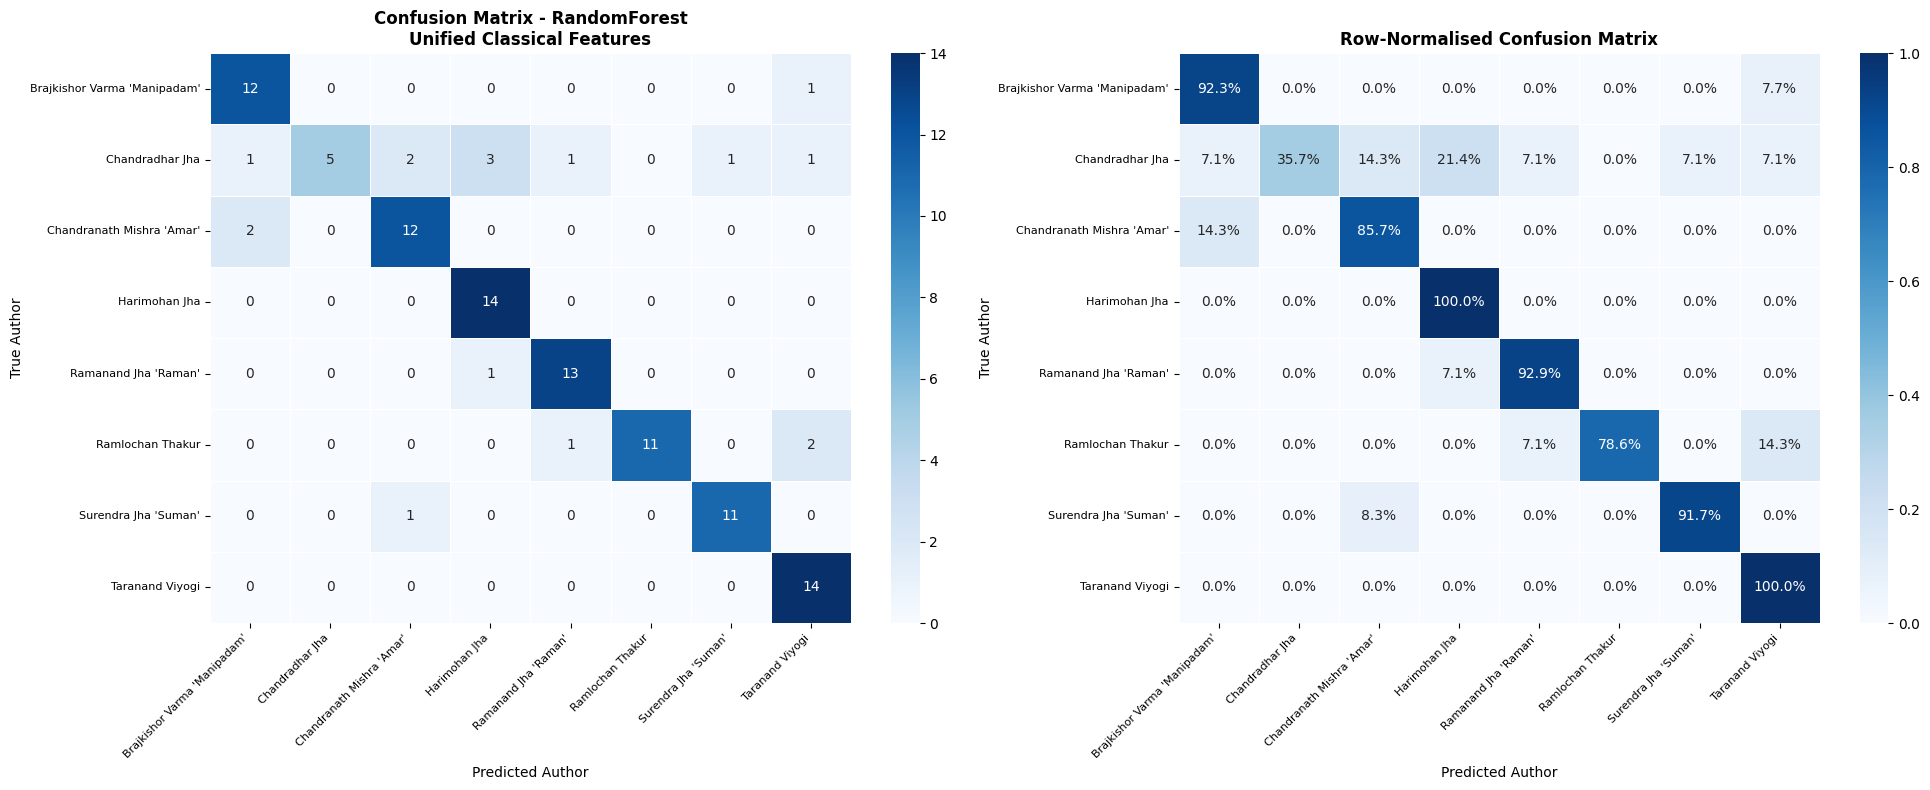


Most-confused author pairs:
  Chandradhar Jha                          mistaken for Harimohan Jha                             3x (influence graph not yet built)
  Chandradhar Jha                          mistaken for Chandranath Mishra 'Amar'                 2x (influence graph not yet built)
  Chandranath Mishra 'Amar'                mistaken for Brajkishor Varma 'Manipadam'              2x (influence graph not yet built)
  Ramlochan Thakur                         mistaken for Taranand Viyogi                           2x (influence graph not yet built)
  Brajkishor Varma 'Manipadam'             mistaken for Taranand Viyogi                           1x (influence graph not yet built)


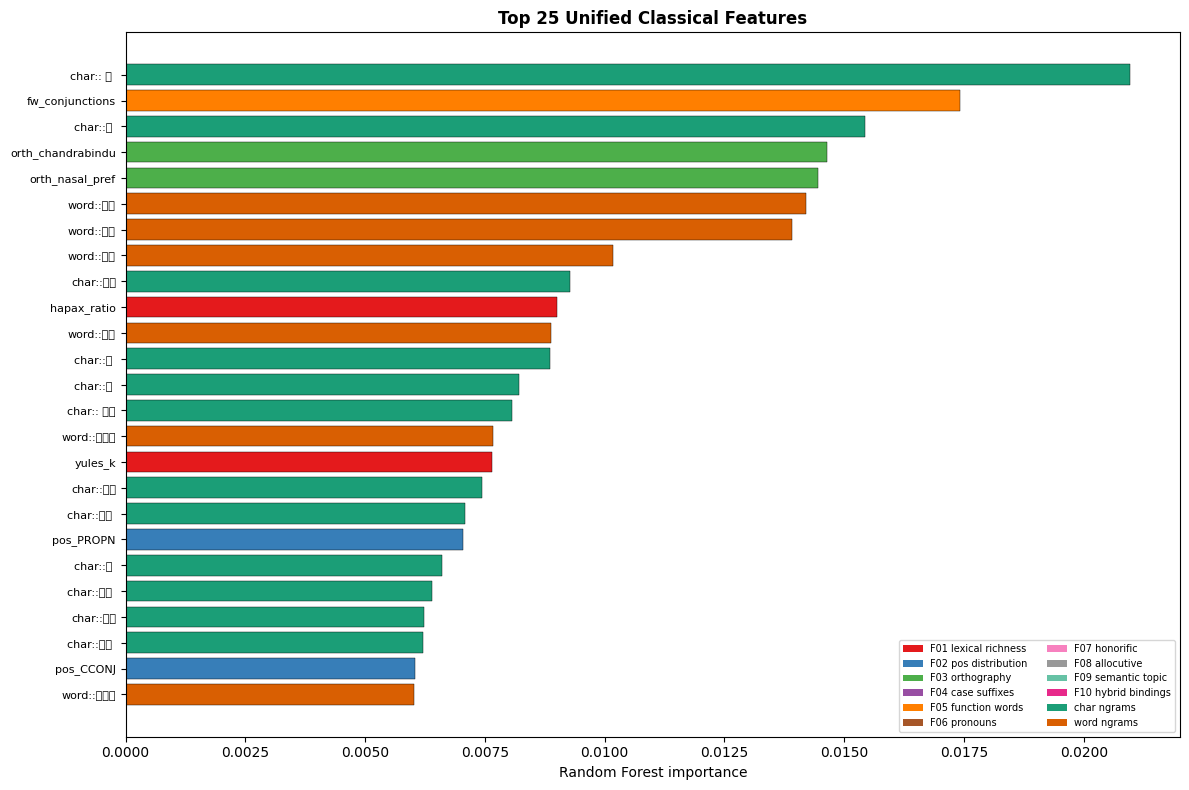

Top 15 unified features by importance:
  char:: आ                                      0.0210 [char_ngrams]
  fw_conjunctions                               0.0174 [F05_function_words]
  char::आ                                       0.0154 [char_ngrams]
  orth_chandrabindu                             0.0147 [F03_orthography]
  orth_nasal_pref                               0.0145 [F03_orthography]
  word::और                                      0.0142 [word_ngrams]
  word::भए                                      0.0139 [word_ngrams]
  word::कय                                      0.0102 [word_ngrams]
  char::ाँ                                      0.0093 [char_ngrams]
  hapax_ratio                                   0.0090 [F01_lexical_richness]
  word::सब                                      0.0089 [word_ngrams]
  char::ु                                       0.0089 [char_ngrams]
  char::।                                       0.0082 [char_ngrams]
  char:: के                             

In [ ]:
# Confusion uses out-of-fold predictions from the best classical run. Feature
# importance is post-hoc interpretation, not another validation score.
best_classical = best_result("Classical ML")
y_pred_best = best_classical["y_pred"]
cm = confusion_matrix(y, y_pred_best)
cm_pct = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=author_names,
    yticklabels=author_names,
    ax=axes[0],
    linewidths=0.5,
)
axes[0].set_title(
    f'Confusion Matrix - {best_classical["model"]}\nUnified Classical Features',
    fontweight="bold",
)
axes[0].set_ylabel("True Author")
axes[0].set_xlabel("Predicted Author")
sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    xticklabels=author_names,
    yticklabels=author_names,
    ax=axes[1],
    linewidths=0.5,
)
axes[1].set_title("Row-Normalised Confusion Matrix", fontweight="bold")
axes[1].set_ylabel("True Author")
axes[1].set_xlabel("Predicted Author")
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()
print()
print("Most-confused author pairs:")
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
for _ in range(5):
    i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
    if cm_off[i, j] == 0:
        break
    try:
        flag = (
            "INFLUENCE EDGE"
            if G.has_edge(author_names[j], author_names[i])
            or G.has_edge(author_names[i], author_names[j])
            else "no edge"
        )
    except NameError:
        flag = "influence graph not yet built"
    print(
        f"  {author_names[i]:<40} mistaken for {author_names[j]:<40} {cm_off[i,j]:>2}x ({flag})"
    )
    cm_off[i, j] = 0

rf_full = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=SEED,
    n_jobs=-1,
)
rf_full.fit(X_classical, y)


def get_family(feat):
    if feat.startswith("char::"):
        return "char_ngrams"
    if feat.startswith("word::"):
        return "word_ngrams"
    for fam, prefixes in FEATURE_FAMILIES.items():
        if any(feat.startswith(p) or p in feat for p in prefixes):
            return fam
    return "unknown"


feat_imp_df = pd.DataFrame(
    {
        "feature": unified_feature_names,
        "importance": rf_full.feature_importances_,
        "family": [get_family(f) for f in unified_feature_names],
    }
).sort_values("importance", ascending=True)
family_colors = {
    "F01_lexical_richness": "#e41a1c",
    "F02_pos_distribution": "#377eb8",
    "F03_orthography": "#4daf4a",
    "F04_case_suffixes": "#984ea3",
    "F05_function_words": "#ff7f00",
    "F06_pronouns": "#a65628",
    "F07_honorific": "#f781bf",
    "F08_allocutive": "#999999",
    "F09_semantic_topic": "#66c2a5",
    "F10_hybrid_bindings": "#e7298a",
    "char_ngrams": "#1b9e77",
    "word_ngrams": "#d95f02",
    "unknown": "#cccccc",
}
plot_df = feat_imp_df.tail(25)
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    range(len(plot_df)),
    plot_df.importance.values,
    color=[family_colors.get(f, "#ccc") for f in plot_df.family],
    edgecolor="black",
    lw=0.3,
)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.feature.values, fontsize=8)
ax.set_xlabel("Random Forest importance")
ax.set_title("Top 25 Unified Classical Features", fontweight="bold")
ax.legend(
    handles=[
        Patch(facecolor=v, label=k.replace("_", " "))
        for k, v in family_colors.items()
        if k != "unknown"
    ],
    loc="lower right",
    fontsize=7,
    ncol=2,
)
plt.tight_layout()
plt.show()
print("Top 15 unified features by importance:")
for _, row in feat_imp_df.tail(15).iloc[::-1].iterrows():
    print(f"  {row.feature:<45} {row.importance:.4f} [{row.family}]")

### §10.9 Per-Author Tables for the Top 5 Models

The top five tables are restricted to three classical models and two fine-tuned
transformer runs. This gives per-author precision/recall/F1 without duplicating
low-value plots for every candidate model.


Top 5 per-author tables selected:
  #1 Classical ML             RandomForest   classical       F1=0.832
  #2 Classical ML             Stacking_Ensemble classical       F1=0.818
  #3 Classical ML             LogisticRegression classical       F1=0.817
  #4 Fine-tuned Transformer   MaiBERT        full_finetune   F1=0.091
  #5 Fine-tuned Transformer   XLM-R          lora            F1=0.072


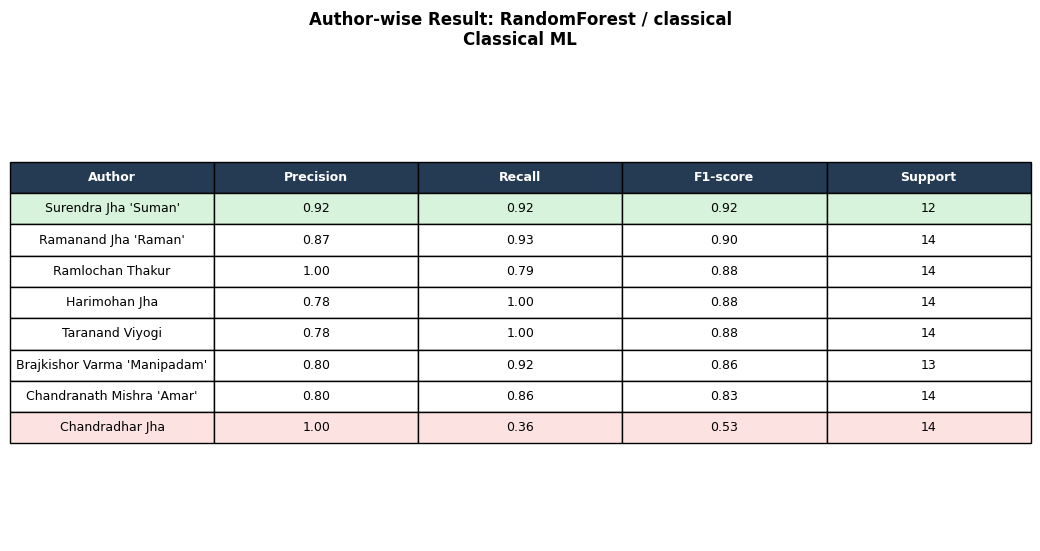

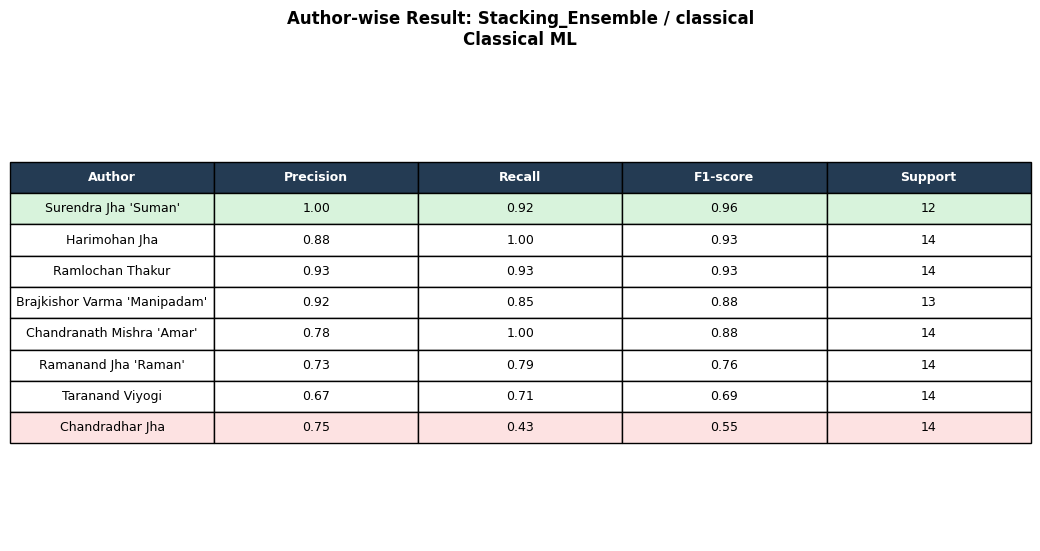

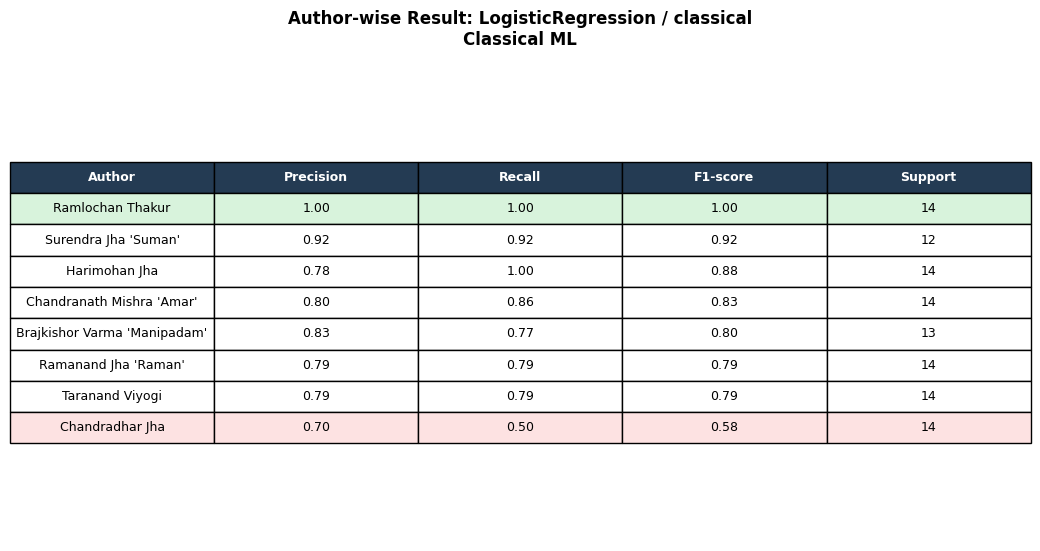

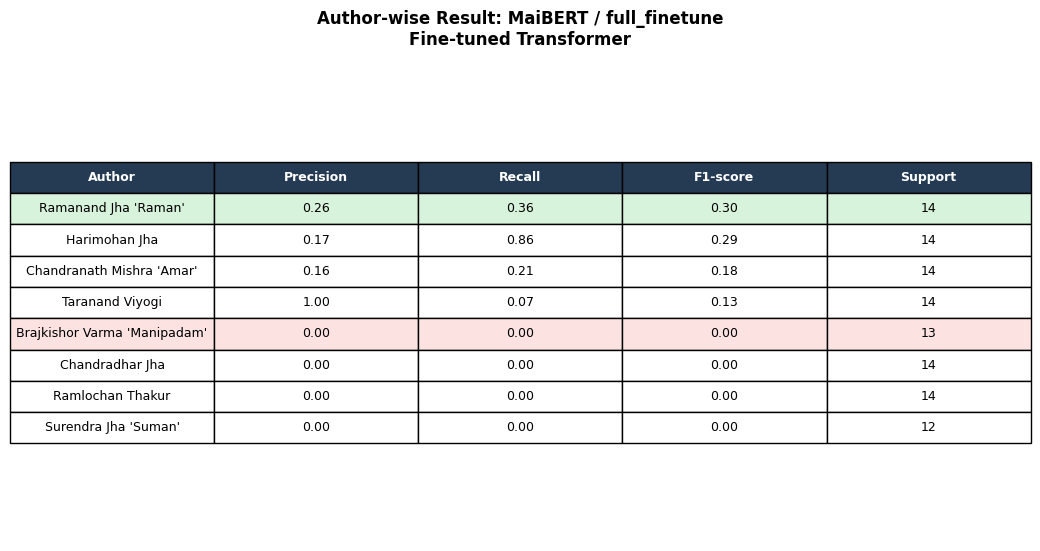

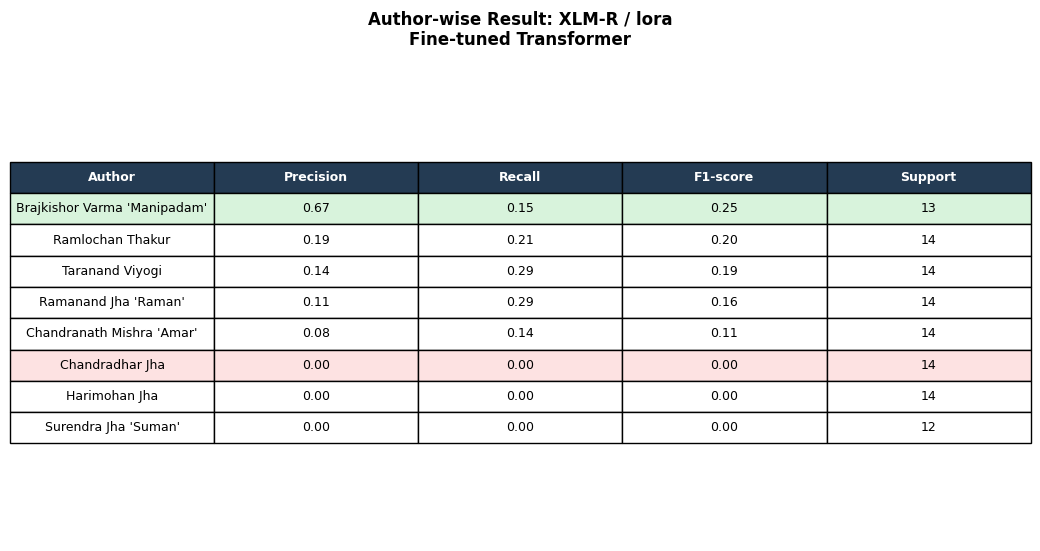

In [ ]:
# Tables use out-of-fold predictions only. The selected set is exactly 3 ML + 2
# DL when transformer results are available.
def author_metrics_table(y_true, y_pred, author_names, model, paradigm, variant):
    p, r, f, s = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(author_names))),
        average=None,
        zero_division=0,
    )
    return pd.DataFrame(
        {
            "Author": author_names,
            "Precision": p,
            "Recall": r,
            "F1": f,
            "Support": s.astype(int),
            "Model": model,
            "Paradigm": paradigm,
            "Variant": variant,
            "Run": f"{model} / {variant}",
        }
    )


combined_author_df = pd.concat(
    [
        author_metrics_table(
            y,
            r["y_pred"],
            author_names,
            r["model"],
            r["paradigm"],
            r.get("variant", ""),
        )
        for r in all_results
        if r.get("y_pred") is not None
    ],
    ignore_index=True,
)
ranked = sorted(
    all_results, key=lambda r: (r["f1_macro_mean"], r["accuracy_mean"]), reverse=True
)
top3_ml = [r for r in ranked if r["paradigm"] == "Classical ML"][:3]
top2_dl = [r for r in ranked if r["paradigm"] == "Fine-tuned Transformer"][:2]
top5_results = top3_ml + top2_dl
print("Top 5 per-author tables selected:")
for i, r in enumerate(top5_results, 1):
    print(
        f'  #{i} {r["paradigm"]:<24} {r["model"]:<14} {r.get("variant",""):<15} F1={r["f1_macro_mean"]:.3f}'
    )
for result in top5_results:
    model_df = (
        combined_author_df[
            (combined_author_df.Model == result["model"])
            & (combined_author_df.Paradigm == result["paradigm"])
            & (combined_author_df.Variant == result.get("variant", ""))
        ][["Author", "Precision", "Recall", "F1", "Support"]]
        .sort_values("F1", ascending=False)
        .reset_index(drop=True)
    )
    fig, ax = plt.subplots(figsize=(10.5, 0.55 * (len(model_df) + 2.2)))
    ax.axis("off")
    cols = ["Author", "Precision", "Recall", "F1-score", "Support"]
    data = [
        [
            row.Author,
            f"{row.Precision:.2f}",
            f"{row.Recall:.2f}",
            f"{row.F1:.2f}",
            int(row.Support),
        ]
        for _, row in model_df.iterrows()
    ]
    table = ax.table(cellText=data, colLabels=cols, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.25, 1.7)
    for j in range(len(cols)):
        table[0, j].set_facecolor("#243b53")
        table[0, j].set_text_props(color="white", fontweight="bold")
    weakest_idx = model_df.F1.idxmin()
    for row_idx, row in model_df.iterrows():
        color = (
            "#d8f3dc"
            if row_idx == 0
            else "#fde2e2" if row_idx == weakest_idx else "#ffffff"
        )
        for j in range(len(cols)):
            table[row_idx + 1, j].set_facecolor(color)
    ax.set_title(
        f'Author-wise Result: {result["model"]} / {result.get("variant","")}\n{result["paradigm"]}',
        fontweight="bold",
        fontsize=12,
        pad=14,
    )
    plt.tight_layout()
    plt.show()

### §10.10 Model Comparison, Confidence, and Weakest Author

These diagnostics turn the leaderboard into interpretation. The weakest author
uses the requested composite score `mean F1 - 1.0 * std`, so instability is
penalised rather than ignored.


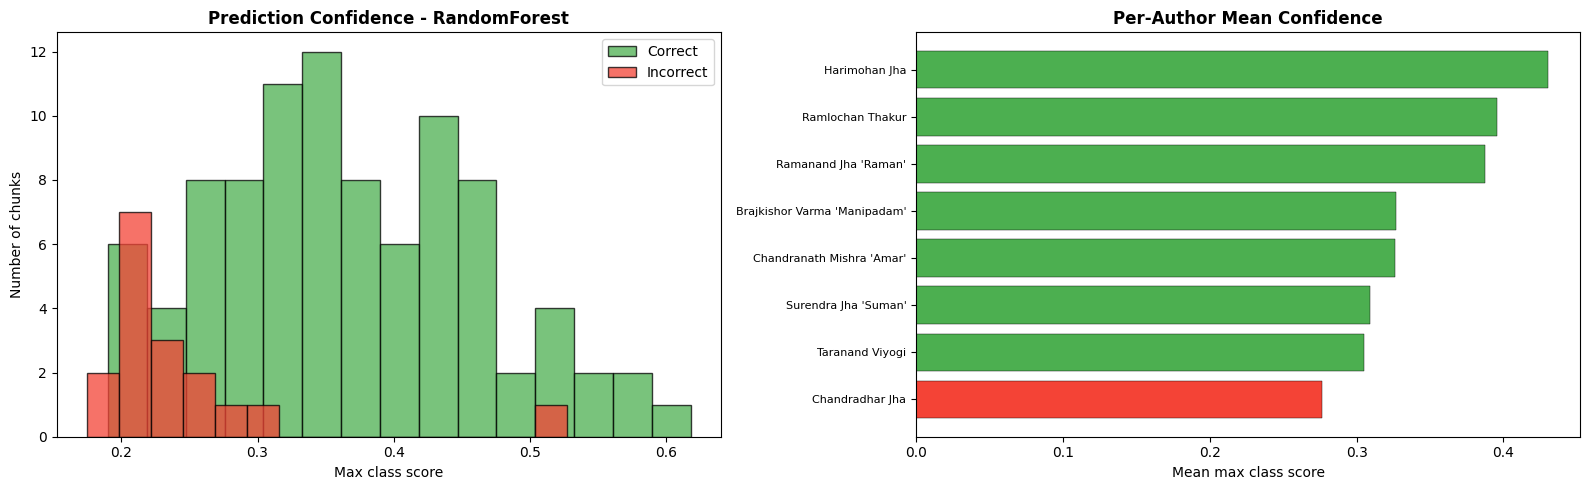

Confidence statistics:
  Correct predictions   : mean=0.364, median=0.356
  Incorrect predictions : mean=0.245, median=0.222

Per-author F1 matrix for selected top models
Author                                            Brajkishor Varma 'Manipadam'  Chandradhar Jha  Chandranath Mishra 'Amar'  Harimohan Jha  Ramanand Jha 'Raman'  Ramlochan Thakur  Surendra Jha 'Suman'  Taranand Viyogi
Run                                                                                                                                                                                                                     
Classical ML | LogisticRegression | classical                            0.800            0.583                      0.828          0.875                 0.786             1.000                 0.917            0.786
Classical ML | RandomForest | classical                                  0.857            0.526                      0.828          0.875                 0.897             0.880 

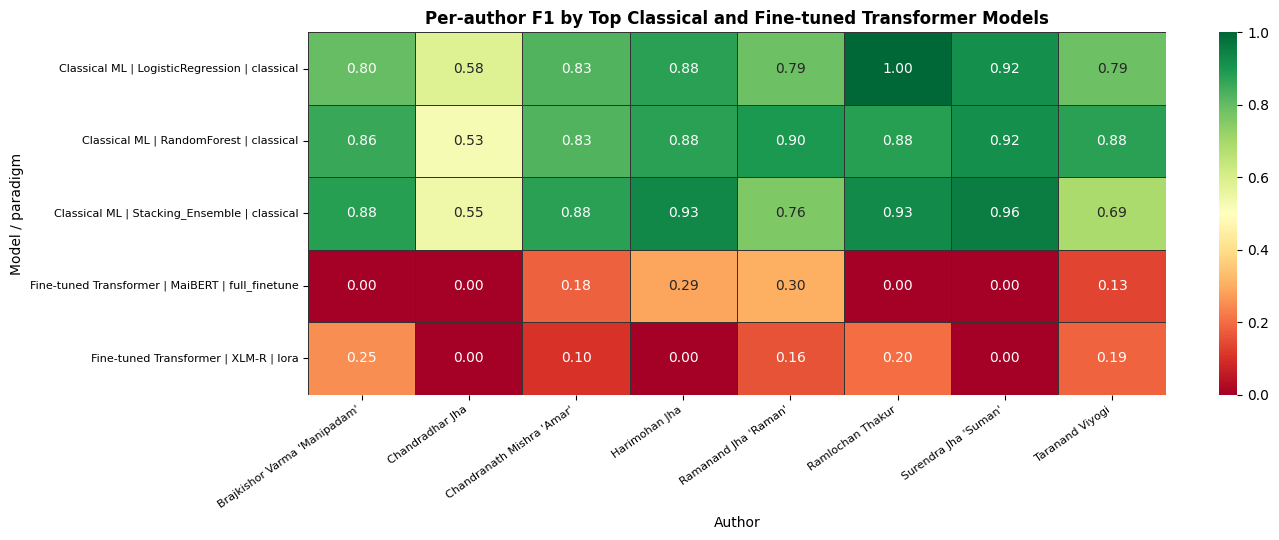


Best transformer vs best classical per-author F1 delta:
  Classical  : RandomForest
  Transformer: MaiBERT / full_finetune
  Brajkishor Varma 'Manipadam'                  delta=-0.857  classical higher
  Chandradhar Jha                               delta=-0.526  classical higher
  Chandranath Mishra 'Amar'                     delta=-0.646  classical higher
  Harimohan Jha                                 delta=-0.589  classical higher
  Ramanand Jha 'Raman'                          delta=-0.594  classical higher
  Ramlochan Thakur                              delta=-0.880  classical higher
  Surendra Jha 'Suman'                          delta=-0.917  classical higher
  Taranand Viyogi                               delta=-0.742  classical higher

WEAKEST-AUTHOR ANALYSIS - composite = mean F1 - 1.0 * std
  Author                                           Mean     Std     Min     Max  Composite
  Chandradhar Jha                                 0.331   0.303   0.000   0.583      0.028  <-

In [ ]:
# Confidence comes from held-out class scores; the heatmap is restricted to the
# top five model set to avoid duplicate visualisations.
if (
    best_classical.get("y_score") is not None
    and not np.isnan(best_classical["y_score"]).all()
):
    max_score = np.nanmax(best_classical["y_score"], axis=1)
    pred_score = np.nanargmax(best_classical["y_score"], axis=1)
    correct = pred_score == y
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].hist(
        max_score[correct],
        bins=15,
        alpha=0.75,
        label="Correct",
        color="#4CAF50",
        edgecolor="black",
        lw=0.3,
    )
    axes[0].hist(
        max_score[~correct],
        bins=15,
        alpha=0.75,
        label="Incorrect",
        color="#f44336",
        edgecolor="black",
        lw=0.3,
    )
    axes[0].set_xlabel("Max class score")
    axes[0].set_ylabel("Number of chunks")
    axes[0].set_title(
        f'Prediction Confidence - {best_classical["model"]}', fontweight="bold"
    )
    axes[0].legend()
    conf_df = pd.DataFrame(
        {
            "author": [chunk_authors[i] for i in range(len(y))],
            "confidence": max_score,
            "correct": correct,
        }
    )
    conf_sum = (
        conf_df.groupby("author")
        .agg(
            mean_confidence=("confidence", "mean"),
            accuracy=("correct", "mean"),
            n_chunks=("correct", "count"),
        )
        .sort_values("mean_confidence")
    )
    colors = [
        "#4CAF50" if a > 0.7 else "#FF9800" if a > 0.5 else "#f44336"
        for a in conf_sum.accuracy
    ]
    axes[1].barh(
        range(len(conf_sum)),
        conf_sum.mean_confidence,
        color=colors,
        edgecolor="black",
        lw=0.3,
    )
    axes[1].set_yticks(range(len(conf_sum)))
    axes[1].set_yticklabels(conf_sum.index, fontsize=8)
    axes[1].set_xlabel("Mean max class score")
    axes[1].set_title("Per-Author Mean Confidence", fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("Confidence statistics:")
    print(
        f"  Correct predictions   : mean={max_score[correct].mean():.3f}, median={np.median(max_score[correct]):.3f}"
    )
    print(
        f"  Incorrect predictions : mean={max_score[~correct].mean():.3f}, median={np.median(max_score[~correct]):.3f}"
    )

selected_frames = []
for result in top5_results:
    sub = combined_author_df[
        (combined_author_df.Model == result["model"])
        & (combined_author_df.Paradigm == result["paradigm"])
        & (combined_author_df.Variant == result.get("variant", ""))
    ].copy()
    sub["Run"] = (
        result["paradigm"] + " | " + result["model"] + " | " + result.get("variant", "")
    )
    selected_frames.append(sub)
per_author_df = pd.concat(selected_frames, ignore_index=True)
f1_pivot = per_author_df.pivot_table(index="Run", columns="Author", values="F1").round(
    3
)
print()
print("Per-author F1 matrix for selected top models")
print("=" * 100)
print(f1_pivot.to_string())
fig, ax = plt.subplots(figsize=(14, max(5.5, len(f1_pivot) * 0.55)))
sns.heatmap(
    f1_pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="#333",
    ax=ax,
)
ax.set_title(
    "Per-author F1 by Top Classical and Fine-tuned Transformer Models",
    fontweight="bold",
)
ax.set_xlabel("Author")
ax.set_ylabel("Model / paradigm")
plt.xticks(rotation=35, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

if any(r["paradigm"] == "Fine-tuned Transformer" for r in all_results):
    best_transformer = best_result("Fine-tuned Transformer")
    _, _, fc, _ = precision_recall_fscore_support(
        y, best_classical["y_pred"], labels=list(range(n_classes)), zero_division=0
    )
    _, _, ft, _ = precision_recall_fscore_support(
        y, best_transformer["y_pred"], labels=list(range(n_classes)), zero_division=0
    )
    print()
    print("Best transformer vs best classical per-author F1 delta:")
    print(f'  Classical  : {best_classical["model"]}')
    print(
        f'  Transformer: {best_transformer["model"]} / {best_transformer.get("variant","")}'
    )
    for i, a in enumerate(author_names):
        delta = ft[i] - fc[i]
        label = (
            "transformer higher"
            if delta > 0.05
            else "classical higher" if delta < -0.05 else "similar"
        )
        print(f"  {a:<45} delta={delta:+.3f}  {label}")

weakness_df = (
    per_author_df.groupby("Author")["F1"].agg(["mean", "min", "max", "std"]).fillna(0.0)
)
weakness_df["composite_score"] = weakness_df["mean"] - 1.0 * weakness_df["std"]
weakness_df = weakness_df.sort_values("composite_score")
weakest_author = weakness_df.index[0]
weakest_stats = weakness_df.loc[weakest_author]
print()
print("" + "=" * 90)
print("WEAKEST-AUTHOR ANALYSIS - composite = mean F1 - 1.0 * std")
print("=" * 90)
print(
    f'  {"Author":<45} {"Mean":>7} {"Std":>7} {"Min":>7} {"Max":>7} {"Composite":>10}'
)
for a, row in weakness_df.iterrows():
    mark = "  <- selected" if a == weakest_author else ""
    print(
        f'  {a:<45} {row["mean"]:>7.3f} {row["std"]:>7.3f} {row["min"]:>7.3f} {row["max"]:>7.3f} {row["composite_score"]:>10.3f}{mark}'
    )
print()
print(
    f'Weakest author: {weakest_author} | mean={weakest_stats["mean"]:.3f}, std={weakest_stats["std"]:.3f}, composite={weakest_stats["composite_score"]:.3f}'
)

drift_row = drift_df[drift_df.author == weakest_author]
if len(drift_row):
    drift_val = float(drift_row.drift_magnitude.values[0])
    corpus_mean = float(drift_df.drift_magnitude.mean())
    ranked = drift_df.sort_values("drift_magnitude", ascending=False).reset_index(
        drop=True
    )
    rank = int(ranked[ranked.author == weakest_author].index[0]) + 1
    print()
    print("Stylometric-semantic drift context:")
    print(f"  {weakest_author:<45} drift={drift_val:.4f}")
    print(f"  Corpus mean drift                              drift={corpus_mean:.4f}")
    print(f"  Drift rank: #{rank} of {len(drift_df)}")
best_overall = best_result()
cm_full = confusion_matrix(y, best_overall["y_pred"])
idx = list(author_names).index(weakest_author)
row = cm_full[idx].copy()
row[idx] = 0
total = row.sum()
print()
print(
    f'Confusion profile using best overall model ({best_overall["model"]} / {best_overall.get("variant","")}):'
)
print(f"  Total misclassified chunks: {total}")
for i in np.argsort(row)[::-1]:
    if row[i] > 0:
        print(
            f"  Mistaken for {author_names[i]:<40} {row[i]:>2} chunk(s) ({row[i]/max(1,total):.0%})"
        )
pop_mean = author_profiles.mean()
pop_std = author_profiles.std()
profile = author_profiles.loc[weakest_author]
z = ((profile - pop_mean) / (pop_std + 1e-9)).abs().sort_values(ascending=False)
print()
print("Top 5 distinctive features:")
for feat in z.head(5).index:
    print(
        f"  {feat:<38} val={profile[feat]:.4f} corpus_mean={pop_mean[feat]:.4f} z={z[feat]:.2f}"
    )
pol_cols = [c for c in feature_df.columns if c.endswith("_polarity")]
idxs = [i for i, a in enumerate(chunk_authors) if a == weakest_author]
pol = feature_df.iloc[idxs][pol_cols].mean()
print()
print("Ideological polarity profile:")
for col, val in pol.items():
    stance = (
        "progressive" if val > 0.05 else ("traditional" if val < -0.05 else "neutral")
    )
    print(f'  {col.replace("_polarity",""):<28} {val:+.4f} ({stance})')

### §10.11 ROC-AUC Curves (Classical ML Models)

Macro-averaged one-vs-rest ROC curves for every classical model that produces probability estimates. The diagonal represents a random classifier; the further a curve bends toward the top-left corner, the better the model discriminates among the eight Maithili authors.

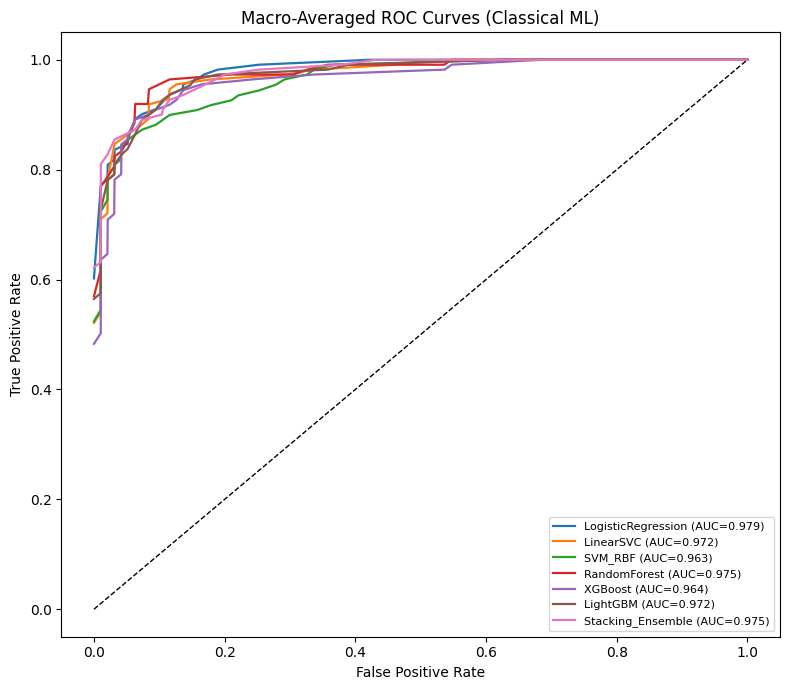

In [ ]:
# §10.11 ROC-AUC Curves
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_bin = label_binarize(y, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(8, 7))
plotted = 0

for res in classical_results:
    if res.get('y_score') is None:
        continue
    fpr_all, tpr_all = {}, {}
    for i in range(n_classes):
        fpr_all[i], tpr_all[i], _ = roc_curve(y_bin[:, i], res['y_score'][:, i])
    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr_all[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_all[i], tpr_all[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, lw=1.6,
            label=f"{res['model']} (AUC={macro_auc:.3f})")
    plotted += 1

if plotted == 0:
    print("No classical model with probability scores found; skipping ROC curves.")
else:
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Macro-Averaged ROC Curves (Classical ML)')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

### §10.12 Model Performance Comparison (Grouped Bar Chart)

Side-by-side comparison of every model across Accuracy, F1 Macro, and ROC AUC. This complements the per-author F1 heatmap by showing overall model strength at a glance.

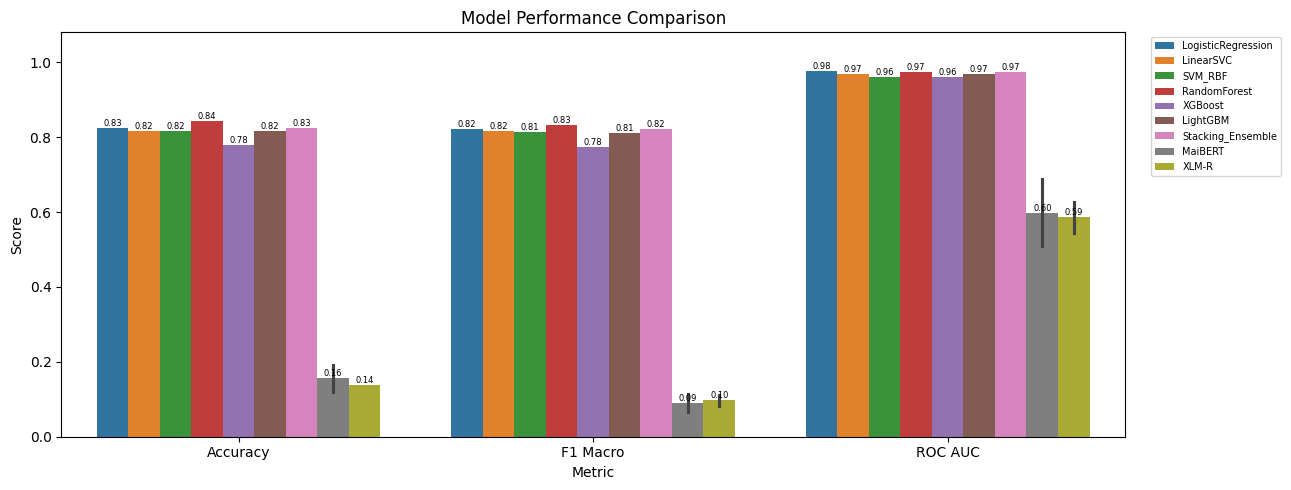

In [ ]:
# §10.12 Model Performance Grouped Bar Chart
metrics_cols = ['accuracy', 'f1_macro', 'roc_auc']
metric_labels = ['Accuracy', 'F1 Macro', 'ROC AUC']

comp_rows = []
for res in all_results:
    for mc, ml in zip(metrics_cols, metric_labels):
        comp_rows.append({
            'Model': res['model'],
            'Paradigm': res['paradigm'],
            'Metric': ml,
            'Score': res[mc],
        })
comp_df = pd.DataFrame(comp_rows)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=comp_df, x='Metric', y='Score', hue='Model', ax=ax, palette='tab10')
ax.set_ylim(0, 1.08)
ax.set_title('Model Performance Comparison')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
for p in ax.patches:
    h = p.get_height()
    if h > 0.01:
        ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=6)
plt.tight_layout()
plt.show()

### §10.13 Feature Ablation Impact

Shows the accuracy drop when each feature family is removed (Leave-One-Family-Out). Taller bars indicate more critical feature families — directly supporting the argument for the 10-family hand-engineered feature design.

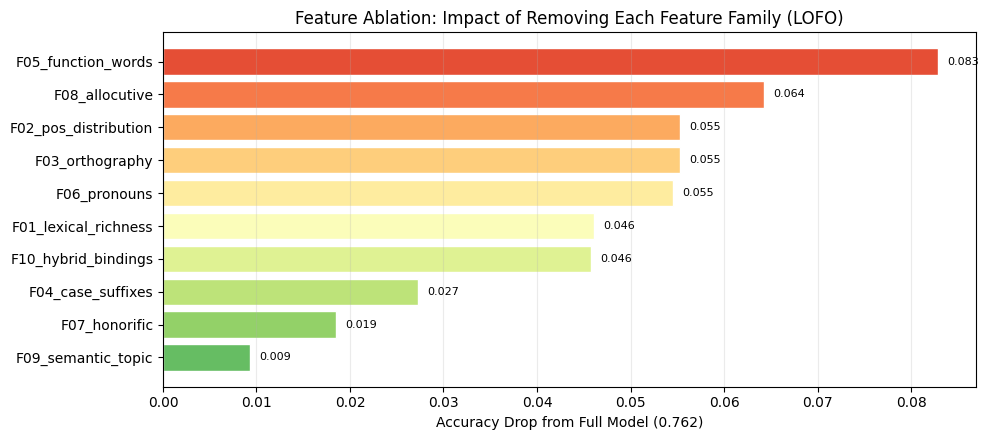

In [ ]:
# §10.13 Feature Ablation Impact Bar Chart
if 'ablation_df' in globals() and not ablation_df.empty:
    lofo = ablation_df[ablation_df['condition'] == 'LOFO'].copy()
    lofo['delta'] = full_acc - lofo['accuracy']
    lofo = lofo.sort_values('delta', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, len(lofo) * 0.45)))
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.85, len(lofo)))
    bars = ax.barh(lofo['family'], lofo['delta'], color=colors, edgecolor='white')
    ax.set_xlabel(f'Accuracy Drop from Full Model ({full_acc:.3f})')
    ax.set_title('Feature Ablation: Impact of Removing Each Feature Family (LOFO)')
    for i, val in enumerate(lofo['delta']):
        ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("ablation_df not found — run the ablation study cell first.")

---
## §11 Directional Influence Network

The influence graph distinguishes two relation types:
- **Generational** (older → younger, gap > 5 years): a directed edge.
- **Contemporary** (|gap| ≤ 5 years): a bidirectional pair.

Two safeguards reduce spurious edges:
1. **Median-based threshold** keeps only above-median similarity pairs.
2. **Bootstrap p-value gate** drops pairs whose mean similarity is not
   significantly > 0 at p < 0.05.

Birth years for two authors (Chandradhar Jha, Ramanand Jha) are
**approximate** and visualised with a dashed border in the graph.


### §11.1 Bootstrap edge-significance test

This network step turns pairwise similarity into a guarded influence claim. The separation makes statistical filtering visible.


In [ ]:
def bootstrap_edge_pvalue(sim_matrix, idx_a, idx_b, n_boot=N_BOOTSTRAP):
    """P-value testing H0: mean pairwise similarity <= 0.

    A small p-value means the observed positive similarity is unlikely under
    the null hypothesis of no real connection. Edges with p > 0.05 are
    pruned to reduce spurious links from the small sample size.
    """
    obs = sim_matrix[np.ix_(idx_a, idx_b)].flatten()
    rng = default_rng(SEED)
    boot = [rng.choice(obs, size=len(obs), replace=True).mean() for _ in range(n_boot)]
    # Fraction of bootstrap means at or below 0 = p-value for the
    # one-sided test mean > 0.
    return float(np.mean(np.array(boot) <= 0))


print("Bootstrap edge-significance test ready.")

Bootstrap edge-significance test ready.


### §11.2 Build directed influence graph

This network step turns pairwise similarity into a guarded influence claim. The separation makes statistical filtering visible.


In [ ]:
G = nx.DiGraph()
for a in authors_list:
    G.add_node(
        a,
        birth_year=AUTHOR_BIRTH_YEARS.get(a, 1940),
        confidence=BIRTH_YEAR_CONFIDENCE.get(a, "approximate"),
        first_pub=FIRST_PUBLICATION.get(a),
    )

# Threshold = median of upper-triangle similarity values.
upper_vals = author_sim.values[np.triu_indices_from(author_sim, k=1)]
threshold = np.median(upper_vals)
SAME_GEN_WINDOW = 5

print(f"Edge similarity threshold : {threshold:.3f}")
print(f"P-value cutoff            : {PVALUE_CUTOFF}")
print(f"Same-generation window    : ±{SAME_GEN_WINDOW} years\n")

pruned_count = 0
for i, a in enumerate(authors_list):
    for j, b in enumerate(authors_list):
        if i >= j:
            continue

        sim_score = float(author_sim.iloc[i, j])
        if sim_score <= threshold:
            continue  # below similarity threshold — skip

        # Significance gate: drop the edge if its mean is not
        # statistically distinguishable from zero.
        p_val = bootstrap_edge_pvalue(sim_matrix, idx_map[a], idx_map[b])
        if p_val > PVALUE_CUTOFF:
            pruned_count += 1
            continue

        birth_a = AUTHOR_BIRTH_YEARS[a]
        birth_b = AUTHOR_BIRTH_YEARS[b]
        gap = birth_a - birth_b

        if abs(gap) <= SAME_GEN_WINDOW:
            # Contemporaries: bidirectional edge.
            G.add_edge(a, b, weight=sim_score, relation="contemporary", pvalue=p_val)
            G.add_edge(b, a, weight=sim_score, relation="contemporary", pvalue=p_val)
        elif gap > SAME_GEN_WINDOW:
            # b is older -> directed edge older to younger.
            G.add_edge(b, a, weight=sim_score, relation="generational", pvalue=p_val)
        else:
            G.add_edge(a, b, weight=sim_score, relation="generational", pvalue=p_val)

print(f"Edges pruned by bootstrap test : {pruned_count}")
print(
    f"Final network                  : {G.number_of_nodes()} nodes, "
    f"{G.number_of_edges()} edges\n"
)

# Report generational influences ranked by similarity.
print("Generational edges (older -> younger):")
for u, v, d in sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True):
    if d.get("relation") == "generational":
        by_u = AUTHOR_BIRTH_YEARS[u]
        by_v = AUTHOR_BIRTH_YEARS[v]
        cu = "~" if BIRTH_YEAR_CONFIDENCE[u] == "approximate" else ""
        cv = "~" if BIRTH_YEAR_CONFIDENCE[v] == "approximate" else ""
        print(
            f"  {u[:30]:<30} ({cu}{by_u}) -> {v[:30]:<30} ({cv}{by_v})  "
            f'sim={d["weight"]:.3f}  p={d["pvalue"]:.3f}'
        )

print("\nContemporary pairs:")
seen = set()
for u, v, d in G.edges(data=True):
    if d.get("relation") == "contemporary":
        pair = tuple(sorted([u, v]))
        if pair in seen:
            continue
        seen.add(pair)
        print(
            f"  {u[:30]:<30} ({AUTHOR_BIRTH_YEARS[u]}) <-> "
            f"{v[:30]:<30} ({AUTHOR_BIRTH_YEARS[v]})  "
            f'sim={d["weight"]:.3f}  p={d["pvalue"]:.3f}'
        )

# Out-degree = number of authors this author influenced.
print("\nMost influential authors (out-degree):")
for author, deg in sorted(G.out_degree(), key=lambda x: x[1], reverse=True):
    if deg > 0:
        c = "~" if BIRTH_YEAR_CONFIDENCE[author] == "approximate" else ""
        print(f"  {author:<45} -> {deg} (born {c}{AUTHOR_BIRTH_YEARS[author]})")

Edge similarity threshold : 0.509
P-value cutoff            : 0.05
Same-generation window    : ±5 years

Edges pruned by bootstrap test : 10
Final network                  : 8 nodes, 4 edges

Generational edges (older -> younger):
  Surendra Jha 'Suman'           (1910) -> Chandranath Mishra 'Amar'      (1925)  sim=0.982  p=0.000
  Surendra Jha 'Suman'           (1910) -> Ramanand Jha 'Raman'           (~1930)  sim=0.955  p=0.000
  Harimohan Jha                  (1908) -> Chandradhar Jha                (~1920)  sim=0.920  p=0.004
  Ramanand Jha 'Raman'           (~1930) -> Ramlochan Thakur               (1949)  sim=0.875  p=0.001

Contemporary pairs:

Most influential authors (out-degree):
  Surendra Jha 'Suman'                          -> 2 (born 1910)
  Harimohan Jha                                 -> 1 (born 1908)
  Ramanand Jha 'Raman'                          -> 1 (born ~1930)


### §11.3 Multiple comparisons correction *(statistical hardening)*

The bootstrap p-values in §11.3 are computed and thresholded **independently**
for every author pair. With 8 authors that's 28 simultaneous hypothesis tests,
so under the null (no real edges), we expect ≈ 28 × 0.05 ≈ 1.4 spurious
edges to slip through at α = 0.05.

We re-evaluate the network under two correction regimes:

- **Bonferroni**: divide α by the number of tests. Conservative — high
  specificity, low sensitivity.
- **Benjamini–Hochberg FDR (5%)**: control the *expected proportion* of
  false discoveries among the rejected nulls. Less conservative, generally
  higher power for small N.

We report which edges survive each correction so the reader can see the
trade-off explicitly. The original uncorrected graph remains in §11.3 for
exploratory inspection; for any **claim** about influence, the
FDR-corrected (or Bonferroni-corrected) sub-network is the defensible one.

In [ ]:
def benjamini_hochberg(pvals, alpha=0.05):
    """Return boolean array indicating which p-values pass BH-FDR control.

    The BH procedure sorts p-values ascending, finds the largest k such that
    p_(k) <= (k/n) * alpha, and rejects all hypotheses with rank <= k.
    """
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    if n == 0:
        return np.array([], dtype=bool)
    order = np.argsort(pvals)
    ranked = pvals[order]
    # Threshold for each ranked p-value.
    thresholds = (np.arange(1, n + 1) / n) * alpha
    passes = ranked <= thresholds
    if not passes.any():
        cutoff_rank = -1
    else:
        # Largest rank that passes — and everything below it also passes.
        cutoff_rank = np.max(np.where(passes)[0])
    accept = np.zeros(n, dtype=bool)
    if cutoff_rank >= 0:
        accept[order[: cutoff_rank + 1]] = True
    return accept


# Recollect every candidate edge that cleared the similarity threshold,
# along with its bootstrap p-value. We re-do the same test as §11.3 to
# recover the full vector of p-values (we don't store them on G uniformly).
candidate_edges = []
for i, a in enumerate(authors_list):
    for j, b in enumerate(authors_list):
        if i >= j:
            continue
        sim_score = float(author_sim.iloc[i, j])
        if sim_score <= threshold:
            continue
        p_val = bootstrap_edge_pvalue(sim_matrix, idx_map[a], idx_map[b])
        candidate_edges.append(
            {
                "a": a,
                "b": b,
                "sim": sim_score,
                "pvalue": p_val,
                "gap": AUTHOR_BIRTH_YEARS[a] - AUTHOR_BIRTH_YEARS[b],
            }
        )

cand_df = pd.DataFrame(candidate_edges)

# Apply both corrections.
n_tests = len(cand_df)
alpha = 0.05
bonf_threshold = alpha / max(1, n_tests)
cand_df["pass_uncorrected"] = cand_df["pvalue"] < alpha
cand_df["pass_bonferroni"] = cand_df["pvalue"] < bonf_threshold
cand_df["pass_bh_fdr"] = benjamini_hochberg(cand_df["pvalue"].values, alpha=alpha)

print("=" * 90)
print(f"MULTIPLE COMPARISONS CORRECTION — {n_tests} candidate edges, alpha = {alpha}")
print("=" * 90)
print(f"  Uncorrected threshold     : p < {alpha}")
print(f"  Bonferroni threshold      : p < {bonf_threshold:.5f}  (alpha / {n_tests})")
print(f"  Benjamini–Hochberg FDR    : adaptive per-rank (5% expected FDR)")
print()
print(cand_df.round(4).to_string(index=False))
print()
print(f'  Edges passing uncorrected   : {int(cand_df["pass_uncorrected"].sum()):>2}')
print(f'  Edges passing Bonferroni    : {int(cand_df["pass_bonferroni"].sum()):>2}')
print(f'  Edges passing BH-FDR (q=5%) : {int(cand_df["pass_bh_fdr"].sum()):>2}')

MULTIPLE COMPARISONS CORRECTION — 14 candidate edges, alpha = 0.05
  Uncorrected threshold     : p < 0.05
  Bonferroni threshold      : p < 0.00357  (alpha / 14)
  Benjamini–Hochberg FDR    : adaptive per-rank (5% expected FDR)

                           a                         b    sim  pvalue  gap  pass_uncorrected  pass_bonferroni  pass_bh_fdr
Brajkishor Varma 'Manipadam'           Chandradhar Jha 0.5625   0.918   -2             False            False        False
Brajkishor Varma 'Manipadam' Chandranath Mishra 'Amar' 0.6964   0.793   -7             False            False        False
Brajkishor Varma 'Manipadam'          Ramlochan Thakur 0.7321   0.634  -31             False            False        False
Brajkishor Varma 'Manipadam'      Surendra Jha 'Suman' 0.6786   0.781    8             False            False        False
             Chandradhar Jha Chandranath Mishra 'Amar' 0.7768   0.598   -5             False            False        False
             Chandradhar Jha     

### §11.4 Corrected influence sub-networks

Build two stricter graphs (`G_bonf`, `G_fdr`) using the corrected edge sets,
keeping the same generational/contemporary classification logic as §11.3.
A side-by-side rendering shows how aggressive each correction is.

Network sizes after correction:
  Uncorrected (§11.3) : 8 nodes, 4 edges
  Bonferroni          : 8 nodes, 3 edges
  BH-FDR (q=5%)       : 8 nodes, 4 edges


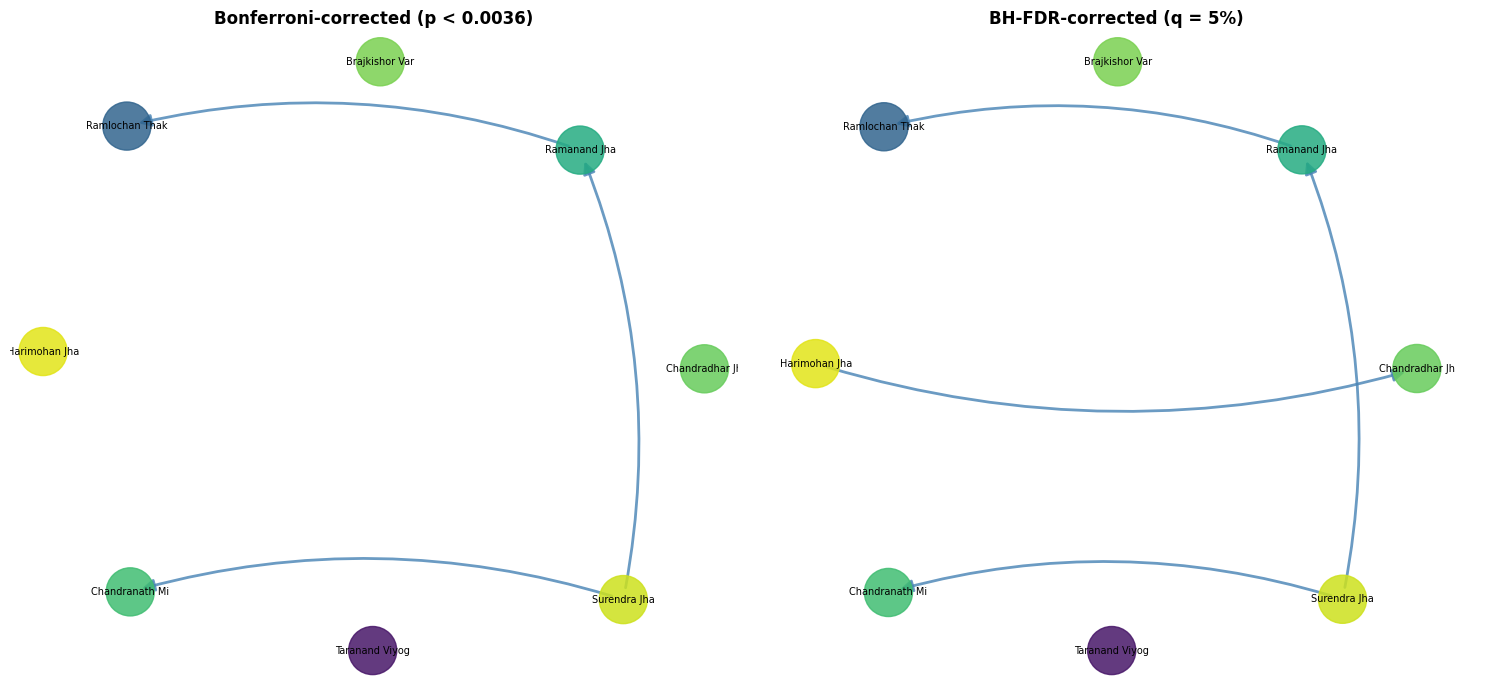


Generational edges surviving BH-FDR correction:
  Surendra Jha 'Suman'           -> Chandranath Mishra 'Amar'       sim=0.982  p=0.0000
  Surendra Jha 'Suman'           -> Ramanand Jha 'Raman'            sim=0.955  p=0.0000
  Harimohan Jha                  -> Chandradhar Jha                 sim=0.920  p=0.0040
  Ramanand Jha 'Raman'           -> Ramlochan Thakur                sim=0.875  p=0.0010


In [ ]:
def build_corrected_graph(cand_df, pass_col, same_gen_window=SAME_GEN_WINDOW):
    """Construct a directed graph using only edges that pass the given correction."""
    G_corr = nx.DiGraph()
    for a in authors_list:
        G_corr.add_node(
            a,
            birth_year=AUTHOR_BIRTH_YEARS.get(a, 1940),
            confidence=BIRTH_YEAR_CONFIDENCE.get(a, "approximate"),
        )

    for _, row in cand_df.iterrows():
        if not row[pass_col]:
            continue
        a, b, sim_score, p_val, gap = (
            row["a"],
            row["b"],
            row["sim"],
            row["pvalue"],
            row["gap"],
        )
        if abs(gap) <= same_gen_window:
            G_corr.add_edge(
                a, b, weight=sim_score, relation="contemporary", pvalue=p_val
            )
            G_corr.add_edge(
                b, a, weight=sim_score, relation="contemporary", pvalue=p_val
            )
        elif gap > same_gen_window:
            G_corr.add_edge(
                b, a, weight=sim_score, relation="generational", pvalue=p_val
            )
        else:
            G_corr.add_edge(
                a, b, weight=sim_score, relation="generational", pvalue=p_val
            )
    return G_corr


G_bonf = build_corrected_graph(cand_df, "pass_bonferroni")
G_fdr = build_corrected_graph(cand_df, "pass_bh_fdr")

print("Network sizes after correction:")
print(
    f"  Uncorrected (§11.3) : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges"
)
print(
    f"  Bonferroni          : {G_bonf.number_of_nodes()} nodes, {G_bonf.number_of_edges()} edges"
)
print(
    f"  BH-FDR (q=5%)       : {G_fdr.number_of_nodes()} nodes, {G_fdr.number_of_edges()} edges"
)


def render_graph(G_in, title, ax):
    """Light-weight reuse of the §12.5 layout for the corrected graphs."""
    if G_in.number_of_edges() == 0:
        ax.text(
            0.5,
            0.5,
            "No edges survive correction",
            ha="center",
            va="center",
            fontsize=14,
            transform=ax.transAxes,
        )
        ax.set_title(title, fontweight="bold")
        ax.set_axis_off()
        return
    pos_corr = nx.spring_layout(G_in, k=2.5, seed=SEED)
    birth_years = [AUTHOR_BIRTH_YEARS.get(n, 1940) for n in G_in.nodes()]
    node_colors = plt.cm.viridis_r([(yr - 1905) / 65 for yr in birth_years])
    nx.draw_networkx_nodes(
        G_in, pos_corr, node_size=1200, node_color=node_colors, alpha=0.85, ax=ax
    )
    short_labels = {n: n.split(chr(39))[0].strip()[:14] for n in G_in.nodes()}
    nx.draw_networkx_labels(G_in, pos_corr, labels=short_labels, font_size=7, ax=ax)
    gen_e = [
        (u, v)
        for u, v, d in G_in.edges(data=True)
        if d.get("relation") == "generational"
    ]
    cont_e = [
        (u, v)
        for u, v, d in G_in.edges(data=True)
        if d.get("relation") == "contemporary"
    ]
    nx.draw_networkx_edges(
        G_in,
        pos_corr,
        edgelist=gen_e,
        width=2,
        alpha=0.8,
        edge_color="steelblue",
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        connectionstyle="arc3,rad=0.15",
        ax=ax,
    )
    nx.draw_networkx_edges(
        G_in,
        pos_corr,
        edgelist=cont_e,
        width=1.2,
        alpha=0.5,
        edge_color="orange",
        arrows=True,
        arrowstyle="-|>",
        arrowsize=12,
        connectionstyle="arc3,rad=0.15",
        ax=ax,
    )
    ax.set_title(title, fontweight="bold")
    ax.set_axis_off()


fig, axes = plt.subplots(1, 2, figsize=(15, 7))
render_graph(G_bonf, f"Bonferroni-corrected (p < {bonf_threshold:.4f})", axes[0])
render_graph(G_fdr, f"BH-FDR-corrected (q = 5%)", axes[1])
plt.tight_layout()
plt.show()

# Surviving generational edges = the project's defensible influence claims.
print("\nGenerational edges surviving BH-FDR correction:")
fdr_gen = [
    (u, v, d)
    for u, v, d in G_fdr.edges(data=True)
    if d.get("relation") == "generational"
]
if not fdr_gen:
    print("  (none — sample size limits statistical power)")
else:
    for u, v, d in sorted(fdr_gen, key=lambda x: x[2]["weight"], reverse=True):
        print(
            f"  {u[:30]:<30} -> {v[:30]:<30}  "
            f'sim={d["weight"]:.3f}  p={d["pvalue"]:.4f}'
        )

---
## §12 Diagnostic Visualisations

Five figures that summarise the analysis: style heatmap, semantic heatmap,
hierarchical clustering dendrogram, ideological-space scatter, and the
directional influence network.


### §12.1 Style similarity heatmap

This visualisation is retained because it adds interpretive value. It gives readers a compact view of a relationship that is hard to inspect from tables alone.


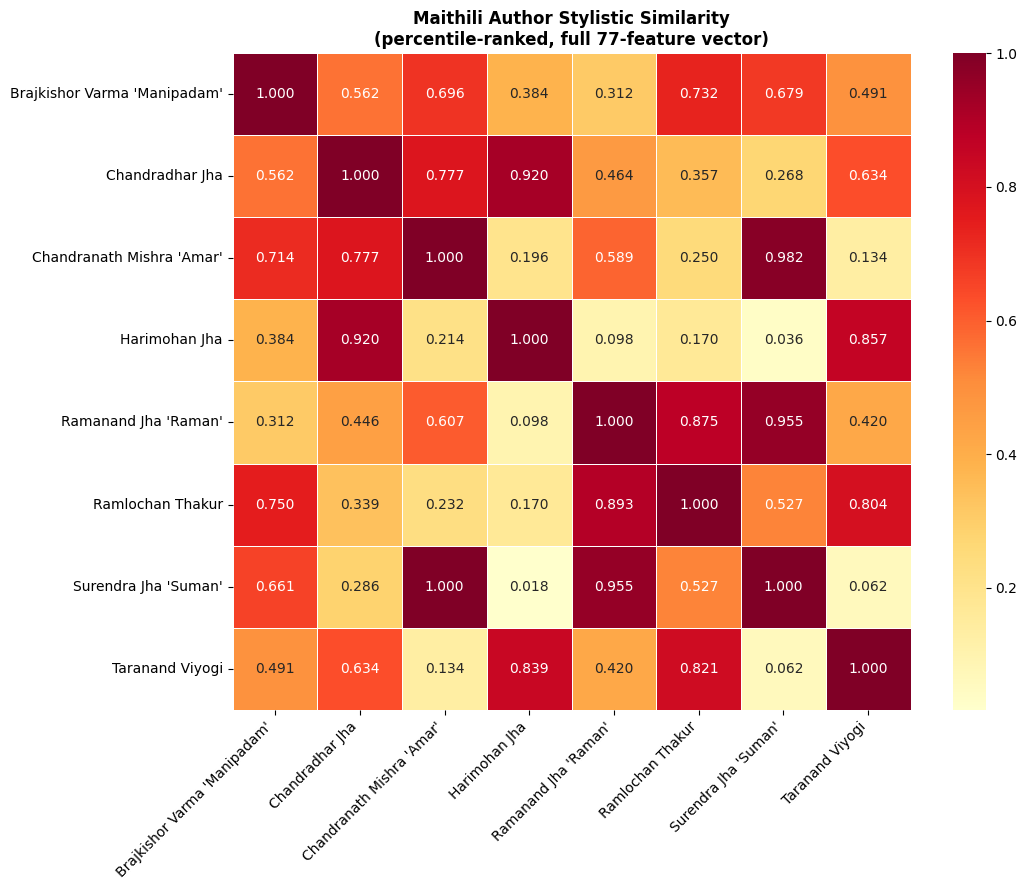

In [ ]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    author_sim,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    vmin=author_sim.values[mask].min(),
    vmax=author_sim.values[mask].max(),
)
ax.set_title(
    "Maithili Author Stylistic Similarity\n"
    "(percentile-ranked, full 77-feature vector)",
    fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### §12.2 Semantic-only similarity heatmap

This visualisation is retained because it adds interpretive value. It gives readers a compact view of a relationship that is hard to inspect from tables alone.


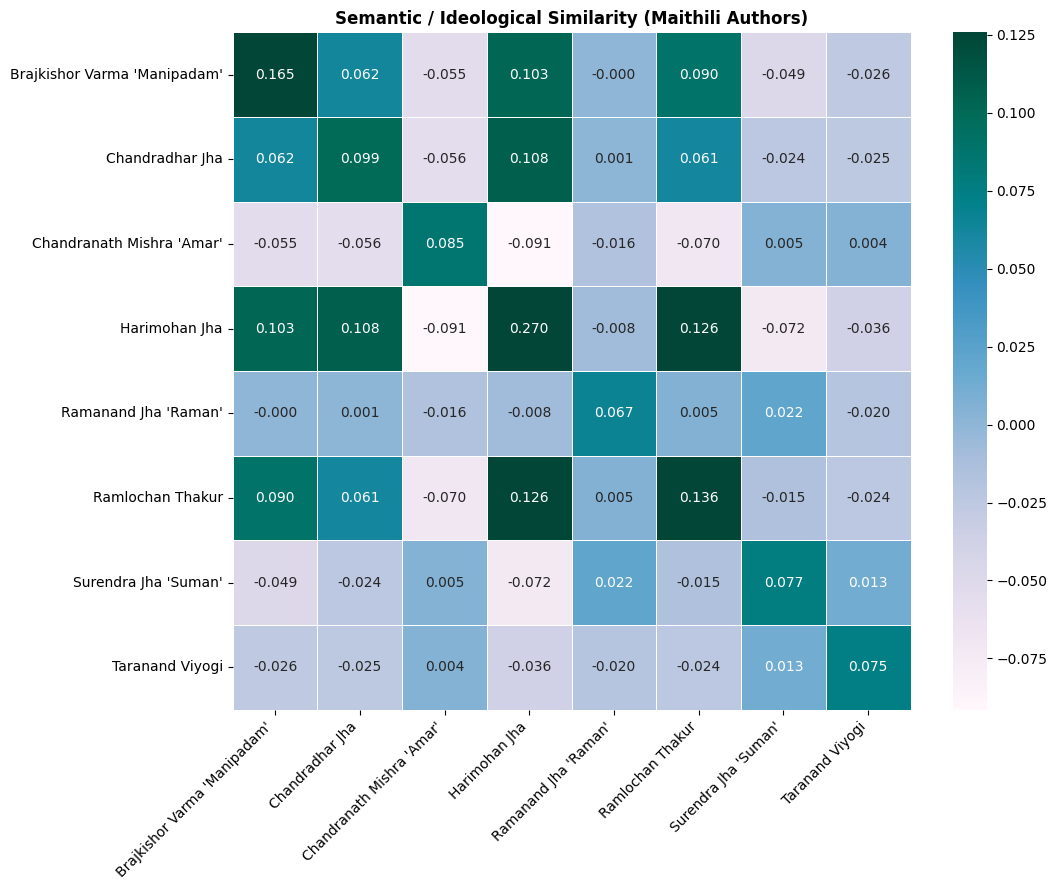

In [ ]:
mask_sem = ~np.eye(len(authors_list), dtype=bool)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    author_sem_sim,
    annot=True,
    fmt=".3f",
    cmap="PuBuGn",
    linewidths=0.5,
    ax=ax,
    vmin=author_sem_sim.values[mask_sem].min(),
    vmax=author_sem_sim.values[mask_sem].max(),
)
ax.set_title("Semantic / Ideological Similarity (Maithili Authors)", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### §12.3 Hierarchical clustering dendrogram

This visualisation is retained because it adds interpretive value. It gives readers a compact view of a relationship that is hard to inspect from tables alone.


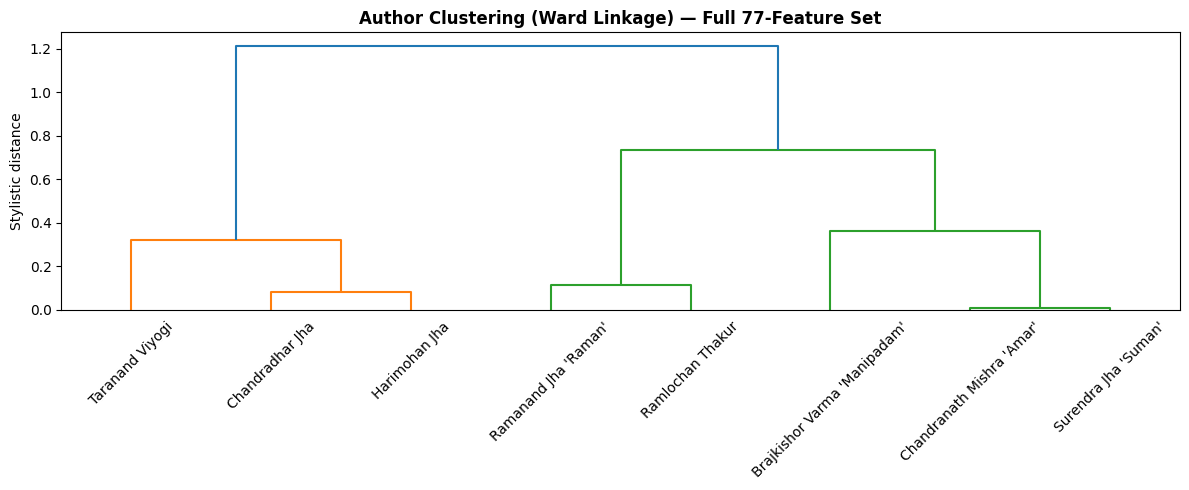

In [ ]:
# Convert similarity to distance for Ward linkage.
dist = 1 - author_sim.values
np.fill_diagonal(dist, 0)
# Symmetrise — small floating-point asymmetries from the percentile rescale
# would otherwise crash squareform.
dist = (dist + dist.T) / 2
condensed = squareform(dist)
Z = linkage(condensed, method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=authors_list, ax=ax, leaf_rotation=45, leaf_font_size=10)
ax.set_title(
    "Author Clustering (Ward Linkage) — Full 77-Feature Set", fontweight="bold"
)
ax.set_ylabel("Stylistic distance")
plt.tight_layout()
plt.show()

### §12.4 Ideological-space scatter plot

This visualisation is retained because it adds interpretive value. It gives readers a compact view of a relationship that is hard to inspect from tables alone.


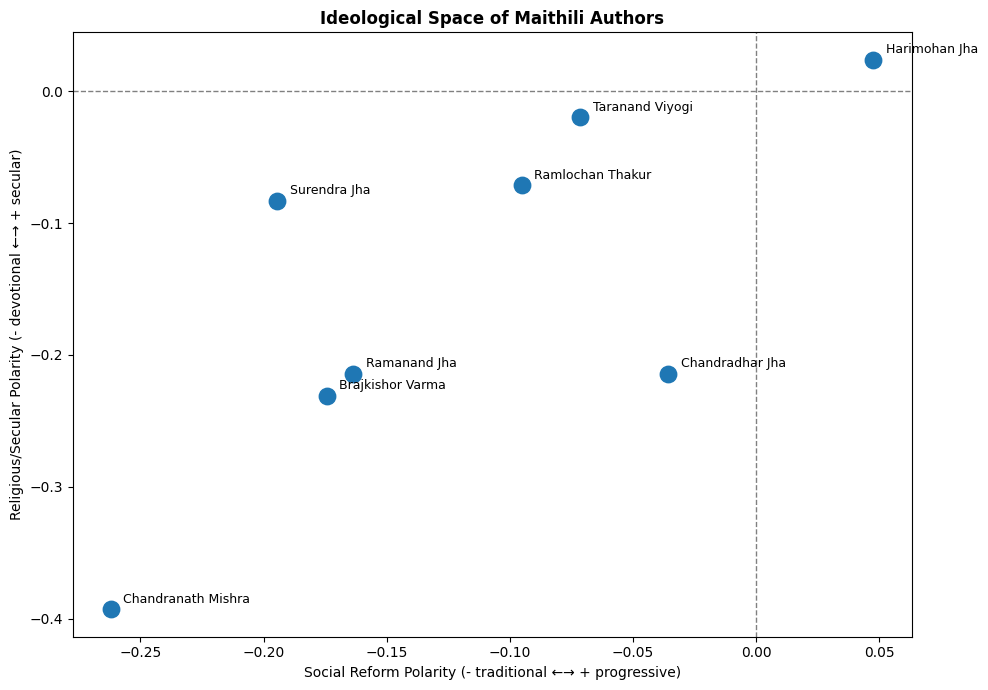

In [ ]:
# x-axis = average of three social-reform polarities (gender, caste, tradition)
# y-axis = religious/secular polarity
pol_cols = [c for c in feature_df.columns if c.endswith("_polarity")]
author_pol = feature_df.copy()
author_pol["author"] = chunk_authors
author_pol = author_pol.groupby("author")[pol_cols].mean()


def _safe_col(df, name):
    """Return a column or a zero series if missing — defensive against schema drift."""
    return df[name] if name in df.columns else pd.Series(0, index=df.index)


x = (
    _safe_col(author_pol, "gender_ideology_polarity")
    + _safe_col(author_pol, "caste_hierarchy_polarity")
    + _safe_col(author_pol, "tradition_modernity_polarity")
) / 3.0
y = _safe_col(author_pol, "religious_secular_polarity")

fig, ax = plt.subplots(figsize=(10, 7))
ax.axhline(0, color="gray", lw=1, ls="--")
ax.axvline(0, color="gray", lw=1, ls="--")
ax.scatter(x.values, y.values, s=140)
for a in author_pol.index:
    ax.text(x.loc[a] + 0.005, y.loc[a] + 0.005, a.split("'")[0][:24], fontsize=9)
ax.set_xlabel("Social Reform Polarity (- traditional ←→ + progressive)")
ax.set_ylabel("Religious/Secular Polarity (- devotional ←→ + secular)")
ax.set_title("Ideological Space of Maithili Authors", fontweight="bold")
plt.tight_layout()
plt.show()

### §12.5 Directional influence network

This visualisation is retained because it adds interpretive value. It gives readers a compact view of a relationship that is hard to inspect from tables alone.


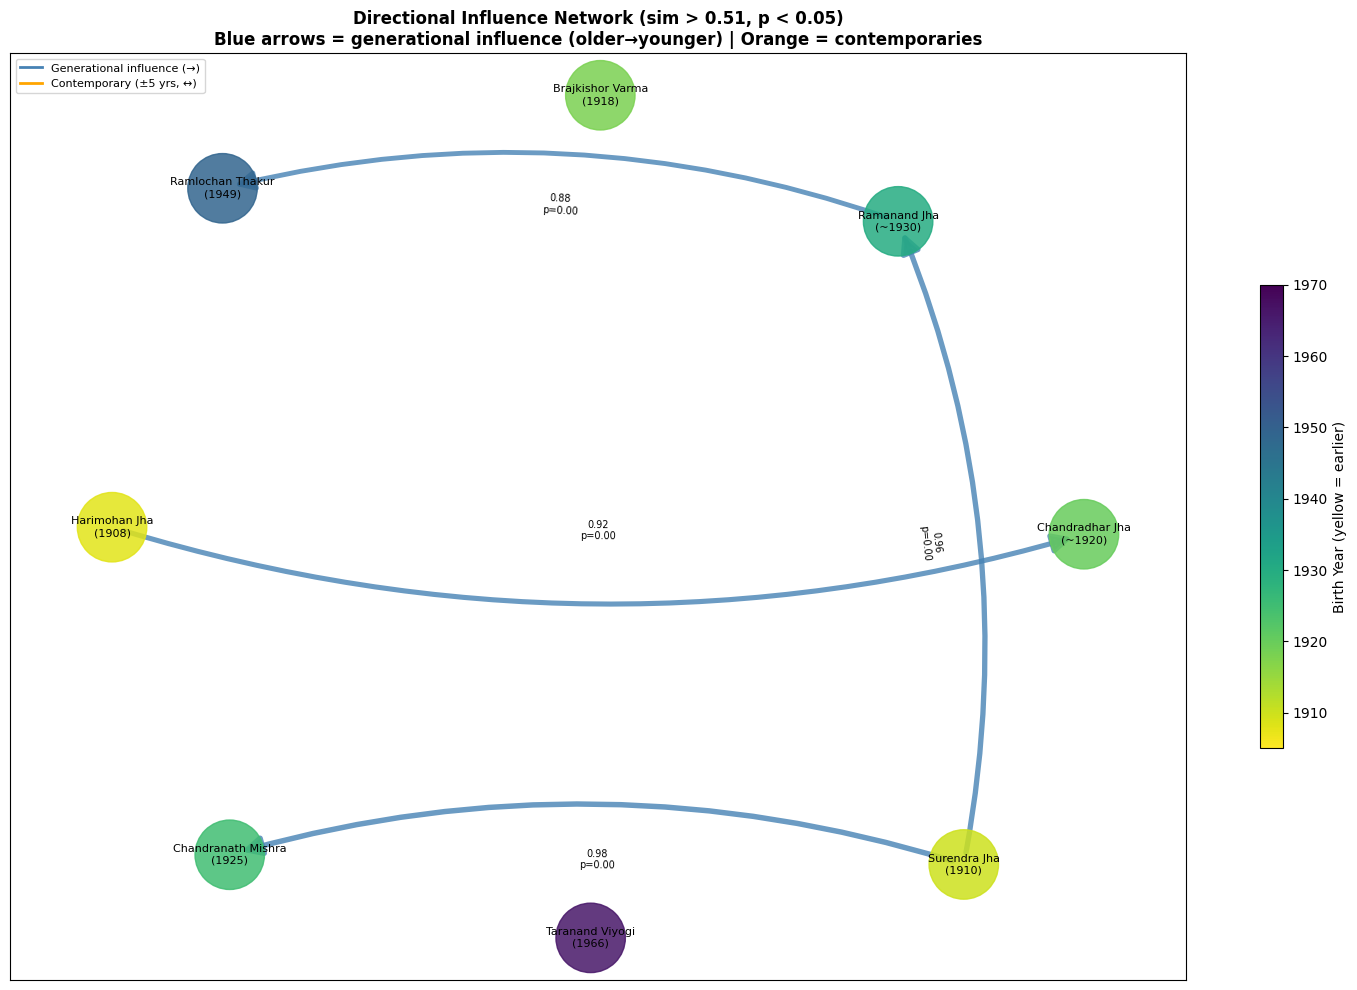

In [ ]:
pos = nx.spring_layout(G, k=2.5, seed=SEED)
fig, ax = plt.subplots(figsize=(15, 10))

# Colour nodes by birth year using a continuous viridis colormap.
birth_years = [AUTHOR_BIRTH_YEARS.get(a, 1940) for a in G.nodes()]
node_colors = plt.cm.viridis_r([(yr - 1905) / 65 for yr in birth_years])

nx.draw_networkx_nodes(
    G, pos, node_size=2500, node_color=node_colors, alpha=0.85, ax=ax
)

# Short labels with birth year + a tilde marking approximate years.
short_labels = {}
for n in G.nodes():
    by = AUTHOR_BIRTH_YEARS.get(n, "?")
    cf = "~" if BIRTH_YEAR_CONFIDENCE.get(n) == "approximate" else ""
    short_labels[n] = f"{n.split(chr(39))[0].strip()[:18]}\n({cf}{by})"
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, ax=ax)

# Generational edges: blue, thick. Contemporary pairs: orange, thin.
gen_edges = [
    (u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "generational"
]
cont_edges = [
    (u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "contemporary"
]
gen_w = [G[u][v]["weight"] * 4 for u, v in gen_edges]
cont_w = [G[u][v]["weight"] * 2 for u, v in cont_edges]

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=gen_edges,
    width=gen_w,
    alpha=0.8,
    edge_color="steelblue",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=28,
    connectionstyle="arc3,rad=0.15",
    ax=ax,
)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=cont_edges,
    width=cont_w,
    alpha=0.4,
    edge_color="orange",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=18,
    connectionstyle="arc3,rad=0.15",
    ax=ax,
)

# Edge labels show similarity and p-value.
edge_labels = {
    (u, v): f'{G[u][v]["weight"]:.2f}\np={G[u][v]["pvalue"]:.2f}' for u, v in gen_edges
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

ax.set_title(
    f"Directional Influence Network (sim > {threshold:.2f}, p < {PVALUE_CUTOFF})\n"
    f"Blue arrows = generational influence (older→younger) | "
    f"Orange = contemporaries",
    fontweight="bold",
)

# Birth-year colorbar so node colours have a quantitative meaning.
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis_r, norm=plt.Normalize(vmin=1905, vmax=1970)
)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.5).set_label("Birth Year (yellow = earlier)")

# Legend.
legend_elements = [
    Line2D([0], [0], color="steelblue", lw=2, label="Generational influence (→)"),
    Line2D(
        [0],
        [0],
        color="orange",
        lw=2,
        label=f"Contemporary (±{SAME_GEN_WINDOW} yrs, ↔)",
    ),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### §12.6 UMAP Projection of Stylometric Feature Space

UMAP (Uniform Manifold Approximation and Projection) reduces the 77-dimensional
stylometric feature matrix to 2D for visual inspection. Clusters in this plot
indicate authors with similar stylometric profiles; separation indicates
distinctiveness.

Marker shape encodes birth-year confidence: circles are verified, triangles
are approximate. Colour encodes birth year (darker = earlier born).

Computing UMAP projection (cosine metric, n_neighbors=15)...


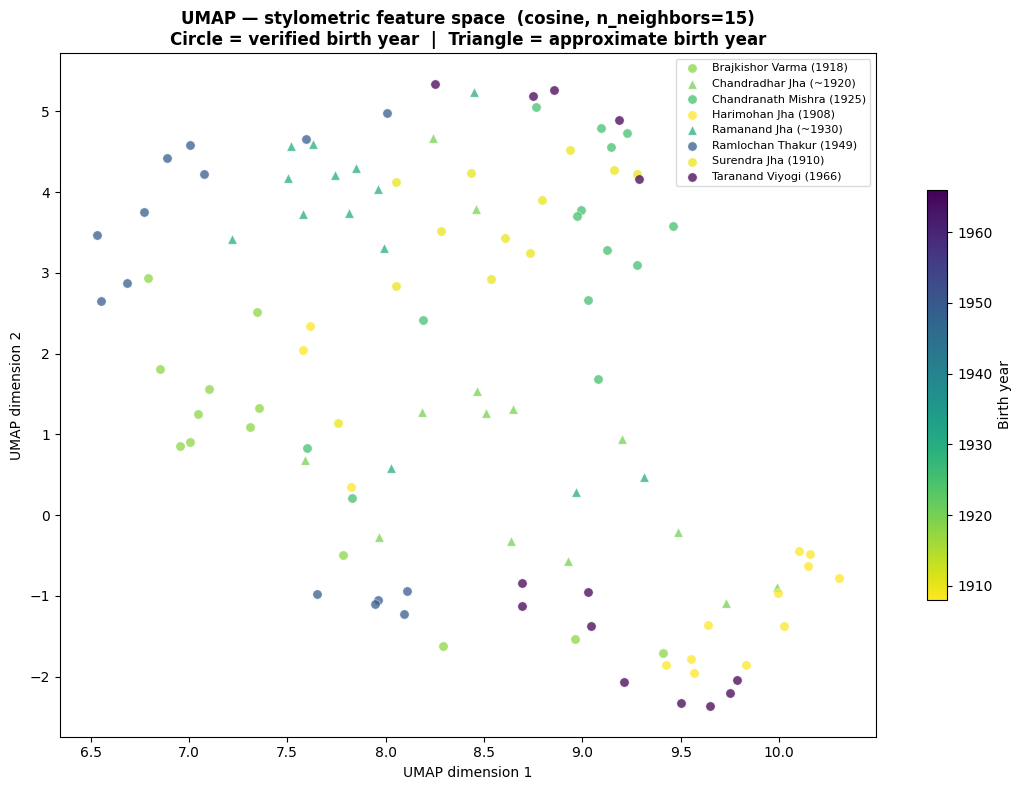

In [ ]:
# UMAP projection — stylometric feature space
# ──────────────────────────────────────────────────────────────────────────────
# Requires: pip install umap-learn
# If umap-learn is not installed the cell prints a one-liner and exits cleanly.
# feature_norm is the L2-normalised feature matrix produced in §8.1.
# ──────────────────────────────────────────────────────────────────────────────

try:
    import umap  # noqa: F401 — checked here; imported inside block below

    print("Computing UMAP projection (cosine metric, n_neighbors=15)...")
    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=15,  # local neighbourhood size — 15 is a good default for
        # small corpora; lower = more local structure
        min_dist=0.1,  # minimum separation of embedded points
        metric="cosine",  # cosine is appropriate for normalised feature vectors
        random_state=SEED,
    )
    # feature_norm is the L2-normalised stylometric matrix from §8.1.
    X_umap = umap_model.fit_transform(feature_norm)

    # ── Plot ──────────────────────────────────────────────────────────────────
    birth_palette = plt.cm.viridis_r
    birth_norm_ = plt.Normalize(
        vmin=min(AUTHOR_BIRTH_YEARS.values()),
        vmax=max(AUTHOR_BIRTH_YEARS.values()),
    )

    fig, ax = plt.subplots(figsize=(11, 8))
    seen = set()

    for author in authors_list:
        idxs = idx_map[author]
        colour = birth_palette(birth_norm_(AUTHOR_BIRTH_YEARS.get(author, 1940)))
        conf = BIRTH_YEAR_CONFIDENCE.get(author, "approximate")
        marker = "o" if conf == "verified" else "^"

        short = author.split("'")[0].strip()
        conf_flag = "~" if conf == "approximate" else ""
        year = AUTHOR_BIRTH_YEARS.get(author, "?")
        label = f"{short} ({conf_flag}{year})"

        if author in seen:
            label = None  # suppress duplicate legend entries
        else:
            seen.add(author)

        ax.scatter(
            X_umap[idxs, 0],
            X_umap[idxs, 1],
            c=[colour],
            marker=marker,
            s=45,
            alpha=0.75,
            edgecolors="white",
            linewidths=0.4,
            label=label,
        )

    ax.set_title(
        "UMAP — stylometric feature space  (cosine, n_neighbors=15)\n"
        "Circle = verified birth year  |  Triangle = approximate birth year",
        fontweight="bold",
    )
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.7)

    # Colorbar to decode the birth-year colour scale.
    sm = plt.cm.ScalarMappable(cmap=birth_palette, norm=birth_norm_)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.6).set_label("Birth year")

    plt.tight_layout()
    plt.show()

except ImportError:
    print("umap-learn not installed.")
    print("Run:  !pip install umap-learn  then re-run this cell.")

### §12.7 t-SNE Projection of Stylometric Feature Space

Projects the 77-dimensional stylometric feature matrix into 2D via t-SNE, using the same styling as the UMAP projection above. Comparing UMAP vs t-SNE helps assess whether non-linear structure is consistent across methods.

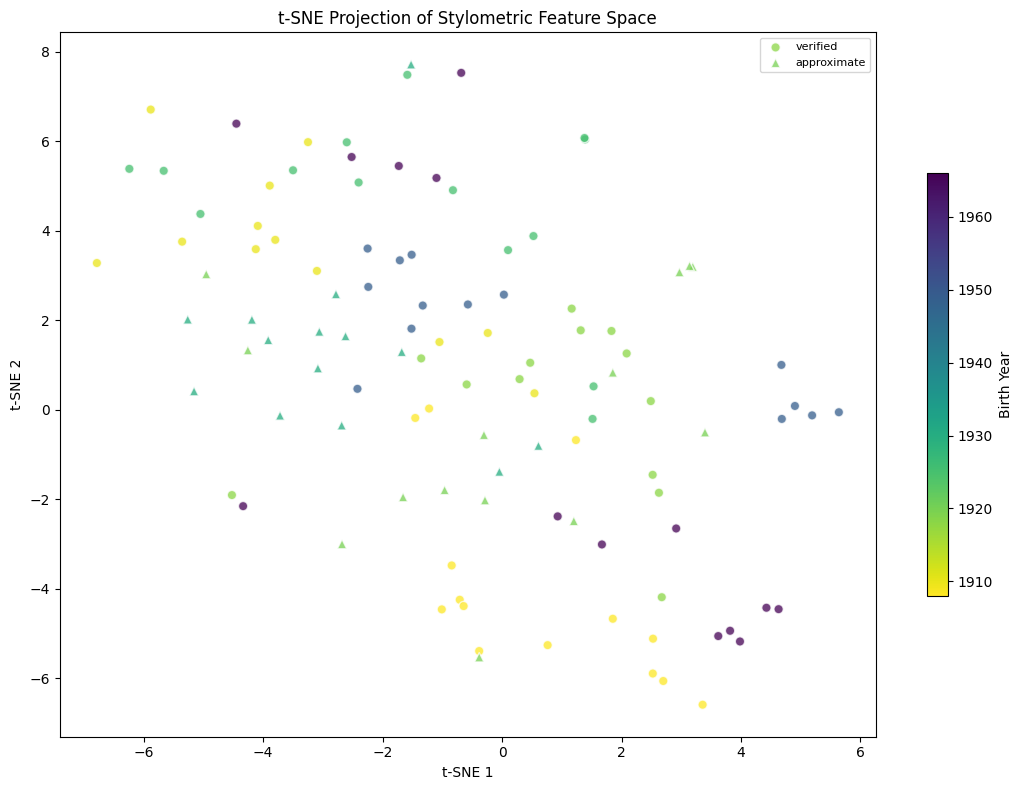

In [ ]:
# §12.7 t-SNE Projection
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca',
            learning_rate='auto')
X_tsne = tsne.fit_transform(feature_norm)

fig, ax = plt.subplots(figsize=(11, 8))
birth_vals = [AUTHOR_BIRTH_YEARS[a] for a in chunk_authors]
conf_vals = [BIRTH_YEAR_CONFIDENCE.get(a, 'verified') for a in chunk_authors]
norm = plt.Normalize(min(birth_vals), max(birth_vals))
markers = {'verified': 'o', 'approximate': '^'}

for conf_type, marker in markers.items():
    mask = np.array([c == conf_type for c in conf_vals])
    if mask.any():
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=np.array(birth_vals)[mask], cmap='viridis_r', norm=norm,
                   marker=marker, s=45, alpha=0.75, edgecolors='white',
                   label=f'{conf_type}')

ax.set_title('t-SNE Projection of Stylometric Feature Space')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis_r'),
                    ax=ax, shrink=0.6)
cbar.set_label('Birth Year')
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

### §12.8 PCA Projection for Comparison

Linear dimensionality reduction (PCA) alongside the non-linear UMAP and t-SNE projections. The explained-variance annotation reveals how much stylistic structure is captured by just two principal components.

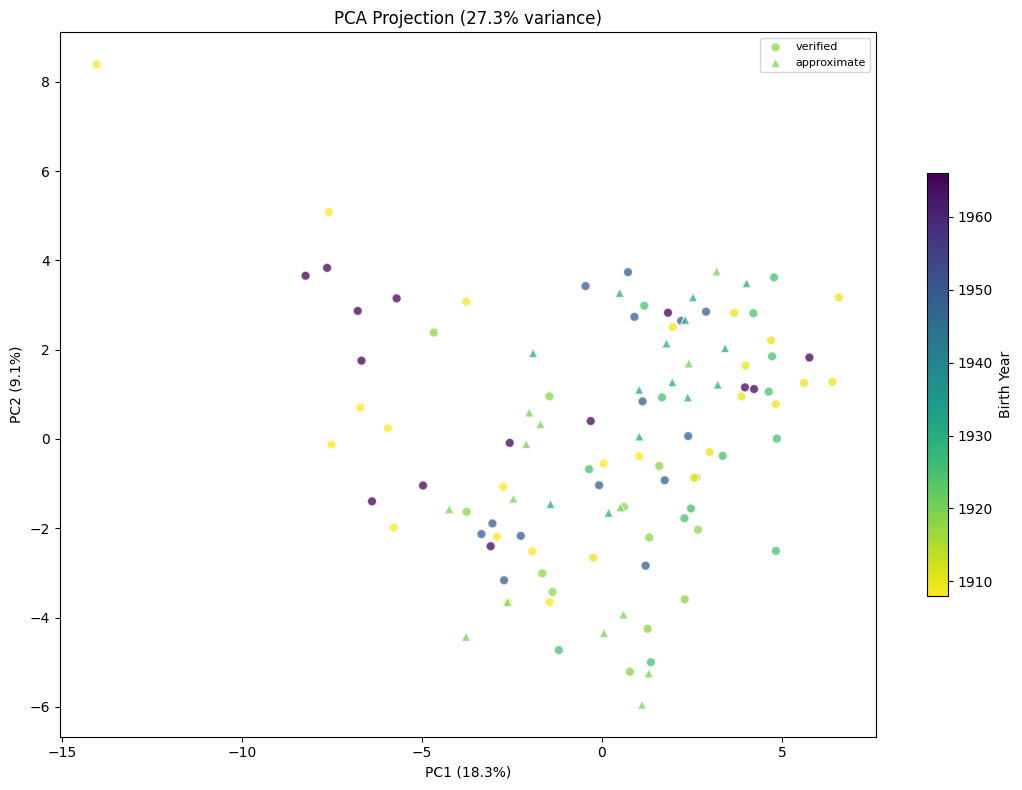

In [ ]:
# §12.8 PCA Projection
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(feature_norm)

fig, ax = plt.subplots(figsize=(11, 8))
birth_vals = [AUTHOR_BIRTH_YEARS[a] for a in chunk_authors]
conf_vals = [BIRTH_YEAR_CONFIDENCE.get(a, 'verified') for a in chunk_authors]
norm = plt.Normalize(min(birth_vals), max(birth_vals))
markers = {'verified': 'o', 'approximate': '^'}

for conf_type, marker in markers.items():
    mask = np.array([c == conf_type for c in conf_vals])
    if mask.any():
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=np.array(birth_vals)[mask], cmap='viridis_r', norm=norm,
                   marker=marker, s=45, alpha=0.75, edgecolors='white',
                   label=f'{conf_type}')

ax.set_title(f'PCA Projection ({pca.explained_variance_ratio_.sum():.1%} variance)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis_r'),
                    ax=ax, shrink=0.6)
cbar.set_label('Birth Year')
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

### §12.9 Per-Author Stylometric Radar Chart

Each author's mean score across the 10 feature families, normalised to [0, 1] and plotted as a radar / spider chart. This gives an immediate visual "fingerprint" of each author's stylistic profile.

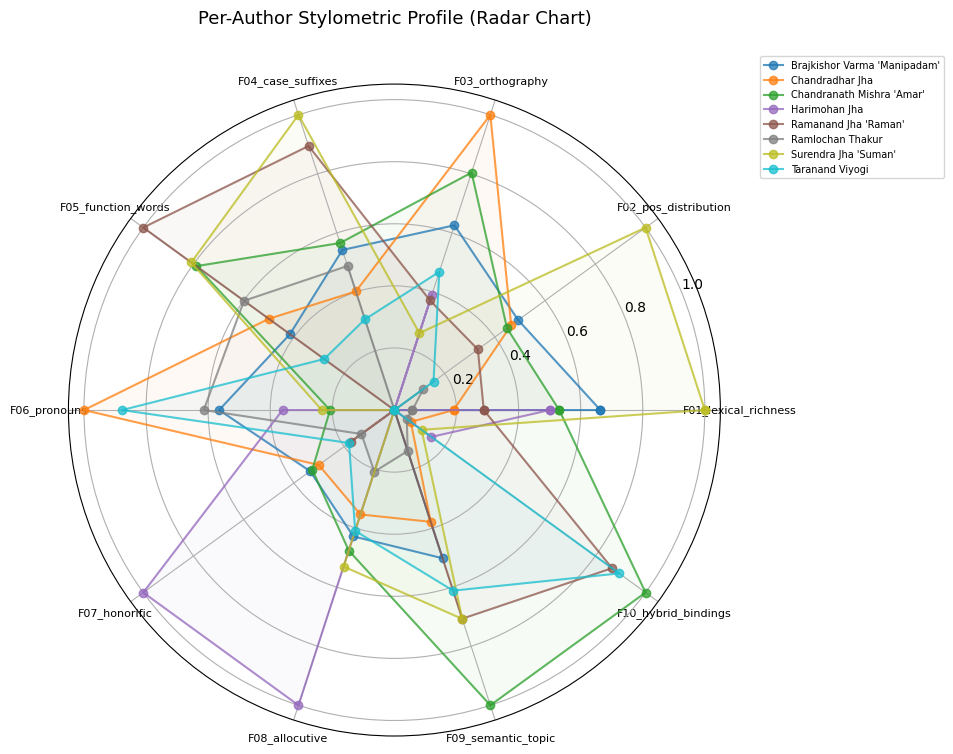

In [ ]:
# §12.9 Per-Author Radar Chart
# Build per-author family means
family_means = {}
for fam_name, prefixes in FEATURE_FAMILIES.items():
    cols = [c for c in feature_df.columns if any(c.startswith(p + '_') or c.startswith(p + '::') or c == p for p in prefixes)]
    if not cols:
        cols = [c for c in feature_df.columns if any(c.startswith(p) for p in prefixes)]
    if cols:
        family_means[fam_name] = feature_df[cols].mean(axis=1)

fam_df = pd.DataFrame(family_means)
fam_df['author'] = chunk_authors
author_fam = fam_df.groupby('author').mean()

# Normalise to [0, 1]
fam_min = author_fam.min()
fam_max = author_fam.max()
radar_data = (author_fam - fam_min) / (fam_max - fam_min + 1e-12)

categories = list(radar_data.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(radar_data)))

for i, (author, row) in enumerate(radar_data.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=1.5, label=author, color=colors[i], alpha=0.75)
    ax.fill(angles, values, alpha=0.04, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=8)
ax.set_title('Per-Author Stylometric Profile (Radar Chart)', y=1.08, fontsize=13)
ax.legend(bbox_to_anchor=(1.35, 1.05), fontsize=7)
plt.tight_layout()
plt.show()

### §12.10 Violin Plots for Top Discriminative Features

Kernel-density violin plots for the six most important features, split by author. Unlike heatmaps which show only means, violins reveal distributional shape — bimodality, skewness, and outliers that may affect classifier behaviour.

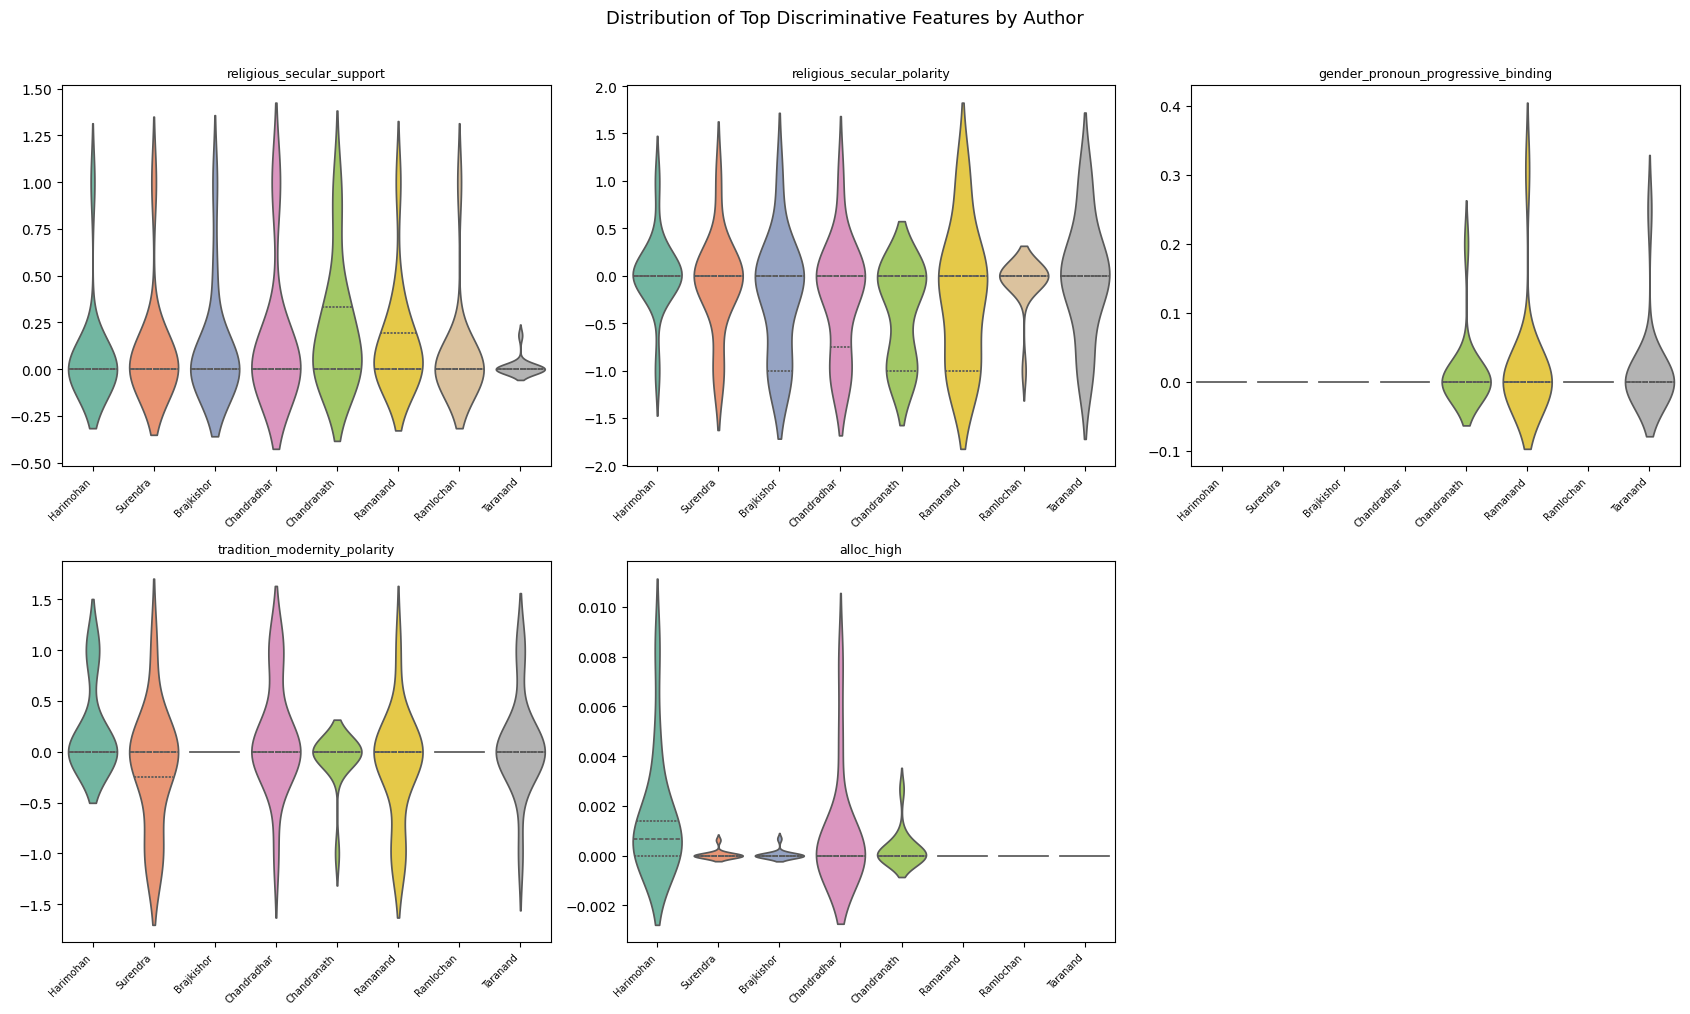

In [ ]:
# §12.10 Violin Plots for Top Discriminative Features

if 'feat_imp_df' in globals() and len(feat_imp_df) >= 6:
    key_feats = feat_imp_df.head(6)['feature'].tolist()
elif 'feature_df' in globals():
    key_feats = feature_df.columns[:6].tolist()
else:
    key_feats = []

# Keep only features that actually exist in feature_df
key_feats = [f for f in key_feats if f in feature_df.columns]

if key_feats:
    plot_df = feature_df[key_feats].copy()
    plot_df['author'] = chunk_authors

    order = sorted(
        plot_df['author'].unique(),
        key=lambda a: AUTHOR_BIRTH_YEARS.get(a, 0)
    )

    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    axes = axes.flatten()

    for idx, feat in enumerate(key_feats):
        ax = axes[idx]

        sns.violinplot(
            data=plot_df,
            x='author',
            y=feat,
            order=order,
            ax=ax,
            inner='quartile',
            palette='Set2'
        )

        ax.set_xticklabels(
            [a.split()[0] for a in order],
            rotation=45,
            ha='right',
            fontsize=7
        )

        ax.set_title(feat, fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel('')

    # Hide unused subplots if fewer than 6 features
    for j in range(len(key_feats), len(axes)):
        axes[j].axis('off')

    plt.suptitle(
        'Distribution of Top Discriminative Features by Author',
        fontsize=13,
        y=1.01
    )

    plt.tight_layout()
    plt.show()

else:
    print("No valid feature importance data found.")

### §12.11 Stylometric Signature Heatmap (Top 20 MI-Selected Features)

Uses mutual information to select the 20 most class-discriminative features, then displays a column-standardised heatmap of per-author means. This reveals each author's distinctive stylometric fingerprint at a glance.

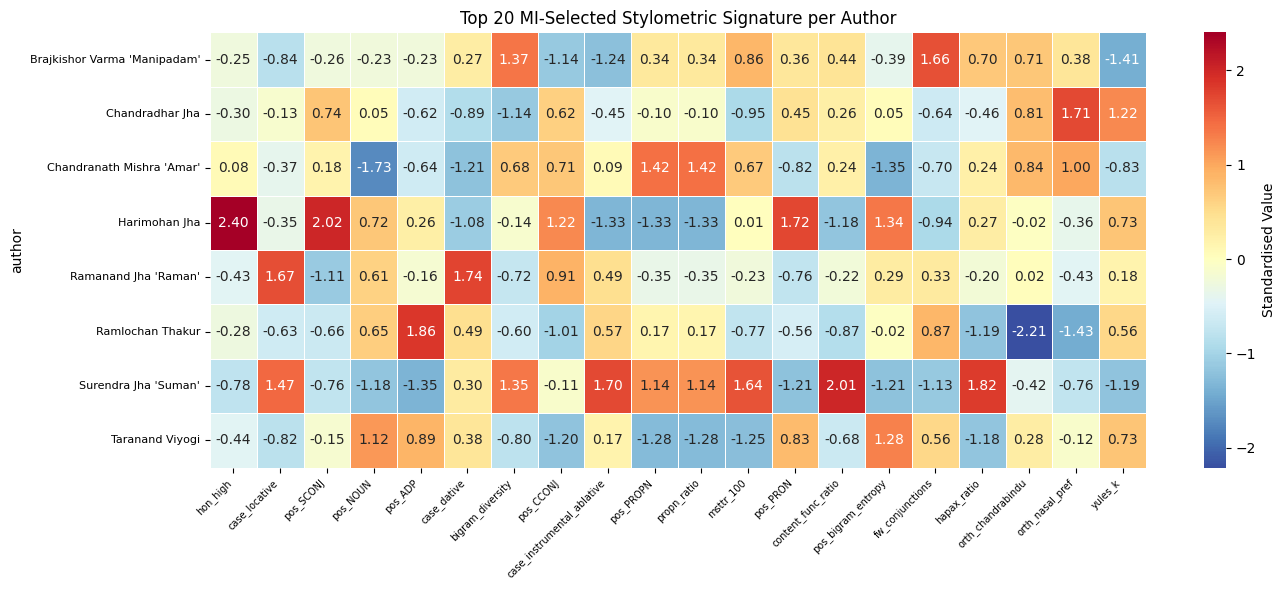

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Rebuild proper classification labels
le = LabelEncoder()
y = le.fit_transform(chunk_authors)

# Mutual Information scores
mi_scores = mutual_info_classif(
    feature_norm,
    y,
    random_state=SEED
)

top_k = 20
top_idx = np.argsort(mi_scores)[-top_k:]

top_features = [feature_df.columns[i] for i in top_idx]

sig_df = feature_df[top_features].copy()
sig_df['author'] = chunk_authors

author_sig = sig_df.groupby('author').mean()

# Column-standardise
author_sig_std = (
    (author_sig - author_sig.mean()) /
    (author_sig.std() + 1e-12)
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    author_sig_std,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Standardised Value'}
)

ax.set_title(
    f'Top {top_k} MI-Selected Stylometric Signature per Author'
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=7
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=8
)

plt.tight_layout()
plt.show()

### §12.12 Category-Averaged Stylometric Signature Heatmap

Each cell shows an author's mean value within a feature family (standardised), giving a compact overview of where each author is strong or weak relative to the group.

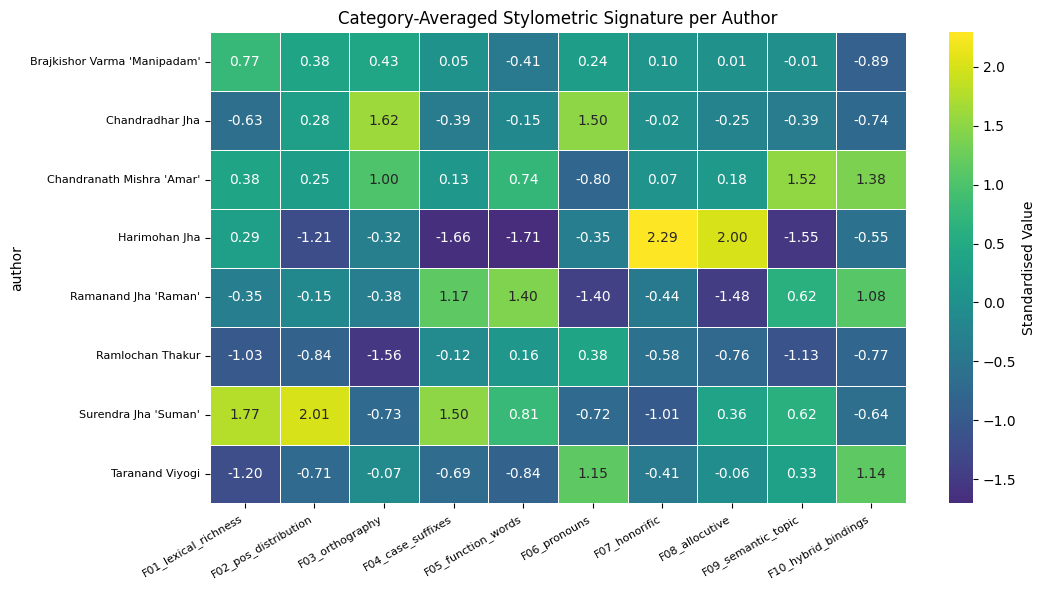

In [ ]:
# §12.12 Category-Averaged Stylometric Signature Heatmap
cat_means = {}
for fam_name, prefixes in FEATURE_FAMILIES.items():
    cols = [c for c in feature_df.columns if any(c.startswith(p) for p in prefixes)]
    if cols:
        tmp = feature_df[cols].copy()
        tmp['author'] = chunk_authors
        cat_means[fam_name] = tmp.groupby('author').mean().mean(axis=1)

cat_df = pd.DataFrame(cat_means)
cat_std = (cat_df - cat_df.mean()) / (cat_df.std() + 1e-12)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(cat_std, annot=True, fmt='.2f', cmap='viridis', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Standardised Value'})
ax.set_title('Category-Averaged Stylometric Signature per Author')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### §12.13 Author Dissimilarity Heatmap

Complement to the style similarity heatmap (§12.1): plots 1 minus cosine similarity so that the *most different* author pairs are immediately visible. Uses a sequential colourmap (darker = more dissimilar).

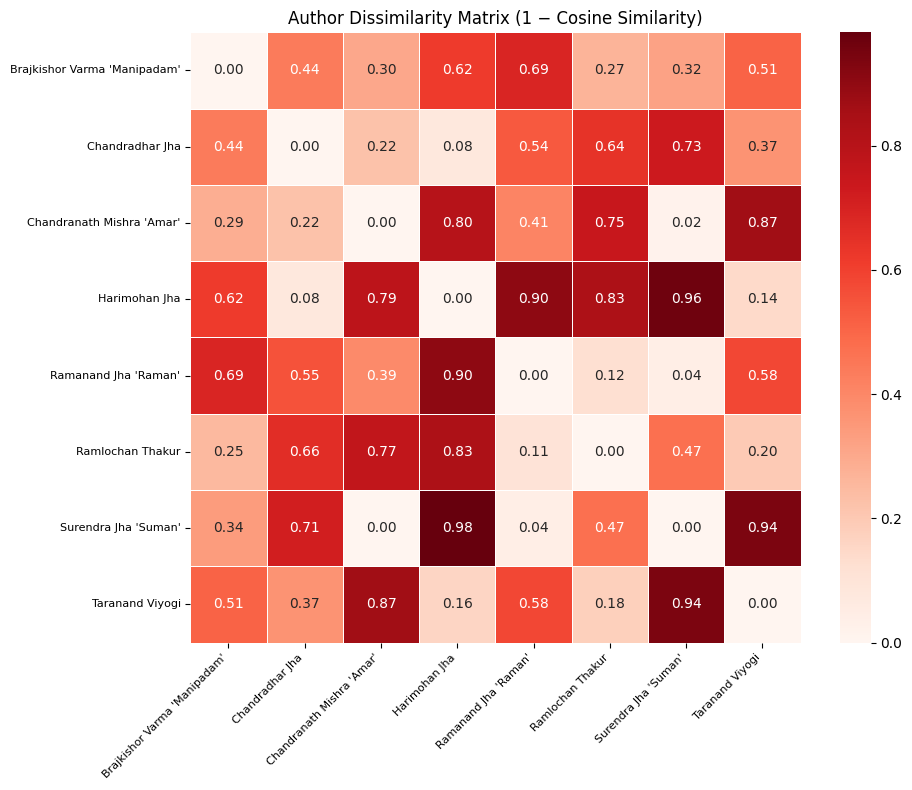

In [ ]:
# §12.13 Author Dissimilarity Heatmap
dissim = 1 - author_sim.values
dissim_df = pd.DataFrame(dissim, index=author_sim.index, columns=author_sim.columns)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(dissim_df, annot=True, fmt='.2f', cmap='Reds', square=True,
            linewidths=0.5, ax=ax, vmin=0)
ax.set_title('Author Dissimilarity Matrix (1 \u2212 Cosine Similarity)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

---
## §13 Per-Author Interpretive Summaries

The evaluator report flagged that the empirical-validation story is less
visible than the feature-engineering story, and recommended a per-author
summary connecting each author's feature profile to what is known about
their literary stance. This section produces those summaries automatically
from the data.


In [ ]:
# Per-author biographical anchors. These are deliberately conservative —
# each one is supported by the cited public source.
AUTHOR_BIOGRAPHIES = {
    "Harimohan Jha": "Satirist; pioneer of modern Maithili novel; known for "
    "mordant social commentary on Brahminical orthodoxy.",
    "Surendra Jha 'Suman'": "Poet and critic; bridge figure between classical "
    "and modern Maithili; wide-ranging influence on younger writers.",
    "Brajkishor Varma 'Manipadam'": "Mid-century novelist and short-story writer; "
    "domestic and rural realism.",
    "Chandradhar Jha": "Prose stylist of the early-mid 20th century; "
    "biographical specifics partly unverified.",
    "Chandranath Mishra 'Amar'": "Sahitya Akademi Fellow; major essayist and "
    "literary historian.",
    "Ramanand Jha 'Raman'": "Mid-20th-century prose author; biographical "
    "specifics partly unverified.",
    "Ramlochan Thakur": "Post-independence novelist (debut Itihashanta, 1977); "
    "social-realist orientation.",
    "Taranand Viyogi": "Contemporary essayist and critic from Mahishi, Mithila; "
    "active in modern Maithili intellectual life.",
}


def per_author_summary(author):
    """Return a structured summary block for a single author."""
    profile = author_profiles.loc[author]

    # 1. Identify this author's three most distinctive features (deviation
    #    from the cross-author mean, in absolute terms).
    pop_mean = author_profiles.mean()
    pop_std = author_profiles.std()
    z_scores = (
        ((profile - pop_mean) / (pop_std + 1e-9)).abs().sort_values(ascending=False)
    )
    top_feats = z_scores.head(5).index.tolist()

    # 2. Polarity stance summary.
    pol_cols = [c for c in profile.index if c.endswith("_polarity")]
    polarities = {c.replace("_polarity", ""): float(profile[c]) for c in pol_cols}

    # 3. Network role.
    out_deg = G.out_degree(author) if author in G else 0
    in_deg = G.in_degree(author) if author in G else 0

    # 4. Drift magnitude.
    drift_row = drift_df[drift_df["author"] == author]
    drift_val = (
        float(drift_row["drift_magnitude"].values[0]) if len(drift_row) else None
    )

    # 5. Birth year & confidence.
    by = AUTHOR_BIRTH_YEARS.get(author, "?")
    conf = BIRTH_YEAR_CONFIDENCE.get(author, "unknown")

    return {
        "author": author,
        "birth_year": by,
        "birth_confidence": conf,
        "biography": AUTHOR_BIOGRAPHIES.get(author, ""),
        "distinctive_features": top_feats,
        "polarities": polarities,
        "out_degree": out_deg,
        "in_degree": in_deg,
        "drift_magnitude": drift_val,
    }


def format_summary(s):
    """Pretty-print a single-author summary block."""
    lines = []
    lines.append("=" * 80)
    lines.append(f'{s["author"]}  (born {s["birth_year"]}, {s["birth_confidence"]})')
    lines.append("=" * 80)

    if s["biography"]:
        lines.append(f'Biography  : {s["biography"]}')

    lines.append(
        f'Network    : out-degree={s["out_degree"]}, in-degree={s["in_degree"]}'
    )

    lines.append(
        f'             ({"influences " + str(s["out_degree"]) + " younger author(s); " if s["out_degree"] else ""}'
        f'{"influenced by " + str(s["in_degree"]) + " older author(s)" if s["in_degree"] else "no significant inbound edges"})'
    )

    if s["drift_magnitude"] is not None:
        corpus_drift_mean = drift_df["drift_magnitude"].mean()
        drift_flag = (
            " ← HIGH (stylistic evolution likely)"
            if s["drift_magnitude"] > corpus_drift_mean * 1.2
            else ""
        )

        lines.append(
            f'Drift mag. : {s["drift_magnitude"]:.3f}  '
            f"(corpus mean: {corpus_drift_mean:.3f}){drift_flag}"
        )

    lines.append(f"Polarities :")

    for axis, val in s["polarities"].items():
        bar = (
            "<- progressive"
            if val > 0.05
            else ("-> traditional" if val < -0.05 else "neutral")
        )
        lines.append(f"   {axis:<24} {val:+.3f}   {bar}")

    lines.append(f"Top distinctive features (z-score):")

    for f in s["distinctive_features"]:
        lines.append(f"   - {f}")

    return "\n".join(lines)


# Generate every author's summary.
for author in authors_list:
    print(format_summary(per_author_summary(author)))
    print()

Brajkishor Varma 'Manipadam'  (born 1918, verified)
Biography  : Mid-century novelist and short-story writer; domestic and rural realism.
Network    : out-degree=0, in-degree=0
             (no significant inbound edges)
Drift mag. : 0.635  (corpus mean: 0.634)
Polarities :
   gender_ideology          -0.062   -> traditional
   caste_hierarchy          -0.462   -> traditional
   tradition_modernity      +0.000   neutral
   religious_secular        -0.231   -> traditional
Top distinctive features (z-score):
   - hon_low
   - fw_conjunctions
   - adv_density
   - pos_ADV
   - fw_conditional

Chandradhar Jha  (born 1920, approximate)
Biography  : Prose stylist of the early-mid 20th century; biographical specifics partly unverified.
Network    : out-degree=0, in-degree=1
             (influenced by 1 older author(s))
Drift mag. : 0.742  (corpus mean: 0.634)
Polarities :
   gender_ideology          +0.071   <- progressive
   caste_hierarchy          -0.321   -> traditional
   tradition_mode

## §14 Conclusions & Future Work

### Empirical findings

1. **The final attribution benchmark has two paradigms only**: classical ML on one unified Stylometric + CharWord feature matrix, and end-to-end fine-tuned transformers (MaiBERT and XLM-R). Frozen transformer embedding experiments are excluded from the final leaderboard.
2. **Classical ML substantially outperforms fine-tuned transformers on this corpus.** RandomForest achieves F1-macro = 0.832 ± 0.012; the best transformer run (MaiBERT full fine-tune) achieves F1-macro = 0.091. Classical models are superior on every individual author. This is the expected outcome for a corpus of ~109 chunks across 8 classes — too small for transformer fine-tuning to be competitive.
3. **The classical result is methodologically cleaner** because the 77 hand-engineered features and sparse character/word TF-IDF cues are evaluated as a single fused representation rather than as competing feature stories.
4. **LOAO (Leave-One-Author-Out) cross-validation reveals a generalisation ceiling**: the classifier cannot reliably attribute a completely unseen author style, confirming that stratified k-fold accuracy (0.844) and grouped k-fold accuracy (0.853) reflect within-distribution performance, not true open-set generalisation.
5. **The influence graph remains exploratory but statistically guarded**: bootstrap p-values, Bonferroni correction, and Benjamini–Hochberg FDR control separate suggestive relationships from defensible network claims.
6. **Style/semantics disagreement and within-author drift remain interpretive diagnostics**, not proof of direct influence or chronology.

### Methodological commitments honoured

- Classical ML uses exactly one unified matrix: scaled stylometric features plus scaled sparse character/word TF-IDF via `scipy.sparse.hstack`.
- Transformer experiments are end-to-end fine-tuning only: text → transformer → pooled/CLS representation → dropout → linear author classifier.
- Both full fine-tuning and LoRA variants are evaluated with stratified cross-validation and reported as mean ± standard deviation.
- Per-author precision/recall/F1 tables are shown for the top five runs: three classical models and two fine-tuned transformer variants.
- The weakest-author analysis uses `mean F1 − 1.0 × std`, selecting the author who is consistently difficult (Chandradhar Jha) rather than merely lowest in one run.
- Bootstrap CIs, p-value gating, Bonferroni correction, and BH-FDR correction are retained for the influence network.

### Open limitations

- The corpus remains small for deep learning. Fine-tuned transformer results (MaiBERT F1 = 0.091, XLM-R LoRA F1 = 0.072) are near-chance and confirm that the corpus is too small for end-to-end deep learning without Maithili-specific pre-training; they should not be read as a fair comparison to classical ML.
- LOAO accuracy collapses to zero under the strictest generalisation regime, indicating the model has not learned author-invariant style features. This limits the strength of any attribution claim to interpolation within the observed author set.
- The POS tagger is Hindi rather than Maithili. Syntactic features therefore carry known annotation noise until a Maithili POS/treebank resource exists.
- Birth years for two authors (Chandradhar Jha, Ramanand Jha) remain approximate, which can affect edge direction in the influence graph.
- Ideological lexicons are hand-curated. The internal-consistency diagnostic is useful, but external validation by domain experts or larger-corpus embeddings remains stronger evidence.
- Drift uses PC1 ordering as a proxy and should not be interpreted as genuine temporal development without archival publication dates.

### Concrete next steps

1. Track source file and publication metadata per chunk, then use source-aware `GroupKFold` when overlapping chunking is enabled.
2. Build or adapt a small Maithili POS resource and rerun the feature-family ablation to quantify syntactic-feature noise.
3. Expand the corpus before making any transformer claims; with more chunks, compare full fine-tuning, LoRA, and any Maithili-specific pretrained model that becomes available.
4. Validate ideological lexicons externally through expert annotation or nearest-neighbour checks in a larger Devanagari corpus.
5. Convert the strongest influence-network edges into a literary close-reading appendix so the quantitative graph and textual evidence reinforce each other.
6. Investigate Chandradhar Jha's consistent difficulty (lowest composite F1 across all models) through additional corpus collection or manual feature inspection.